# README

**BATCH INFORMATION**

- 3B --> Door task 3 choices (box1). All delays  ------------------------------------> PHARMA SYST (16/10/20-03/08/21)
- 3B --> Corridor task 5 choices (box2). Temporal delays. DS, DL  ------------------------------> PHARMA SYST (16/10/20-03/08/21)
- 4B --> Corridor task 3 choices. Position delays. DS, DL (6B code) ---------------------> PHARMA LOCAL TESTS mPFC (12/11/21-15/01/22)
- 5B --> Corridor task 3 choices. Position delays. DS, DL   -----------------------------> EPHYS  BDX  (10/03/21-23/06/21)
- 6B --> Corridor task 3 choices. Position delays. DS, DM, DL, SIL ----------------------> PHARMA LOCAL (22/11/2021-05/04/2022) pretraining in R10 To include
- 7B --> Corridor task 3 choices. Position delays. DS, DM, DL, SIL.Stim dur cnt ---------> ECOHAB (04/10/2022-18/05/2023)
- 8B --> Corridor task 3 choices. Position delays. DS, DM-DL, SIL -----------------------> OPTO DUB ()
- 9B --> Corridor task 3 choices. Position delays. DS, DM-DL, SIL. ----------------------> GRIN1KO + ECOHAB (21/08/2023-Now) <br>
Stimdur cnt (V1); varible (V2) only stage3; Choice prob (V3) <br>
- 10B--> Corridor task 3 choices. Position delays. DS, DM-DL, SIL. Stim dur cnt ---------> OPTO NEUROLUX (21/08/2023-Now)


**COLUMNS INFORMATION**

- Subject name
- Date of the behavioral session
- Batch: experimental group
- Maze version: Behavioral box shape: door or corridor to impose the delay
- Task: Behavioral task name
- Session number
- Trial number
- Total trials: number total of tirals per session
- Subject_weight: mouse weight in the behavioral session
- Relative_weights: mouse relative weight (%) to the non water resticted weight
<br>
- x: Stimulus position x axis (0-403mm from left to right response)
- y: Stimulus position x axis (0-?mm from top to bottom response)
- response_x_first:Mouse first response x axis (0-403mm from left to right response)
- response_x_last: Mouse last response x axis (0-403mm from left to right response)
- response_y_first:Mouse first response y axis (0-?mm from top to bottom response)
- response_y_last: Mouse last response y axis (0-?mm  from top to bottom response)
- mask: number of holes in the mask
<br>
- Trial type: Raw name of the trial type
- ttype_n: Homogenized trial type ordered by number (VG:0; DS:1; DM:2, DL:3)
- ttype_c: Homogenized trial type categorical values (VG, DS, DM, DL)
- stimd_n: Homogenized stimulus duration ordered by number (VG:4; DS:3; DM:2, DL:1; DSc1:2; DSc2:1; DMc1:1)
- stimd_c: Homogenized stimulus categorical values (VG:4; SL:3; SM:2, SS:1)
- delay_abs: Delay from stimulus offset until animal response/tup response window
- delay_rw: Delay from stimulus offset until response window onset
- stim_dur_ds: stimulus extra elongation from DS
- stim_dur_dm: stimulus extra elongation from DM
- stim_dur_dl: stimulus extra elongation from DL
<br>
- Trial result: Outcome of the animal response (Correct_first; Correct_other; Punish; Incorrect; Miss)
- Response_time_first: Bpod time of the first response (empty in misses)
- Response_time_last: Bpod time of the last response (empty in misses)
- Response_window_end: Bpod time of the end of resp window (corrected and homogenized for multiple resp wins)
- Reward_time: Bpod time of reward collection (PH1 creossing in non-rewarded trials)
- Resp_latency: Time from resp win onset until mouse response/tup
- Lick_latency: Time from response/miss until reward collection (PH1 creossing in non-rewarded trials)
- Trial_length: Trime from trial onset until ends            
<br>
- Different states BPOD times ('STATE_Start_task_START', 'STATE_Fixation1_START', 'STATE_Fixation2_START', 'STATE_Fixation3_START', 'STATE_Response_window_START' ,'STATE_Response_window_END', 'STATE_Exit_START')
<br>
- Injection: type of pharma drug injected (Varies across sessions)
- Virus: type of virus injected in the surgery (Varies across animals)
- Genotype: mouse genotype
- 4OHT_label: For 8B, tamoxi injection during choice training or homecage
- Opto_on: Session with opto trials 
- Frequency: opto frequency of stimulation
- Opto_bool: Trial with light (1) trial without light (0)
- Opto_delay: Delay from signal onset until stimulation (not taken in account neurolux devices latencies) 
- Max_dur_light: Opto stimulation time
- Bias prob: if changes of probabilies occured, which was the probability of appear
- Bias side: which side was teh most favored (0: L, 1:C, 2: R)
<br>
- BPODCRASH: errors in BPOD
- correction_bias:  variable present in intial states (after incorrect repetition of the same stim position until correct)
<br>
- Performance: bool column to indicate correct hits
- Accuracy: bool column to indicate correct hits (misses are nans)
- Misses: bool column to indicate misses
- Silent: bool column to indicate if there was absence of stimulus
- Valids:  bool column to indicate non missed trials & trials without errors
- x_n: Stimulus numerical category (Left:-1; Centre:0, Right: 1)
- r_n: Response numerical category (Left:-1; Centre:0, Right: 1) (empty in misses)
- x_c: Stimulus category (L, C, R)
- r_c: Response category (L, C, R) (empty in misses)
- Chance: 1/number of choices (prob correct when random guessing)

# IMPORTS

In [23]:
import os
import numpy as np
import pandas as pd
from datetime import timedelta, datetime

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns

import scipy
from scipy import stats
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf
# from bioinfokit.analys import stat
# import pingouin as pg
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings('ignore')
import utils

# READ DATA

In [24]:
data_folder= './datasets/'
filename ='df_filtered2.csv'

df = pd.read_csv(str(data_folder) + str(filename), sep=';')
data_folder= '/home/balma/DATA/overall_plots/All/'


# PLOT PARAMETERS

In [25]:
sns.set()
sns.set_style('white')
sns.set_style('ticks')
sns.set_context("poster", font_scale=1)


lines_c = 'silver'
chance=1/3


# BATCHES LISTS
batch_c =  sns.set_palette("Set2", df.batch.nunique())

# TRIAL TYPE LIST
ttypes_o = [0, 1,2,3,4]
ttypes_f=['Visual','Short', 'Med', 'Long', 'NO']
ttypes_c = [
    '#230027',  # Darkest Purple
    '#5E2A7E',  # Dark Purple
    '#9C69A3',  # Medium Purple
    '#C698CB',  # Light Purple
    '#EFD9F5'   # Lightest Purple
]

# OUTCOME LIST
tresult_o=['correct_first', 'punish']
tresult_f=['Correct', 'Incorrect']
tresult_c=['green', 'firebrick'] 
# tresult_c=['yellowgreen', 'indianred'] 


# TAMOXI LIST
tamoxi_o = ['Central_ch', 'Homecage']
tamoxi_f = ['C choice', 'Homecage']
tamoxi_c= ['mediumorchid', 'yellowgreen']

# OPTO LIST
opto_o = [0, 1]
opto_f = ['OFF', 'ON']
opto_c = ['gray', 'cornflowerblue']

# STIMULUS POSITION
stim_o = [-1, 0, 1]
stim_f=['Left', 'Centre', 'Right']
stim_c=[(0.8816172286897883, 0.4314264196004728, 0.4648957165548593), 
             (0.5573241061130334, 0.8164244521337947, 0.546958861976163),
            (0.4500284515703821, 0.6166767969381974, 0.7400141466793091)]

# STIMULUS DURATION
# stimd_c= ['yellowgreen', 'limegreen', 'green'] #greens
# stimd_c= ['#91B4D6', '#3579A3', '#004080']  #blues
stimd_c = ["#FFB74D", "#FB8C00", "#EF6C00"] #oranges
stimd_f = ['Short', 'Med', 'Long']
stimd_o = [1, 2, 3]


# MUSCI INJECTIONS LIST
drug_o = ['Saline', 'M:B']
drug_c = ['gray', 'teal']

# FUNCTIONS

In [37]:
# repeating bias caluclation
def rep_bias_calc(df, columns):
    RBl=(df.loc[((df.r_n ==-1) & (df.prev_r_n ==-1))].groupby(columns)['valids'].sum()/df.loc[(df.r_n ==-1)].groupby(columns)['valids'].sum()).reset_index()
    RBc=(df.loc[((df.r_n == 0) & (df.prev_r_n == 0))].groupby(columns)['valids'].sum()/df.loc[(df.r_n == 0)].groupby(columns)['valids'].sum()).reset_index()
    RBr=(df.loc[((df.r_n == 1) & (df.prev_r_n == 1))].groupby(columns)['valids'].sum()/df.loc[(df.r_n == 1)].groupby(columns)['valids'].sum()).reset_index()

    RBl.rename(columns = {'valids':'RBl'}, inplace=True)
    RBc.rename(columns = {'valids':'RBc'}, inplace=True)
    RBr.rename(columns = {'valids':'RBr'}, inplace=True)

    df=pd.concat([RBl, RBc, RBr], axis=1)
    df = df.loc[:,~df.columns.duplicated()]
    df['RB']=(df['RBl']+df['RBc']+df['RBr'])/3
    return df


def rep_bias_5C_calc(df, columns):
    RBll=(df.loc[((df.r_c==-2) & (df.prev_r_n ==-2))].groupby(columns)['valids'].sum()/df.loc[(df.r_n ==-2)].groupby(columns)['valids'].sum()).reset_index()
    RBl=(df.loc[((df.r_c ==-1) & (df.prev_r_n ==-1))].groupby(columns)['valids'].sum()/df.loc[(df.r_n ==-1)].groupby(columns)['valids'].sum()).reset_index()
    RBc=(df.loc[((df.r_c == 0) & (df.prev_r_n == 0))].groupby(columns)['valids'].sum()/df.loc[(df.r_n == 0)].groupby(columns)['valids'].sum()).reset_index()
    RBr=(df.loc[((df.r_c == 1) & (df.prev_r_n == 1))].groupby(columns)['valids'].sum()/df.loc[(df.r_n == 1)].groupby(columns)['valids'].sum()).reset_index()
    RBrr=(df.loc[((df.r_c ==2) & (df.prev_r_n == 2))].groupby(columns)['valids'].sum()/df.loc[(df.r_n == 2)].groupby(columns)['valids'].sum()).reset_index()

    RBll.rename(columns= {'valids':'RBll'}, inplace=True)
    RBl.rename(columns = {'valids':'RBl'}, inplace=True)
    RBc.rename(columns = {'valids':'RBc'}, inplace=True)
    RBr.rename(columns = {'valids':'RBr'}, inplace=True)
    RBrr.rename(columns ={'valids':'RBrr'}, inplace=True)


    df=pd.concat([RBll, RBl, RBc, RBr, RBrr], axis=1)
    df = df.loc[:,~df.columns.duplicated()]
    df['RB']=(df['RBll']+df['RBl']+df['RBc']+df['RBr']+df['RBrr'])/5
    return df    


def get_super(x):
    'converts to superscript'
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    super_s = "ᴬᴮᶜᴰᴱᶠᴳᴴᴵᴶᴷᴸᴹᴺᴼᴾQᴿˢᵀᵁⱽᵂˣʸᶻᵃᵇᶜᵈᵉᶠᵍʰᶦʲᵏˡᵐⁿᵒᵖ۹ʳˢᵗᵘᵛʷˣʸᶻ⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    res = x.maketrans(''.join(normal), ''.join(super_s))
    return x.translate(res)


def get_sub(x):
    '''converts to subscript'''
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    sub_s = "ₐ₈CDₑբGₕᵢⱼₖₗₘₙₒₚQᵣₛₜᵤᵥwₓᵧZₐ♭꜀ᑯₑբ₉ₕᵢⱼₖₗₘₙₒₚ૧ᵣₛₜᵤᵥwₓᵧ₂₀₁₂₃₄₅₆₇₈₉₊₋₌₍₎"
    res = x.maketrans(''.join(normal), ''.join(sub_s))
    return x.translate(res)


def stats_function(statistic):
    'computes the statistics of each group'
    if statistic<=0.001:
        symbol = '***'
    elif statistic <=0.01:
        symbol = '**'
    elif statistic <=0.05:
        symbol = '*'
    else:
        symbol = 'ns'
    return(symbol)


def values_row(s, p_r, d, model_type):
    ''' creates rows in dataframe format useful for prefictions
    rows are adapted to the model type: silent of previous_response'''
    if s ==-1: # stimulus
        s_l = 1
        s_m = 0 
        s_r = 0 
    elif s ==0:
        s_l = 0
        s_m = 1 
        s_r = 0
    elif s ==1:
        s_l = 0
        s_m = 0 
        s_r = 1
    else: # s=None = silent trial
        s_l = 0
        s_m = 0 
        s_r = 0
 
    if p_r ==-1: # prev response
        prev_r_l = 1
        prev_r_m = 0
        prev_r_r = 0 
    elif p_r ==0:
        prev_r_l = 0
        prev_r_m = 1
        prev_r_r = 0
    elif p_r ==1:
        prev_r_l = 0
        prev_r_m = 0
        prev_r_r = 1
    
    # create artificial interactions and a row with the corresponding regressors
    if model_type=='prev_response':
        s_l_delay=s_l*d
        s_r_delay=s_r*d
        s_m_delay=s_m*d
        prev_r_l_delay=prev_r_l*d
        prev_r_r_delay=prev_r_r*d
        prev_r_m_delay=prev_r_m*d
        row= {'s_l':s_l, 's_m': s_m, 's_r':s_r, 
                 's_l_delay':s_l_delay, 's_m_delay':s_m_delay, 's_r_delay':s_r_delay, 
                 'prev_r_l':prev_r_l, 'prev_r_m': prev_r_m,  'prev_r_r': prev_r_r, 
                 'prev_r_l_delay':prev_r_l_delay,  'prev_r_m_delay':prev_r_m_delay, 'prev_r_r_delay':prev_r_r_delay, 
                 'delay_abs':d ,'intercept':1}
    elif model_type=='silent':
        print('entro!')
        s_l_delay=s_l*d
        s_r_delay=s_r*d
        s_m_delay=s_m*d
        row= {'s_l':s_l, 's_m': s_m, 's_r':s_r, 
                 's_l_delay':s_l_delay, 's_m_delay':s_m_delay, 's_r_delay':s_r_delay, 
                 'delay_abs':d ,'intercept':1}
    else:
        print('Model type incorrect')

    return row


def vectorize(df, group_vars):
    '''create columns with the unitary vectors (x, y) 120º for each posible response L C R 
    magnitudes are the probability to respond to each side
    --------------------------------------------------------------------------------------------
    Variables to introduce:
     - df of interest containing variable (pL. pC, pR) column & values probabilites of reponding
     - column names to groupby, usually 
    '''
    
    # L,C,R   120º vectors
    df['vx']= df['variable'].replace(['r_l', 'r_m', 'r_r'],[-math.sin(alpha),0,  math.sin(alpha)])
    df['vy']= df['variable'].replace(['r_l', 'r_m', 'r_r'],[-math.cos(alpha),1, -math.cos(alpha)])   
    # magnitudes accuracies
    df['mvx']=df['value']*df['vx']
    df['mvy']=df['value']*df['vy']
    # sum 3 vectors --> bias vector
    vectors=df.groupby(group_vars).agg({'mvx':'sum', 'mvy':'sum'}).reset_index()
    # magnitude of the bias vector
    # vectors['magnitude']= vectors.apply(lambda row: np.sqrt(row['mvx']**2+row['mvy']**2), axis=1)
    return vectors


def correct_bool_calc(row):
    if row.loc['stimulus']==-1 and row.loc['variable']=='r_l': # acc left
        return row.loc['value']
    elif  row.loc['stimulus']==0 and row.loc['variable']=='r_m': # acc centre
        return row.loc['value']
    elif  row.loc['stimulus']==1 and row.loc['variable']=='r_r': # acc right
        return row.loc['value']
    elif row.loc['stimulus']=='None': # artificial random stimulus
        if row.loc['s_random']==-1 and row.loc['variable']=='r_l': # acc left
            return row.loc['value']
        elif  row.loc['s_random']==0 and row.loc['variable']=='r_m': # acc centre
            return row.loc['value']
        elif  row.loc['s_random']==1 and row.loc['variable']=='r_r': # acc right
            return row.loc['value']
    else:
        return np.nan
    
    
def genotype(subject):
    A=['A83', 'A84', 'A88', 'A89', 'A90', 'A92', 'A94',]
    B=['A85', 'A86', 'A87', 'A91', 'A93', 'A95', 'A96', 'A97']
    if subject in A:
        return('KO-GRIN1')
    elif subject in B:
        return('WT')
    else:
        return np.nan

# CALCULATE PREVIOUS NEXT TRIALS


In [38]:
#df['corridor_latency'] = df['STATE_Response_window_START'] - df['STATE_Fixation1_START_last']


columns_to_shift = ['x_n', 'r_n',  'ttype_n', 'stimd_n',  
                    'trial_result', 'silent', 'corridor_latency', 'resp_latency', 
                    'lick_latency', 'trial_length']

for col in columns_to_shift:
    df[f'prev_{col}'] = df[col].shift(1)
    df[f'next_{col}'] = df[col].shift(-1)

# INVALIDATE MORE TRIALS
- valids: No stageTraining data removed. Easy trials removed. Weird trials removed
- valids2: Only short corridor latency
- valids3: No omissions (incorrect, correct other)

In [39]:
df['valids2'] = np.where((df['corridor_latency']>=0)&(df['corridor_latency']<3), 1, 0)
df['valids3'] = np.where((df['trial_result'].isin(['correct_first', 'punish'])), 1, 0)

# shift more columns
columns_to_shift = ['valids', 'valids2', 'valids3',]
for col in columns_to_shift:
    df[f'prev_{col}'] = df[col].shift(1)

In [40]:
for column in ['valids', 'valids2', 'valids3']:
    if column == 'valids':
        subset = df.loc[df[column]==1]
    else:
        subset = subset.loc[subset[column]==1]
                    
    print(f"Valid counts for {column}:")
    print(subset.shape[0])
    

Valid counts for valids:
411130
Valid counts for valids2:
405916
Valid counts for valids3:
401075


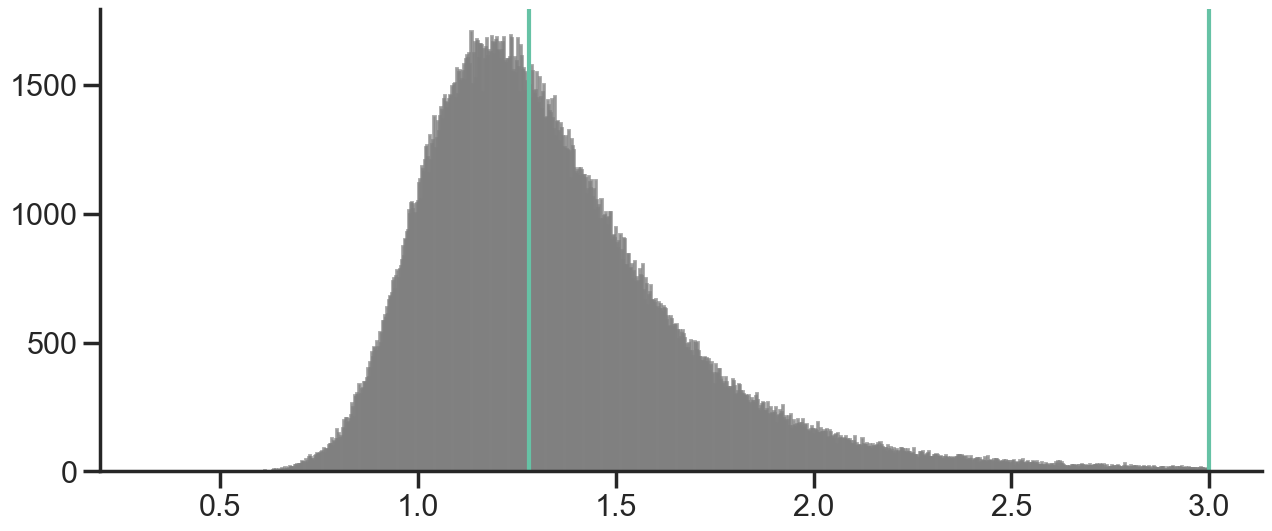

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15, 6))

subset = df.loc[((df['valids2']==1) & (df['valids']==1) & (df['batch']!='3B'))]
axes.hist(subset.corridor_latency, bins=1000, alpha=0.7, color='gray', edgecolor='gray')
axes.axvline(3)
axes.axvline(subset.corridor_latency.median())
sns.despine()

# SUBSET OF DATA COLLECTION IN NORMAL CONDITIONS ONLY

**DATA COLLECTION ONLY:**
- batch 3B & 34B & 6B  stages equal or above 4
- batch 5B & 7B stage equal or above 3
- batch 8B stage equal or above 2
- batch 9B & 10B stage above 2, or inside stage 2 only substage 3

In [47]:
df= df[
    ((df['batch'] == '3B') & (df['stage'] >= 4)) |
    ((df['batch'] == '34B')& (df['stage'] >= 4)) |
    ((df['batch'] == '6B') & (df['stage'] >= 4)) |
    ((df['batch'] == '5B') & (df['stage'] >= 3)) |
    ((df['batch'] == '7B') & (df['stage'] >= 3)) |
    ((df['batch'] == '8B') & (df['stage'] >= 3)) |
    ((df['batch'] == '9B') & (df['stage'] >= 3)) |
    ((df['batch'] == '10B') & ((df['stage'] > 2) | ((df['stage'] == 2) & (df['substage'] == 3))))]

df['manipulation'] = 0
df['correct_bool']=df['accuracy']


# df5 = df5.loc[~((df5['stage']< 4) & (df5['date'] >= '2021/04/13'))] #rm lower stages from certain point
# df5 = df5.loc[((df5['date']>='2021/03/27') & (df5['date']<'2021/05/31'))]
# # df7 = df7.loc[~((df7['task']=='StageTraining_7B_V2') & (df7['stage']<4))] # Stages before 4 nos qual probs 3 choices
# #df8=df8.loc[((df8['date']!='2023/03/25') & (df8['stage']>2))] #stage3 data collection (sub1 DS; sub2 DM,DL; sub3 DS,DM,DL)

Almost all the analysis will be done with t-maze 3 choices

# ACCURACY vs DELAY

In [12]:
# import rpy2.robjects as ro

# # Reset rpy2 options to default values
# ro.r('options(ri.threshold=Inf)')


In [44]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 

# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='correct_bool', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'acc_delay_subj.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_subj.png', transparent=False)


KeyError: 'manipulation'

In [45]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# # REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                     & (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 


# # REMOVE NON-WANTED SESSIONS
# to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
# to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
#                      & (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
#                       & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 
# ##select only the subjects that have all the ttypes
# subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
# to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]




# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n', 'prev_trial_result'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c,
             ax=axes, data=vg, ci=95,  err_style="bars", marker='o', zorder=10)

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes,  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c,
             data=wm, ci=95,  err_style="bars", marker='o', zorder=10)

sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c,
             ax=axes, data=sil, ci=95,  err_style="bars", marker='o', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_prev_outcome_subj_best.svg', transparent=False)
# plt.savefig(str(data_folder) + 'acc_delay_prev_outcome_subj_best.png', transparent=False)


KeyError: 'manipulation'

In [ ]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# # REMOVE NON-WANTED SESSIONS
# to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
# to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
#                      & (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
#                       & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 


# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                     & (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]




# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n', 'next_trial_result'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool',  hue='next_trial_result', hue_order=tresult_o, palette=tresult_c,
             ax=axes, data=vg, ci=95,  err_style="bars", marker='o', zorder=10)

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes,  hue='next_trial_result', hue_order=tresult_o, palette=tresult_c,
             data=wm, ci=95,  err_style="bars", marker='o', zorder=10)

sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', hue='next_trial_result', hue_order=tresult_o, palette=tresult_c,
             ax=axes, data=sil, ci=95,  err_style="bars", marker='o', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'acc_delay_prev_outcome_subj_best_next.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_prev_outcome_subj_best_next.png', transparent=False)

In [ ]:
n_trials = df_behavior.trial.max()
starting_time = df_behavior['STATE_Start_task_START'].iloc[0]
ending_time = df_behavior['STATE_Exit_START'].iloc[-1] - df_behavior['STATE_Start_task_START'].iloc[0]

##### BEHAVIOR  #####
print('BEHAVIOR:')
print('Session total duration (min): ' + str(ending_time/60))
print('Session trials: ' + str(n_trials))
print('Total Memory trials: ' + str(df_behavior.loc[df_behavior['trial_type'].str.contains('WM')]['trial_type'].count()))
print(df_behavior.trial_type.value_counts())

print('')
print('')

##### EPHYS TTLS  #####
print('EPHYS TTLs:')
print('Recording duration: ' + str(ttl_max_clock/60)+' min')
print('Number of Response Windows finished: ' + str(df_ttl['response_ttl'].sum()))
print('Number of delay trials: ' + str(df_ttl['delay_ttl'].sum()))  # should be equal to WMD + WMI
print('Number of corridor starts: ' + str(df_ttl['corridor_ttl'].sum()))


##### EPHYS SPIKETIMES  #####
print('EPHYS SPIKETIMES:')


# CHeck ttls and spikes sorted clocks coincide
spike_min_clock, spike_max_clock =min(df_spikes['timestamps_fix']),max(df_spikes['timestamps_fix'])
print('SPIKES')
print('Min time:'+str(spike_min_clock),'Max time:'+str(spike_max_clock))
print('Recording duration: ' + str(spike_max_clock/60)+' min')
print('')


diff_start = spike_min_clock-ttl_min_clock #TTL clock should start before the sorted spikes or same time
diff_end = ttl_max_clock-spike_max_clock #TTL clock should finish after the sorted spikes or same time
print('Onset ttls-spikes: ' +str(diff_start))
print('Offset ttls-spikes: ' +str(diff_end))

if diff_start<0 or diff_end<0:
    print('WARNING: Incorerect durations')
print('Initial ephys behavior time difference: ' +str(init_diff)+ ' | Total sec: ' +str(init_diff.total_seconds()))


## Best subjects

In [ ]:
xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))]

##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='correct_bool', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1, size=5)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Delay type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.3)

###LMM
# formula = 'correct_bool ~ C(ttype_n)'
# # Fit the mixed-effects model
# model = smf.mixedlm(formula, to_plot, groups=to_plot['subject']).fit()
# # Print the summary of the model
# print(model.summary())

# axes.text(0.35, 1, 'Mixed Linear Model', verticalalignment='bottom', horizontalalignment='right',
#         transform=axes.transAxes,  fontweight='bold', fontsize=20)
#Annotate the plot with significance stars
# y_list=[0.95, 0.8, 0.6, 0.45]
# for i, ttype in enumerate(ttypes_o[:-1]):
#     plt.text(ttype+0.6, y_list[i], '***', ha='center', va='center', fontsize=30, fontweight='bold')

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'acc_delay_subj_besT.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_subj_besT.png', transparent=False)



## by batch

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot= df.loc[((df['valids']==1) & (df['valids2']==1) & (df['valids3']==1)   & (df['manipulation']==0))] # Remove weird & select minimum engagement 


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))
axes=axes.flatten()

for idx, batch in enumerate(to_plot.batch.unique()):
    subset= to_plot.loc[to_plot['batch']==batch]
    n_subjects= len(subset.subject.unique())
    xmax=subset['ttype_n'].unique()[-1]+0.5
    xmin=subset['ttype_n'].unique()[0]-0.5
    grouped = subset.groupby(['subject', 'ttype_n'])['correct_bool'].mean().reset_index()

    # PLOT
    sns.stripplot(x='ttype_n',  y='correct_bool', hue='ttype_n', hue_order=ttypes_o,
                 ax=axes[idx], data=grouped, marker='o', palette=ttypes_c, zorder=1)

    vg=grouped[grouped['ttype_n']==0]
    sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes[idx], data=vg, ci=95,  err_style="bars", marker='o', 
                 color='black', zorder=10)
    wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
    sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes[idx], data=wm, ci=95,  err_style="bars", marker='o', 
                 color='black', zorder=10)
    sil = grouped[grouped['ttype_n']==4]
    sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes[idx], data=sil, ci=95,  err_style="bars", marker='o', 
                 color='black', zorder=10)

    axes[idx].set_title(batch, fontweight='bold')
    axes[idx].get_legend().remove()
    axes[idx].set_xlabel('Trial type')
    axes[idx].set_ylabel('Fraction correct responses')
    axes[idx].set_ylim(0.2, 1.05)
    axes[idx].text(0.3, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
            transform=axes[idx].transAxes, color='black', fontweight='bold')
    # axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
    axes[idx].fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_subj.svg', transparent=False)
# plt.savefig(str(data_folder) + 'acc_delay_subj.png', transparent=False)




## Delay abs

In [ ]:
xmax=5
xmin=0


# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0) & (to_plot['valids']==1))]

##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]
to_plot= to_plot.loc[((to_plot['ttype_n']>=1)  & (to_plot['ttype_n']<=3))]

to_plot['delay_abs_qbin'] = pd.qcut(to_plot['delay_abs'], q=10, labels=False)
grouped = to_plot.groupby(['subject', 'delay_abs_qbin'])['correct_bool'].mean().reset_index()


bins=15
to_plot['delay_bins'] = pd.qcut(to_plot.delay_abs, bins, duplicates='drop')
to_plot['delay_labels'] = to_plot.apply(lambda x: x['delay_bins'].mid, axis=1)


# # GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n', 'delay_labels'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

sns.lineplot(x='delay_labels',  y='correct_bool', hue='ttype_n', ax=axes, data=grouped, ci=95,  err_style="bars", marker='o', 
              zorder=10, palette=['#5E2A7E', '#9C69A3', '#C698CB'])


axes.set_xlabel('Delay (sec)')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
# axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()
axes.get_legend().remove()
axes.set_xlim(xmin, xmax)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.3)


plt.savefig(str(data_folder) + 'acc_delay_subj_besT_cont.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_subj_besT_cont.png', transparent=False)



In [ ]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['trial']>12))] # minimum engagement
to_plot= to_plot.loc[((to_plot['injection']=='Rest') & (to_plot['opto_on']==0))] # minimum engagement

# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n'])['misses'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='misses', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)
# sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=grouped, ci=95,  err_style="bars", marker='o', 
#              color='black', zorder=10)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='misses', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='misses', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='misses', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Fraction omissions')
# axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.85, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold')
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
# axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'miss_delay_subj.svg', transparent=False)
plt.savefig(str(data_folder) + 'miss_delay_subj.png', transparent=False)




# REPETITIONS VS DELAY

## hisotgram trial latency (to discard vey long trials = disengaged)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

to_plot= df.loc[df['trial_length']<100]

sns.histplot(to_plot.trial_length)
axes.axvline(df.trial_length.median(), color='gray', linestyle=':')
sns.despine()

## Repeating bias function

In [ ]:
sns.histplot(subset.response_first)

## Overall RB

In [ ]:

chance=1/3
xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 


# CALUCLATE REPAETING BIAS
columns=['subject', 'ttype_n']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

sns.stripplot(x='ttype_n',  y='RB', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='RB', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='RB', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)

sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='RB', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Repeating bias')
axes.set_ylim(0.23, 0.43)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold')
axes.hlines(y=0.33, xmin=xmin-0.15, xmax=xmax+0.15, color=lines_c, linestyle=':', linewidth=3)


sns.despine()
plt.tight_layout()


plt.savefig(str(data_folder) + 'rb_delay.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_delay.png', transparent=False)

## Best batches RB

In [ ]:
chance=1/3
xmax=ttypes_o[-1]-0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trials
# ##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

# CALUCLATE REPAETING BIAS
columns=['subject', 'ttype_n']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

sns.stripplot(x='ttype_n',  y='RB', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='RB', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='RB', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)

# sil = grouped[grouped['ttype_n']==4]
# sns.lineplot(x='ttype_n',  y='RB', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
#              color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Delay type')
axes.set_ylabel('Repeating bias')
axes.set_ylim(0.25, 0.425)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
plt.axhline(chance, color='gray', linestyle=':')


# ###LMM
# formula = 'RB ~ C(ttype_n)'
# Fit the mixed-effects model
#model = smf.mixedlm(formula, grouped, groups=grouped['subject']).fit()
# Print the summary of the model
#print(model.summary())

# axes.text(0.4, 1, 'Mixed Linear Model: ns', verticalalignment='bottom', horizontalalignment='right',
#         transform=axes.transAxes,  fontweight='bold', fontsize=20)
#Annotate the plot with significance stars
# y_list=[0.95, 0.8, 0.6, 0.45]
# for i, ttype in enumerate(ttypes_o[:-1]):
#     plt.text(ttype+0.6, y_list[i], '***', ha='center', va='center', fontsize=30, color='seagreen')

sns.despine()
plt.tight_layout()


plt.savefig(str(data_folder) + 'rb_delay_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_delay_best.png', transparent=False)


In [ ]:
# CALUCLATE REPAETING BIAS
columns=['subject']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())
grouped['x']=0

# Create the plot
plt.figure(figsize=(5, 8))
sns.boxplot(x='x', y='RB', data=grouped, whis=1.5, fliersize=0,  color='black', boxprops=dict(alpha=0.3),  linewidth=3,  width=0.5)
sns.stripplot(x='x', y='RB', data=grouped, alpha=0.8, jitter=True,  color='black', size=8)
# # sns.violinplot(x='prev_trial_result', y='RB', order=tresult_o, data=grouped, palette=tresult_c,  
# #               ax=axes)
# # Add lines connecting paired observations
# for subject in grouped['subject']:
#     subject_data = grouped[grouped['subject'] == subject]
#     try:
#         subject_data= subject_data.loc[subject_data['next_trial_result'].isin(['correct_first', 'punish'])]
#         plt.plot([0, 1], subject_data['RB'], color='gray', alpha=0.5, linewidth=0.5)
#     except:
#         pass
    
# # Annotate the plot with the test result
# x1, x2 = 0, 1   # positions of the boxes to be compared
# y, h, col = grouped['RB'].max()+0.01, 0.005, 'k'
# plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
# plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)
# plt.axhline(chance, color='gray', linestyle=':')
plt.axhline(chance, color='gray', linestyle=':')
sns.despine()
plt.xlim(-1, 1)
plt.ylabel('Repeating bias')

plt.ylim(0.25, 0.425)
plt.gca().xaxis.set_visible(False)
sns.despine() 
plt.tight_layout()

# plt.savefig(str(data_folder) + 'rb_outcome_paired_next_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_best.png', transparent=False)

## Overall RB by batch

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot= df.loc[((df['valids']==1) & (df['valids2']==1) & (df['valids3']==1)  &
                 (df['prev_valids']==1) & (df['prev_valids3']==1)& (df['prev_valids3']==1) & (df['manipulation']==0))] # Remove weird & select minimum engagement 

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))
axes=axes.flatten()

for idx, batch in enumerate(to_plot.batch.unique()):
    subset= to_plot.loc[to_plot['batch']==batch]
    n_subjects= len(subset.subject.unique())
    
    # CALUCLATE REPAETING BIAS
    columns=['subject', 'ttype_n']
    if batch!='34B':       
        grouped = rep_bias_calc(subset, columns)
    else:
        grouped = rep_bias_5C_calc(subset, columns)



    # PLOT
    sns.stripplot(x='ttype_n',  y='RB', hue='ttype_n', hue_order=ttypes_o,
             ax=axes[idx], data=grouped, marker='o', palette=ttypes_c, zorder=1)

    vg=grouped[grouped['ttype_n']==0]
    sns.lineplot(x='ttype_n',  y='RB', ax=axes[idx], data=vg, ci=95,  err_style="bars", marker='o', 
                 color='black', zorder=10)
    wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
    sns.lineplot(x='ttype_n',  y='RB', ax=axes[idx], data=wm, ci=95,  err_style="bars", marker='o', 
                 color='black', zorder=10)

    sil = grouped[grouped['ttype_n']==4]
    sns.lineplot(x='ttype_n',  y='RB', ax=axes[idx], data=sil, ci=95,  err_style="bars", marker='o', 
                 color='black', zorder=10)

    axes[idx].set_title(batch, fontweight='bold')
    axes[idx].get_legend().remove()
    axes[idx].set_xlabel('Trial type')
    axes[idx].set_ylabel('Repeating bias')
   
    if batch!='34B':
        axes[idx].set_ylim(0.23, 0.43)
        axes[idx].axhline(chance, color='gray', linestyle=':')
    else:
        axes[idx].set_ylim(0.1, 0.35)
        axes[idx].axhline(1/5, color='gray', linestyle=':')
    

    axes[idx].text(0.3, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
            transform=axes[idx].transAxes, color='black', fontweight='bold')

sns.despine()
plt.tight_layout()

##  RB by trial outcome

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))


# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 

columns=['subject', 'ttype_n', 'prev_trial_result']
groupby = rep_bias_calc(to_plot, columns)
n_subjects= len(to_plot.subject.unique())

# PLOT
vg=groupby[groupby['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             zorder=10)
wm=groupby[((groupby['ttype_n']>0) & (groupby['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             zorder=10)
sil = groupby[groupby['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
              zorder=10)

axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Repeating bias')
axes.set_ylim(0.25, 0.425)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold')
axes.axhline(chance, color='gray', linestyle=':')

lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in tresult_c]
axes.legend(lines, tresult_f, title='prev outcome')

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'rb_outcome_delay.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_outcome_delay.png', transparent=False)

## Best batches RB outcome

In [ ]:
chance=1/3
xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

# CALUCLATE REPAETING BIAS
columns=['subject', 'prev_trial_result', 'ttype_n']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             zorder=10)
# sil = grouped[grouped['ttype_n']==4]
# sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
#               zorder=10)

axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Delay type')
axes.set_ylabel('Repeating bias')
axes.set_ylim(0.25, 0.425)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
axes.axhline(chance, color='gray', linestyle=':')
lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in tresult_c]
axes.legend(lines, tresult_f, title='prev outcome')


# # ###LMM
# formula = 'RB ~ C(ttype_n) * C(prev_trial_result)'
# #remove nans
# df_clean = grouped.dropna(subset=['RB'])
# # Fit the mixed-effects model
# model = smf.mixedlm(formula, df_clean, groups=df_clean['subject']).fit()
# # Print the summary of the model
# print(model.summary())

# axes.text(0.4, 1, 'Mixed Linear Model: ns', verticalalignment='bottom', horizontalalignment='right',
#         transform=axes.transAxes,  fontweight='bold', fontsize=20)
#Annotate the plot with significance stars
# y_list=[0.95, 0.8, 0.6, 0.45]
# for i, ttype in enumerate(ttypes_o[:-1]):
#     plt.text(ttype+0.6, y_list[i], '***', ha='center', va='center', fontsize=30, color='seagreen')

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'rb_outcome_delay_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_outcome_delay_best.png', transparent=False)

In [ ]:
chance=1/3
xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

# CALUCLATE REPAETING BIAS
columns=['subject', 'next_trial_result', 'ttype_n']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='RB',  hue='next_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='RB',  hue='next_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='RB',  hue='next_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
              zorder=10)

axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Repeating bias')
axes.set_ylim(0.25, 0.425)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
axes.hlines(y=0.33, xmin=xmin-0.15, xmax=xmax+0.15, color=lines_c, linestyle=':', linewidth=3)

lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in tresult_c]
axes.legend(lines, tresult_f, title='next outcome')

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'rb_outcome_delay_best_next.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_outcome_delay_best_next.png', transparent=False)

## by batch RB outcome

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot= df.loc[((df['valids']==1) & (df['valids2']==1) & (df['valids3']==1)  &
         (df['prev_valids']==1) & (df['prev_valids3']==1)& (df['prev_valids3']==1) & (df['manipulation']==0))] # Remove weird & select minimum engagement 

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))
axes=axes.flatten()

for idx, batch in enumerate(to_plot.batch.unique()):
    subset= to_plot.loc[to_plot['batch']==batch]
    n_subjects= len(subset.subject.unique())
    
    # CALUCLATE REPAETING BIAS
    columns=['subject', 'ttype_n', 'prev_trial_result']
    if batch!='34B':
        grouped = rep_bias_calc(subset, columns)
    else:
        grouped = rep_bias_5C_calc(subset, columns)


    # PLOT
    sns.stripplot(x='ttype_n',  y='RB', hue='prev_trial_result', hue_order=tresult_o,
             ax=axes[idx], data=grouped, marker='o', palette=tresult_c, zorder=1)

    vg=grouped[grouped['ttype_n']==0]
    sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes[idx], data=vg, ci=95,  err_style="bars", marker='o', 
                  zorder=10)
    wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
    sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes[idx], data=wm, ci=95,  err_style="bars", marker='o', 
                 zorder=10)

    sil = grouped[grouped['ttype_n']==4]
    sns.lineplot(x='ttype_n',  y='RB',  hue='prev_trial_result', hue_order=tresult_o, palette=tresult_c, ax=axes[idx], data=sil, ci=95,  err_style="bars", marker='o', 
                 zorder=10)

    axes[idx].set_title(batch, fontweight='bold')
    axes[idx].get_legend().remove()
    axes[idx].set_xlabel('Trial type')
    axes[idx].set_ylabel('Repeating bias')
    axes[idx].text(0.3, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
            transform=axes[idx].transAxes, color='black', fontweight='bold')
    if batch!='34B':
        axes[idx].set_ylim(0.23, 0.43)
        axes[idx].axhline(chance, color='gray', linestyle=':')
    else:
        axes[idx].set_ylim(0.1, 0.35)
        axes[idx].axhline(1/5, color='gray', linestyle=':')
    


sns.despine()
plt.tight_layout()

## RB outcome paired plot 

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 


to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
# ##select only the subjects that have all the ttypes
# subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
# to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]


columns=['subject', 'next_trial_result']
grouped = rep_bias_calc(to_plot, columns)


##### STATS


# Separate data based on 'prev_trial_result'
correct_first_data = grouped[grouped['next_trial_result'] == 'correct_first']
punish_data = grouped[grouped['next_trial_result'] == 'punish']

# Merge data on 'subject' to ensure pairs
paired_data = pd.merge(correct_first_data, punish_data, on='subject', suffixes=('_correct_first', '_punish'))

# Check if data is paired (should have the same number of observations)
if len(correct_first_data) != len(punish_data):
    raise ValueError("Data must be paired with the same number of observations in each group.")

# Calculate differences
differences = paired_data['RB_correct_first'] - paired_data['RB_punish']


# Drop rows with any missing values
paired_data.dropna(inplace=True)

# Check normality of the differences
shapiro_test = stats.shapiro(differences)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

# Visual check for normality
sns.histplot(differences, kde=True)
plt.title('Histogram of Differences')
plt.show()

stats.probplot(differences, dist="norm", plot=plt)
plt.title('Q-Q Plot of Differences')
plt.show()

# Decide which test to use based on normality
if shapiro_test.pvalue > 0.05:
    # If differences are normally distributed, use paired t-test
    t_stat, p_val = stats.ttest_rel(paired_data['RB_correct_first'], paired_data['RB_punish'])
    print(f"Paired t-test result: statistic={t_stat}, p-value={p_val}")
else:
    # If differences are not normally distributed, use Wilcoxon signed-rank test
    w_stat, p_val = stats.wilcoxon(paired_data['RB_correct_first'], paired_data['RB_punish'])
    print(f"Wilcoxon signed-rank test result: statistic={w_stat}, p-value={p_val}")
    
    

# Create the plot
plt.figure(figsize=(5, 8))
sns.boxplot(x='next_trial_result', y='RB', data=grouped, whis=1.5, fliersize=0, order=tresult_o,  palette=tresult_c)
sns.stripplot(x='next_trial_result', y='RB', data=grouped, color='black', alpha=0.6, jitter=True, order=tresult_o,  palette=tresult_c)
# sns.violinplot(x='prev_trial_result', y='RB', order=tresult_o, data=grouped, palette=tresult_c,  
#               ax=axes)
# Add lines connecting paired observations
for subject in grouped['subject']:
    subject_data = grouped[grouped['subject'] == subject]
    try:
        subject_data= subject_data.loc[subject_data['next_trial_result'].isin(['correct_first', 'punish'])]
        plt.plot([0, 1], subject_data['RB'], color='gray', alpha=0.5, linewidth=0.5)
    except:
        pass
    
# Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['RB'].max()+0.01, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)
plt.axhline(chance, color='gray', linestyle=':')

sns.despine()

sns.despine() 
plt.tight_layout()

plt.savefig(str(data_folder) + 'rb_outcome_paired_next_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_outcome_paired_next_best.png', transparent=False)

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()

# CALUCLATE REPAETING BIAS
columns=['subject', 'prev_trial_result']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())



fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# Create the plot
boxplot = sns.boxplot(x='prev_trial_result', y='RB', data=grouped, fliersize=0,  order=tresult_o,  palette=tresult_c, 
                  boxprops=dict(alpha=0.3),    linewidth=3,  width=0.5,    linecolor='white')

# Add lines connecting paired observations
grouped['x_scatter'] = grouped['prev_trial_result'].replace(tresult_o, [0, 1])
grouped['x2'] = grouped['x_scatter'] + np.random.normal(loc=0, scale=0.05, size=len(grouped))
for idx, s in enumerate(grouped.subject.unique()):
    x = []
    y = []
    for idd, o in enumerate(tresult_o):
        xpoint = grouped.loc[(grouped['subject'] == s) & (grouped['prev_trial_result'] == o), 'x2'].mean()
        ypoint = grouped.loc[(grouped['subject'] == s) & (grouped['prev_trial_result'] == o), 'RB'].mean()
        plt.plot(xpoint, ypoint, marker='o', color=tresult_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)

    
# T-test paired
correct_first_data = grouped[grouped['prev_trial_result'] == 'correct_first']['RB']
punish_data = grouped[grouped['prev_trial_result'] == 'punish']['RB']

t_stat, p_val = ttest_rel(correct_first_data, punish_data)


# Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['RB'].max()+0.01, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)
plt.axhline(chance, color='gray', linestyle=':')

axes.set_xlim(-0.5, 1.5)
plt.ylabel('Repeating bias')
plt.ylim(0.25, 0.425)
plt.xlabel('Prev. outcome')
plt.xticks([0, 1], ['Correct', 'Incorrect'])
sns.despine() 
plt.tight_layout()
plt.savefig(str(data_folder) + 'rb_outcome_paired_prev_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_outcome_paired_prev_best.png', transparent=False)



In [ ]:
grouped.next_trial_result.unique()

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]
to_plot = to_plot.loc[to_plot['next_trial_result'].isin(['correct_first', 'punish'])]
# CALUCLATE REPAETING BIAS
columns=['subject', 'next_trial_result']
grouped = rep_bias_calc(to_plot, columns)
n_subjects= len(grouped.subject.unique())



fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# Create the plot
boxplot = sns.boxplot(x='next_trial_result', y='RB', data=grouped, fliersize=0,  order=tresult_o,  palette=tresult_c, 
                  boxprops=dict(alpha=0.3),    linewidth=3,  width=0.5,    linecolor='white')
# Add lines connecting paired observations
grouped['x_scatter'] = grouped['next_trial_result'].replace(tresult_o, [0, 1])
grouped['x2'] = grouped['x_scatter'] + np.random.normal(loc=0, scale=0.05, size=len(grouped))

for idx, s in enumerate(grouped.subject.unique()):
    x = []
    y = []
    for idd, o in enumerate(tresult_o):
        xpoint = grouped.loc[(grouped['subject'] == s) & (grouped['next_trial_result'] == o), 'x2'].mean()
        ypoint = grouped.loc[(grouped['subject'] == s) & (grouped['next_trial_result'] == o), 'RB'].mean()
        plt.plot(xpoint, ypoint, marker='o', color=tresult_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)

    
# T-test paired
correct_first_data = grouped[grouped['next_trial_result'] == 'correct_first']['RB']
punish_data = grouped[grouped['next_trial_result'] == 'punish']['RB']

t_stat, p_val = ttest_rel(correct_first_data, punish_data)


# Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['RB'].max()+0.01, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)
plt.axhline(chance, color='gray', linestyle=':')

axes.set_xlim(-0.5, 1.5)
plt.ylabel('Repeating bias')
plt.ylim(0.25, 0.425)
plt.xlabel('Next outcome')
plt.xticks([0, 1], ['Correct', 'Incorrect'])
sns.despine() 
plt.tight_layout()


plt.savefig(str(data_folder) + 'rb_outcome_paired_next_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'rb_outcome_paired_next_best.png', transparent=False)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

grouped=df.groupby(['subject', 'batch'])['total_trials'].sum().reset_index()

sns.stripplot(x='batch', y='total_trials', data=grouped, s=15)
sns.despine()

In [ ]:
# Delay abs means

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['trial_length']<40) & (to_plot['prev_trial_length']<40) & (to_plot['trial']>12))] # minimum engagement
to_plot= to_plot.loc[((to_plot['injection']=='Rest') & (to_plot['opto_on']==0))] # minimum engagement


grouped= to_plot.groupby(['subject', 'ttype_n'])['delay_abs'].median().reset_index()
n_subjects= len(grouped.subject.unique())

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='delay_abs', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)
# sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=grouped, ci=95,  err_style="bars", marker='o', 
#              color='black', zorder=10)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='delay_abs', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='delay_abs', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='delay_abs', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Delay absolute (sec)')
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold')

sns.despine()
plt.tight_layout()

print(grouped.groupby('ttype_n')['delay_abs'].median())

plt.savefig(str(data_folder) + 'delay_delay_subj.svg', transparent=False)
plt.savefig(str(data_folder) + 'delay_delay_subj.png', transparent=False)




In [ ]:
# take sessions from the begining of the time

# SERIAL BIAS

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 8))
axes=axes.flatten()

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
to_plot= to_plot.loc[to_plot['prev_trial_result']=='correct_first'] #only after correct
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]


for idx, x in enumerate([-1, 0, 1]):
    subset = to_plot.loc[((to_plot['x_n']==x) &(to_plot['prev_trial_result']=='correct_first'))] 
    sns.histplot(data=subset, x="response_x_first", hue="prev_r_n", bins=50, element="step",ax=axes[idx]) # bins 50-100
    if idx>0:
        axes[idx].get_legend().remove()

# axes.set_xlim(150, 250)
# axes.axvline(df.trial_length.median(), color='gray', linestyle=':')
sns.despine()

#plt.savefig(str(data_folder) + 'hist_resp_hole.png', transparent=False)


# binnin thinner very messy
# include centre previous I cant see anything

In [ ]:
# take only centre reponses mean

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 
to_plot= to_plot.loc[to_plot['prev_trial_result']=='correct_first'] #only after correct



subject_mean= to_plot.groupby('subject')['response_x_first'].mean().reset_index()
subject_mean.rename(columns={'response_x_first': 'mean_resp_subj'}, inplace=True)
stimulus_mean = to_plot.groupby(['subject', 'prev_r_n'])['response_x_first'].mean().reset_index()


# Merge the two DataFrames on 'subject' to combine the results
result_df = pd.merge(subject_mean, stimulus_mean, on='subject', how='outer')

#Calculate difference
result_df['difference']= result_df['response_x_first'] - result_df['mean_resp_subj']


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 9))
sns.stripplot(x='prev_r_n',  y='difference', hue='prev_r_n', hue_order=stim_o, 
             palette=stim_c, ax=axes, data=result_df,)
sns.pointplot(x='prev_r_n',  y='difference', ax=axes, data=result_df, 
           ci=95, color='black')
axes.axhline(0, linestyle=':', color='silver')

sns.despine()


# plt.savefig(str(data_folder) + 'serial_bias.svg', transparent=True)
# plt.savefig(str(data_folder) + 'serial_bias.png', transparent=True)

## By trial type

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
axes= axes.flatten()


for idx, ttype in enumerate(['VG', 'DS', 'DM', 'DL', 'SIL']):
    subset= to_plot.loc[to_plot['ttype_c']==ttype]
    
    #mean of response location for each subject
    subject_mean= subset.groupby('subject')['response_x_first'].mean().reset_index()
    subject_mean.rename(columns={'response_x_first': 'mean_resp_subj'}, inplace=True)
    
    #mean depending on previous response
    stimulus_mean = subset.groupby(['subject', 'prev_r_n'])['response_x_first'].mean().reset_index()

   
    # Merge the two DataFrames on 'subject' to combine the results
    result_df = pd.merge(subject_mean, stimulus_mean, on='subject', how='outer')

    # Calculate difference
    result_df['difference']= result_df['response_x_first'] - result_df['mean_resp_subj']
    
    # Plot
    sns.stripplot(x='prev_r_n',  y='difference', hue='prev_r_n', hue_order=stim_o, 
             palette=stim_c,
             ax=axes[idx], data=result_df,)
    sns.pointplot(x='prev_r_n',  y='difference', ax=axes[idx], data=result_df, 
           ci=95, color='black')
    axes[idx].axhline(0, linestyle=':', color='silver')
    axes[idx].set_title(str(ttype), fontweight='bold')
    axes[idx].get_legend().remove()
    axes[idx].set_xticklabels(['Left', 'Centre', 'Right'])
    axes[idx].set_ylim(-30, 30)
    
    
    axes[idx].set_ylabel('Bias')
    if idx < 3:
        axes[idx].set_xlabel('')
    else:
        axes[idx].set_xlabel('Previous response')        
        axes[5].axis("off")
            
            

sns.despine()

# plt.savefig(str(data_folder) + 'serial_bias_delay.svg', transparent=True)
# plt.savefig(str(data_folder) + 'serial_bias_delay.png', transparent=True)


In [ ]:

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK  & (df['batch']!='9B')
to_plot= to_plot.loc[((to_plot['injection']=='Rest') & (to_plot['opto_on']==0))] # remove opro/pharma sessions
to_plot = to_plot.loc[((to_plot['x_c']==0) &(to_plot['r_c']==0)& (to_plot['prev_trial_result']=='correct_first')  & (to_plot['trial']>12))] 
to_plot= to_plot.loc[((to_plot['trial_result']!='miss') & (to_plot['prev_trial_result']!='miss'))]
to_plot= to_plot.loc[((to_plot['trial_length']<40))] # minimum engagement
to_plot = to_plot.loc[to_plot['ttype_n']!=4]


In [ ]:
sns.histplot(data=to_plot, x="response_first", bins=100, element="step") # bins 50-100


In [ ]:
data_matrix = to_plot[['response_first', 'prev_r_c', 'ttype_n', 'subject', 'session', 'date']]

In [ ]:
min_value = to_plot.response_first.min()
max_value = to_plot.response_first.max()
data_matrix['norm_response_first']=(data_matrix['ttype_n'] - min_value) / (max_value - min_value)
data_matrix['norm_ttype_n'] = data_matrix['ttype_n'].replace([0, 1, 2, 3],[0, 0.25, 0.5, 0.75])#renamed 


In [ ]:
# LMM
md = smf.mixedlm("norm_response_first ~ prev_r_c + norm_ttype_n", groups='subject', data=data_matrix)
mdf = md.fit()
print(mdf.summary())

## take only 3B with pharma

In [ ]:
###### TO DO!!!!!!
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B') & (df['batch']!='9B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['trial_length']<40) & (to_plot['prev_trial_length']<40) & (to_plot['trial']>12))] # minimum engagement
to_plot= to_plot.loc[((to_plot['injection']=='Rest') & (to_plot['opto_on']==0))]
to_plot= to_plot.loc[((to_plot['trial_result']!='miss') & (to_plot['prev_trial_result']!='miss'))]



# ATTRACTION BIAS

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5), sharey=True, sharex=True)
axes= axes.flatten()
x_n_list=[-1, 0, 1]
levels= [-2, -1, 0, 1, 2]

# # REMOVE NON-WANTED SESSIONS
# to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
# to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
#                       (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
#                       & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
# to_plot= to_plot.loc[to_plot['prev_trial_result']=='correct_first'] #only after correct
# ##select only the subjects that have all the ttypes
# subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
# to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 
to_plot= to_plot.loc[to_plot['prev_trial_result']=='correct_first'] #only after correct




all_list = []
for idx, ttype in enumerate(['VG', 'DS', 'DM', 'DL', 'SIL']):
    subset= to_plot.loc[to_plot['ttype_c']==ttype]
    axes[idx].set_title(str(ttype), fontweight='bold')


    # Create a dataframe with  rt-1  xt rt combinations (27)
    dict_prevr={}
    for prevr in x_n_list: # loop across previous response positions -1(L), 0(C), 1(R)
        
        dict_x={}
        for x in x_n_list: # loop across current stimulus
            sub1 = subset.loc[((subset['prev_r_n']==prevr) &  (subset['x_n']==x))]
            
            dict_r={} 
            for r in x_n_list: # loop sub1 current response
                sub2= sub1.loc[sub1['r_n']==r]
                frac=sub2.shape[0]/sub1.shape[0] #response fraction
                dict_r[r]=frac
            #
            dict_x[x] = dict_r
        #
        dict_prevr[prevr]=dict_x

    new_plot = pd.DataFrame.from_dict({(i,j, k): dict_prevr[i][j][k]
                               for i in dict_prevr.keys() 
                               for j in dict_prevr[i].keys() 
                               for k in dict_prevr[i][j].keys() },
                           orient='index').reset_index()
    
    # create a column for  rt-1  st rt
    index=pd.DataFrame(new_plot['index'].tolist(), index=new_plot.index)
    mapping = {index.columns[0]: 'Prev response', index.columns[1]: 'Current stimulus', index.columns[2]: 'Current response'}
    index = index.rename(columns=mapping)

    new_plot2=pd.concat([index, new_plot],axis=1) #merge 2 
    mapping={new_plot2.columns[4]: 'Frac'}
    new_plot2 = new_plot2.rename(columns=mapping)

    # create a dataframe by stimulus (-1, 0, 1)
    dict_stim={}

    for x in x_n_list:
        sub3=new_plot2.loc[new_plot2['Current stimulus']==x]
        sub4=sub3.pivot(values='Frac', index='Prev response', columns='Current response').sort_index(axis=0,  ascending=False)
        dict_stim[x] = sub4

    new_plot3= pd.concat([dict_stim[-1], dict_stim[0], dict_stim[1]]).groupby(level=0).mean().sort_index(axis=0,  ascending=False)
    
    
    # take the diagonals of the matrix
    new_plot4=[]
    for l in levels:
        diagonal=np.fliplr(new_plot3).diagonal(l) 
        diagonal_m=diagonal.mean()
        new_plot4.append([l, diagonal_m])

    new_plot5 = pd.DataFrame(new_plot4, columns =['x', 'val'], dtype = float) #.sort_index(axis=0,  ascending=False)
    new_plot5['x_sign'] = new_plot5['x'] * -1
    new_plot5['x_abs'] =new_plot5['x'].abs()


#     sns.barplot(data=new_plot5, x="x_abs", y='val',  ax=axes[idx], palette='YlGnBu_r')
    sns.lineplot(data=new_plot5, x="x_abs", y='val',  marker='o', ax=axes[idx], color='green')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].set_ylim(0.25, 0.43)
    sns.despine()
    axes[idx].axhline(0.33, linestyle=':', color='black')

    

# plt.savefig(str(data_folder) + 'att_bias_delay_best_corr.svg', transparent=True)
# plt.savefig(str(data_folder) + 'att_bias_delay_best_corr.png', transparent=True)


In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5), sharey=True, sharex=True)
axes= axes.flatten()
x_n_list=[-1, 0, 1]
levels= [-2, -1, 0, 1, 2]


# REMOVE NON-WANTED SESSIONS
# to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
# to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
#                       (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
#                       & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
# to_plot= to_plot.loc[to_plot['prev_trial_result']=='punish'] #only after correct
# ##select only the subjects that have all the ttypes
# subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
# to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) & 
                      (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)
                      & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 
to_plot= to_plot.loc[to_plot['prev_trial_result']=='punish'] #only after correct


all_list = []
for idx, ttype in enumerate(['VG', 'DS', 'DM', 'DL', 'SIL']):
    subset= to_plot.loc[to_plot['ttype_c']==ttype]
    axes[idx].set_title(str(ttype), fontweight='bold')


    # Create a dataframe with  rt-1  xt rt combinations (27)
    dict_prevr={}
    for prevr in x_n_list: # loop across previous response positions -1(L), 0(C), 1(R)
        
        dict_x={}
        for x in x_n_list: # loop across current stimulus
            sub1 = subset.loc[((subset['prev_r_n']==prevr) &  (subset['x_n']==x))]
            
            dict_r={} 
            for r in x_n_list: # loop sub1 current response
                sub2= sub1.loc[sub1['r_n']==r]
                frac=sub2.shape[0]/sub1.shape[0] #response fraction
                dict_r[r]=frac
            #
            dict_x[x] = dict_r
        #
        dict_prevr[prevr]=dict_x

    new_plot = pd.DataFrame.from_dict({(i,j, k): dict_prevr[i][j][k]
                               for i in dict_prevr.keys() 
                               for j in dict_prevr[i].keys() 
                               for k in dict_prevr[i][j].keys() },
                           orient='index').reset_index()
    
    # create a column for  rt-1  st rt
    index=pd.DataFrame(new_plot['index'].tolist(), index=new_plot.index)
    mapping = {index.columns[0]: 'Prev response', index.columns[1]: 'Current stimulus', index.columns[2]: 'Current response'}
    index = index.rename(columns=mapping)

    new_plot2=pd.concat([index, new_plot],axis=1) #merge 2 
    mapping={new_plot2.columns[4]: 'Frac'}
    new_plot2 = new_plot2.rename(columns=mapping)

    # create a dataframe by stimulus (-1, 0, 1)
    dict_stim={}

    for x in x_n_list:
        sub3=new_plot2.loc[new_plot2['Current stimulus']==x]
        sub4=sub3.pivot(values='Frac', index='Prev response', columns='Current response').sort_index(axis=0,  ascending=False)
        dict_stim[x] = sub4

    new_plot3= pd.concat([dict_stim[-1], dict_stim[0], dict_stim[1]]).groupby(level=0).mean().sort_index(axis=0,  ascending=False)
    
    
    # take the diagonals of the matrix
    new_plot4=[]
    for l in levels:
        diagonal=np.fliplr(new_plot3).diagonal(l) 
        diagonal_m=diagonal.mean()
        new_plot4.append([l, diagonal_m])

    new_plot5 = pd.DataFrame(new_plot4, columns =['x', 'val'], dtype = float) #.sort_index(axis=0,  ascending=False)
    new_plot5['x_sign'] = new_plot5['x'] * -1
    new_plot5['x_abs'] =new_plot5['x'].abs()


#     sns.barplot(data=new_plot5, x="x_abs", y='val',  ax=axes[idx], palette='YlGnBu_r')
    sns.lineplot(data=new_plot5, x="x_abs", y='val',  marker='o', ax=axes[idx], color='firebrick')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].set_ylim(0.25, 0.43)
    sns.despine()
    axes[idx].axhline(0.33, linestyle=':', color='black')



# plt.savefig(str(data_folder) + 'att_bias_delay_best_inc.svg', transparent=True)
# plt.savefig(str(data_folder) + 'att_bias_delay_best_inc.png', transparent=True)


In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
axes= axes.flatten()
x_c_list=[-1, 0, 1]
levels= [-2, -1, 0, 1, 2]


all_list = []
for idx, ttype in enumerate(['VG', 'DS', 'DM', 'DL', 'SIL']):
    subset= to_plot.loc[to_plot['ttype_c']==ttype]
    axes[idx].set_title(str(ttype), fontweight='bold')


    # Create a dataframe with  rt-1  xt rt combinations (27)
    dict_prevr={}
    for prevr in x_c_list: # loop across previous response positions -1(L), 0(C), 1(R)
        
        dict_x={}
        for x in x_c_list: # loop across current stimulus
            sub1 = subset.loc[((subset['prev_r_c']==prevr) &  (subset['x_c']==x))]
            
            dict_r={} 
            for r in x_c_list: # loop sub1 current response
                sub2= sub1.loc[sub1['r_c']==r]
                frac=sub2.shape[0]/sub1.shape[0] #response fraction
                dict_r[r]=frac
            #
            dict_x[x] = dict_r
        #
        dict_prevr[prevr]=dict_x

    new_plot = pd.DataFrame.from_dict({(i,j, k): dict_prevr[i][j][k]
                               for i in dict_prevr.keys() 
                               for j in dict_prevr[i].keys() 
                               for k in dict_prevr[i][j].keys() },
                           orient='index').reset_index()
    
    # create a column for  rt-1  st rt
    index=pd.DataFrame(new_plot['index'].tolist(), index=new_plot.index)
    mapping = {index.columns[0]: 'Prev response', index.columns[1]: 'Current stimulus', index.columns[2]: 'Current response'}
    index = index.rename(columns=mapping)

    new_plot2=pd.concat([index, new_plot],axis=1) #merge 2 
    mapping={new_plot2.columns[4]: 'Frac'}
    new_plot2 = new_plot2.rename(columns=mapping)

    # create a dataframe by stimulus (-1, 0, 1)
    dict_stim={}

    for x in x_c_list:
        sub3=new_plot2.loc[new_plot2['Current stimulus']==x]
        sub4=sub3.pivot(values='Frac', index='Prev response', columns='Current response').sort_index(axis=0,  ascending=False)
        dict_stim[x] = sub4

    new_plot3= pd.concat([dict_stim[-1], dict_stim[0], dict_stim[1]]).groupby(level=0).mean().sort_index(axis=0,  ascending=False)
    
    
    # take the diagonals of the matrix
    new_plot4=[]
    for l in levels:
        diagonal=np.fliplr(new_plot3).diagonal(l) 
        diagonal_m=diagonal.mean()
        new_plot4.append([l, diagonal_m])

    new_plot5 = pd.DataFrame(new_plot4, columns =['x', 'val'], dtype = float) #.sort_index(axis=0,  ascending=False)
    new_plot5['x_sign'] = new_plot5['x'] * -1
    new_plot5['x_abs'] =new_plot5['x'].abs()


    sns.barplot(data=new_plot5, x="x_abs", y='val',  ax=axes[idx], palette='YlGnBu_r')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    sns.despine()
    

    
    # store DataFrame in list
    all_list.append(new_plot5)

all_df = pd.concat(all_list)

# OMISSIONS

# STIMULUS DURATION ACCURACY

In [ ]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5



# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

grouped = to_plot.groupby(['subject', 'ttype_n', 'stimd_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool', err_style="bars",
             ax=axes, data=vg, ci=68,  marker='o', color='black')

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]

sns.lineplot(x='ttype_n',  y='correct_bool',  hue='stimd_n', hue_order=stimd_o,  err_style="bars" ,
             ax=axes, data=wm, ci=68,  marker='o', color='black',  palette=stimd_c)


sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=sil, ci=68,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.set_xlabel('Delay type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.3)
lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in stimd_c]
axes.legend(lines, stimd_f, title='Stim duration')


sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'acc_delay_stim.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_stim.png', transparent=False)

In [ ]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]+0.5


# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]
to_plot = to_plot.loc[to_plot['stimd_n']==1]



fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

grouped = to_plot.groupby(['subject', 'ttype_n', 'stimd_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# vg=grouped[grouped['ttype_n']==0]
# sns.lineplot(x='ttype_n',  y='correct_bool', err_style="bars",
#              ax=axes, data=vg, ci=68,  marker='o', color='black')

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]

sns.lineplot(x='ttype_n',  y='correct_bool',  hue='stimd_n', hue_order=stimd_o,  err_style="bars" ,
             ax=axes, data=wm, ci=68,  marker='o', color='black',  palette=stimd_c)


# sil = grouped[grouped['ttype_n']==4]
# sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=sil, ci=68,  err_style="bars", marker='o', 
#              color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.set_xlabel('Delay type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.3)
lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in [stimd_c[0]]]
axes.legend(lines, ['Short'], title='Stim duration')


sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_stim.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_stim_short.png', transparent=False)

In [ ]:
grouped['stimd_n'].unique()

In [ ]:

xmax=ttypes_o[-1]-0.5
xmin=ttypes_o[0]-0.5

stimd_c2 = ["#FFB74D", "#FB8C00", "#EF6C00"] #oranges
stimd_n2=[1, 2, 3, 4]
stimd_f2=[1, 2, 3, 4]

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

to_plot = to_plot.loc[(to_plot['ttype_n']==1)]


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

grouped = to_plot.groupby(['subject','stimd_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# grouped['stimd_n'] = grouped['stimd_n'].replace([1, 2, 3],[0,1,2]) #renamed
sns.stripplot(x='stimd_n',  y='correct_bool', hue='stimd_n', hue_order=stimd_n2,
             ax=axes, data=grouped, marker='o', palette=stimd_c2, zorder=1, size=5)
grouped['stimd_n'] = grouped['stimd_n'].replace([1, 2, 3],[0,1,2]) #renamed

sns.lineplot(x='stimd_n',  y='correct_bool',   err_style="bars" ,
             ax=axes, data=grouped, ci=68,  marker='o', color='black')



# axes.set_xticks(ttypes_o)
axes.set_xticklabels(['Short', 'Med', 'Long'])
axes.set_xlabel('Stimulus duration')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.3)
lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in stimd_c2]
axes.legend(lines, stimd_f, title='Stim duration')
axes.get_legend().remove()

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_stim.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_stimdur.png', transparent=False)

In [ ]:
xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))]

##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='correct_bool', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1, size=5)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Delay type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.3)

###LMM
# formula = 'correct_bool ~ C(ttype_n)'
# # Fit the mixed-effects model
# model = smf.mixedlm(formula, to_plot, groups=to_plot['subject']).fit()
# # Print the summary of the model
# print(model.summary())

# axes.text(0.35, 1, 'Mixed Linear Model', verticalalignment='bottom', horizontalalignment='right',
#         transform=axes.transAxes,  fontweight='bold', fontsize=20)
#Annotate the plot with significance stars
# y_list=[0.95, 0.8, 0.6, 0.45]
# for i, ttype in enumerate(ttypes_o[:-1]):
#     plt.text(ttype+0.6, y_list[i], '***', ha='center', va='center', fontsize=30, fontweight='bold')

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'acc_delay_subj_besT.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_subj_besT.png', transparent=False)



# IDEOSYNCRATIC BIASES

## Global

FileNotFoundError: [Errno 2] No such file or directory: '/home/balma/DATA/overall_plots/All/side_bias_delay_best.svg'

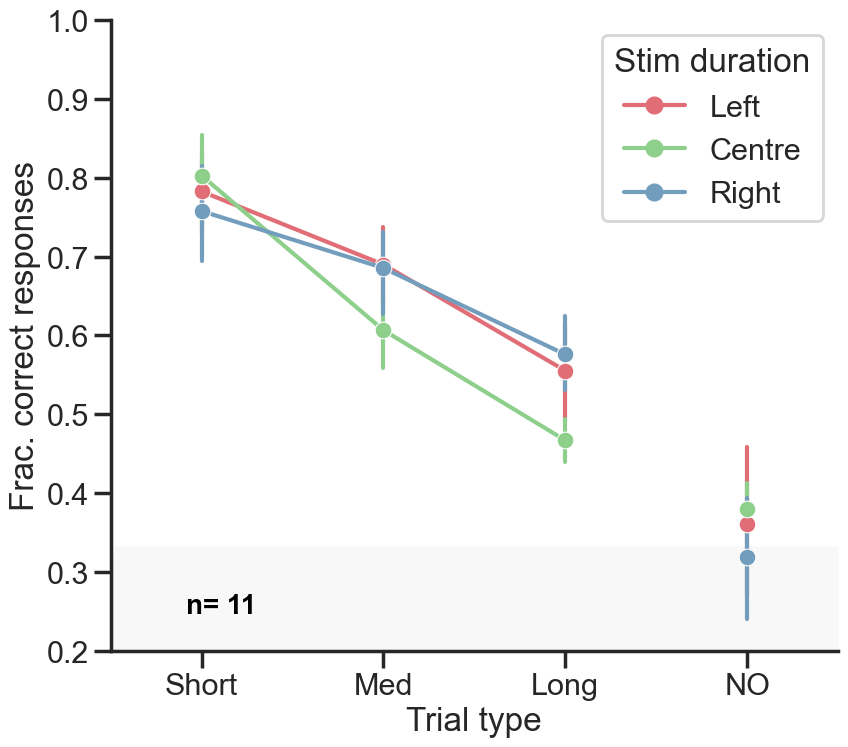

In [60]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))


# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]


grouped = to_plot.groupby(['subject', 'ttype_n', 'x_n'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())


vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_n', hue_order=stim_o, ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             palette=stim_c, zorder=10)

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_n', hue_order=stim_o, ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             palette=stim_c, zorder=10)

sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_n', hue_order=stim_o, ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             palette=stim_c, zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in stim_c]
axes.legend(lines, stim_f, title='Stim duration')

axes.set_xlabel('Trial type')
axes.set_ylabel('Frac. correct responses')
axes.set_ylim(0.2, 1)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold',  fontsize=20)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'side_bias_delay_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'side_bias_delay_best.png', transparent=False)

## by batch

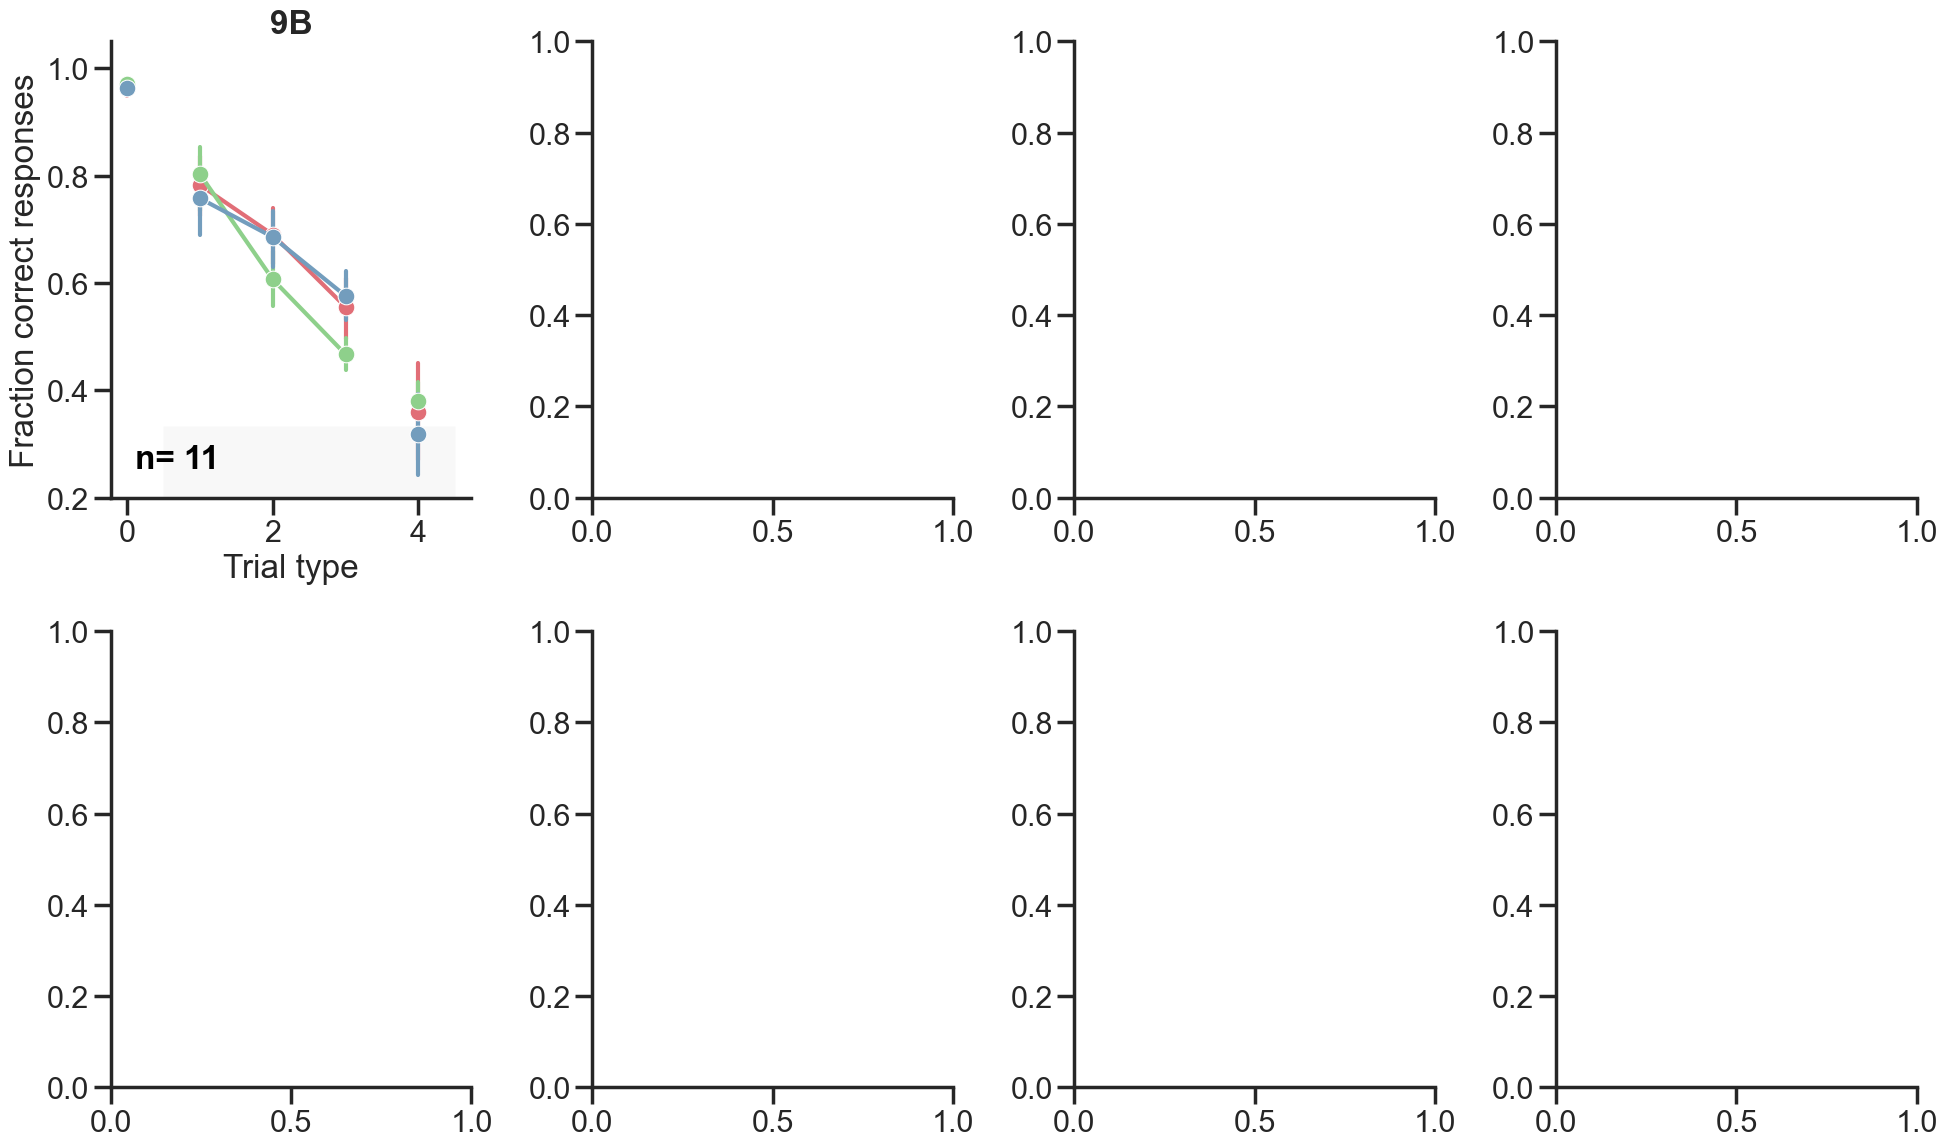

In [61]:
# REMOVE NON-WANTED SESSIONS
to_plot= df.loc[((df['valids']==1) & (df['valids2']==1) & (df['valids3']==1)  & (df['manipulation']==0))] # Remove weird & select minimum engagement 


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))
axes=axes.flatten()

for idx, batch in enumerate(to_plot.batch.unique()):
    subset= to_plot.loc[to_plot['batch']==batch]
    n_subjects= len(subset.subject.unique())
    xmax=subset['ttype_n'].unique()[-1]+0.5
    xmin=subset['ttype_n'].unique()[0]-0.5
    grouped = subset.groupby(['subject', 'ttype_n', 'x_n'])['correct_bool'].mean().reset_index()

    # PLOT
    vg=grouped[grouped['ttype_n']==0]
    sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_n', hue_order=stim_o, palette=stim_c, ax=axes[idx], data=vg, ci=95,  err_style="bars", marker='o', 
                  zorder=10)
    wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
    sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_n', hue_order=stim_o, palette=stim_c, ax=axes[idx], data=wm, ci=95,  err_style="bars", marker='o', 
                 zorder=10)
    sil = grouped[grouped['ttype_n']==4]
    sns.lineplot(x='ttype_n',  y='correct_bool',hue='x_n', hue_order=stim_o, palette=stim_c,  ax=axes[idx], data=sil, ci=95,  err_style="bars", marker='o', 
                 zorder=10)

    axes[idx].set_title(batch, fontweight='bold')
    axes[idx].get_legend().remove()
    axes[idx].set_xlabel('Trial type')
    axes[idx].set_ylabel('Fraction correct responses')
    axes[idx].set_ylim(0.2, 1.05)
    axes[idx].text(0.3, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
            transform=axes[idx].transAxes, color='black', fontweight='bold')
    # axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
    axes[idx].fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

## By subject

[3. 1. 0. 2. 4.]
Subject: A83 - n trials: 3170
Fraction correct: 0.95595690747782


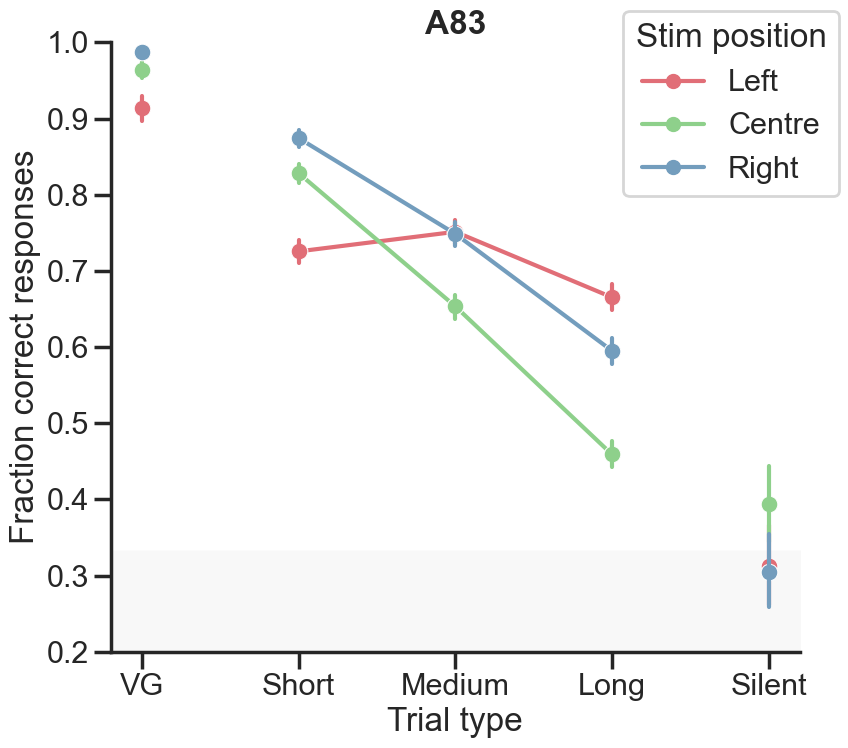

Subject: A84 - n trials: 813
Fraction correct: 0.9801980198019802


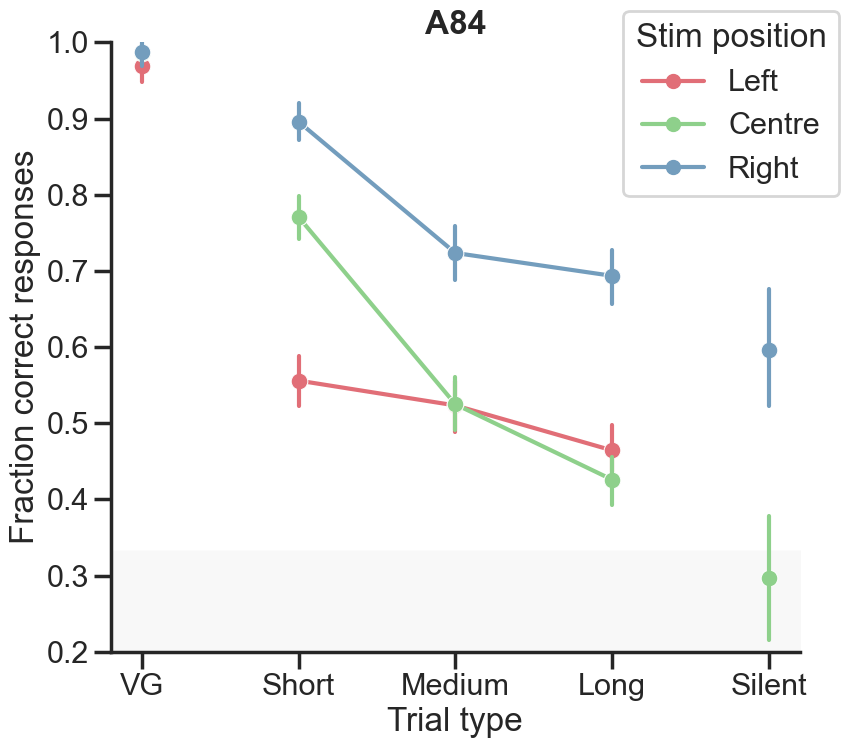

Subject: A86 - n trials: 6991
Fraction correct: 0.9762109486959014


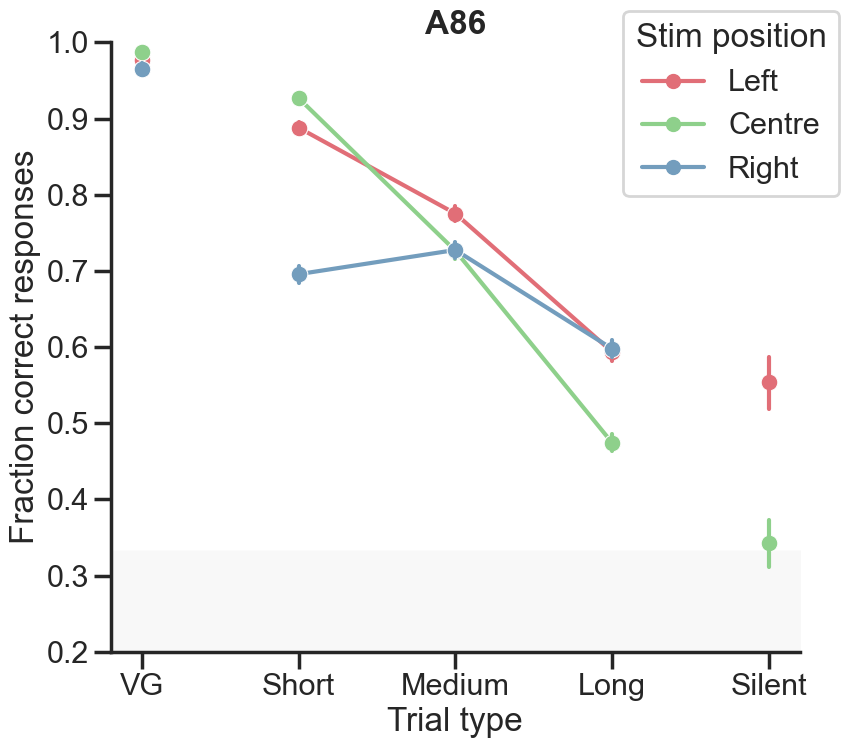

Subject: A87 - n trials: 6422
Fraction correct: 0.9497267759562842


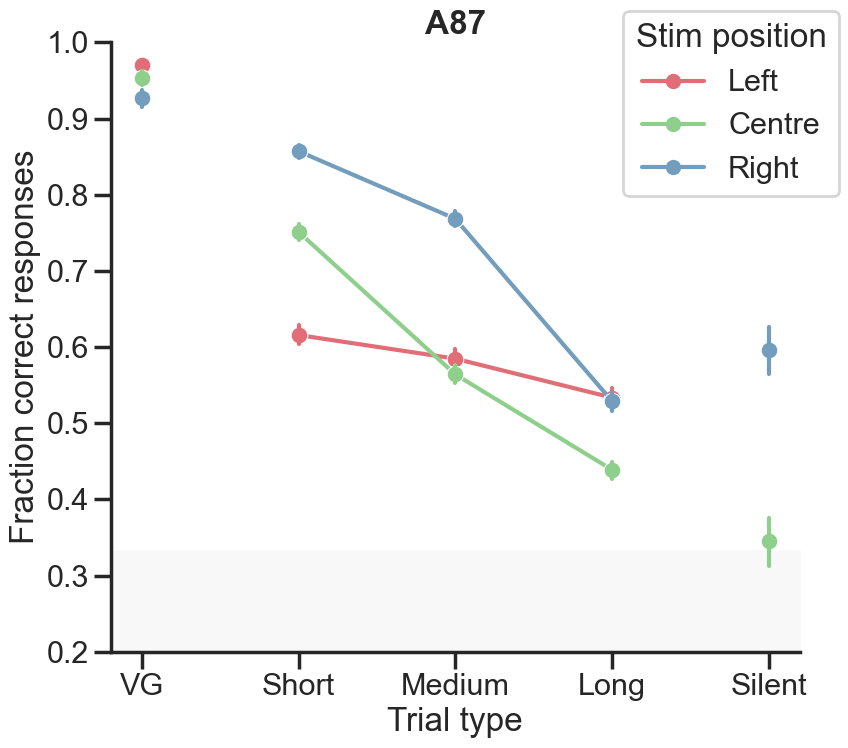

Subject: A88 - n trials: 3979
Fraction correct: 0.9841349785948124


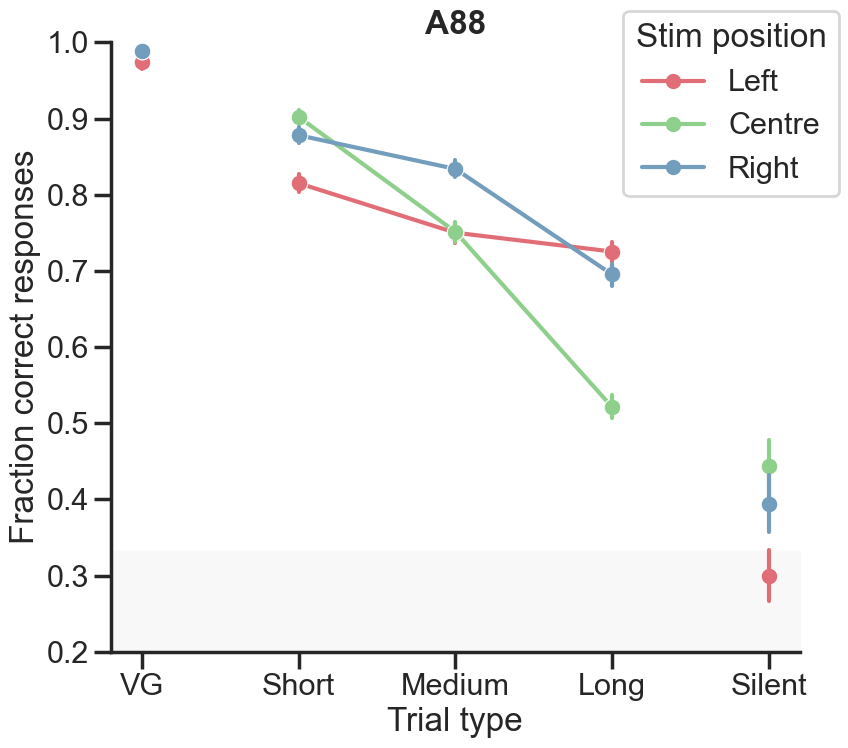

Subject: A89 - n trials: 3889
Fraction correct: 0.9622055397359565


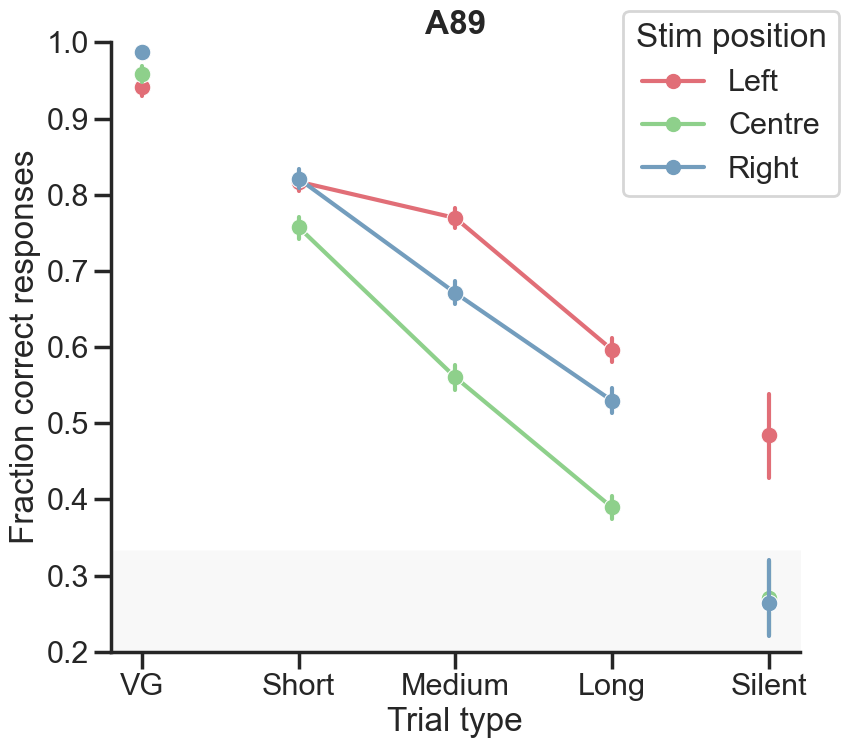

Subject: A90 - n trials: 397
Fraction correct: 0.947103274559194


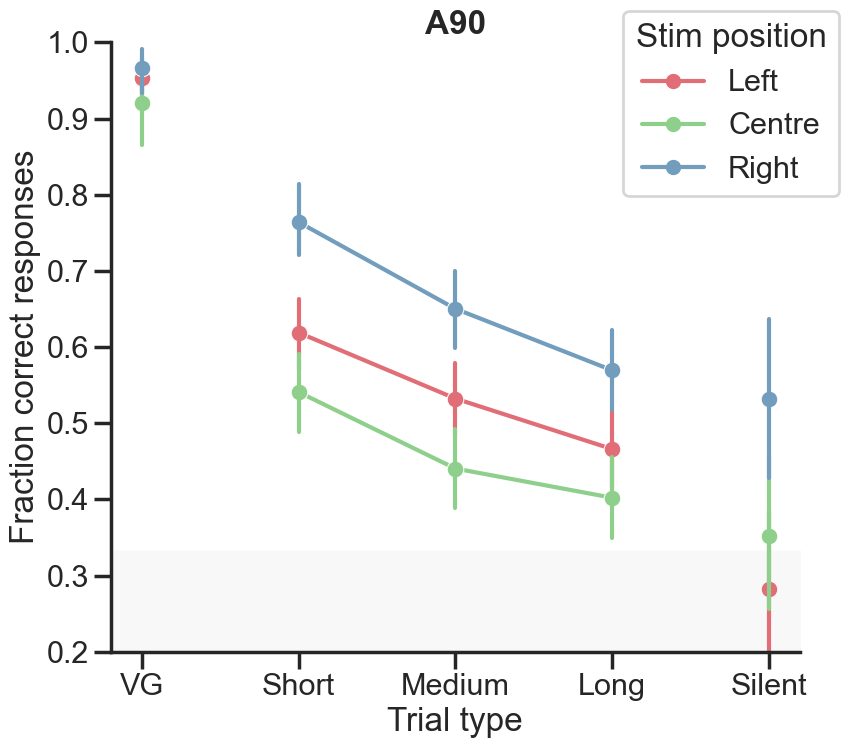

Subject: A92 - n trials: 7781
Fraction correct: 0.9590703679793415


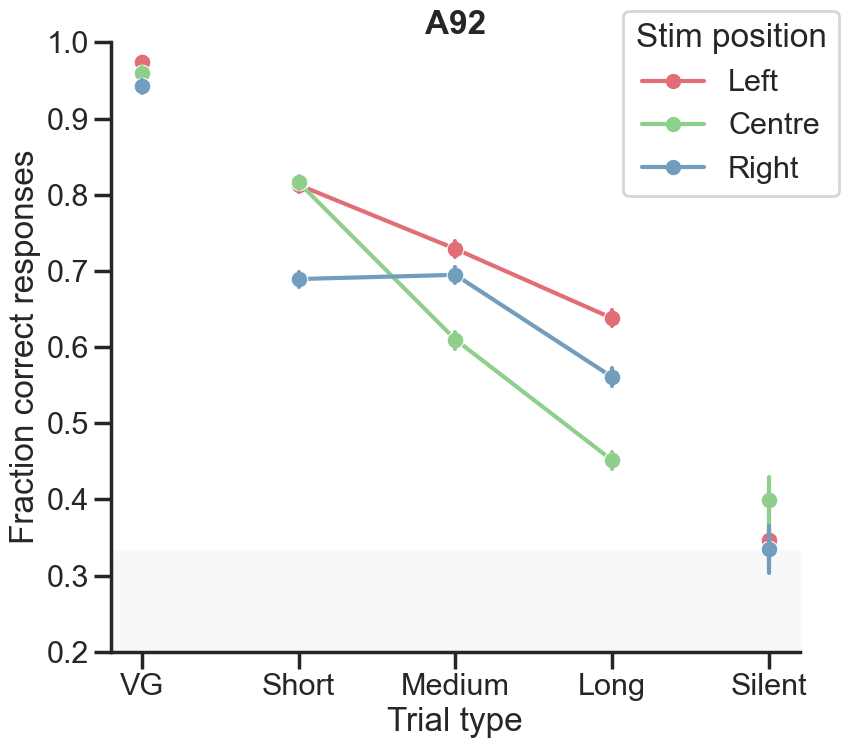

Subject: A93 - n trials: 2012
Fraction correct: 0.9735924265072247


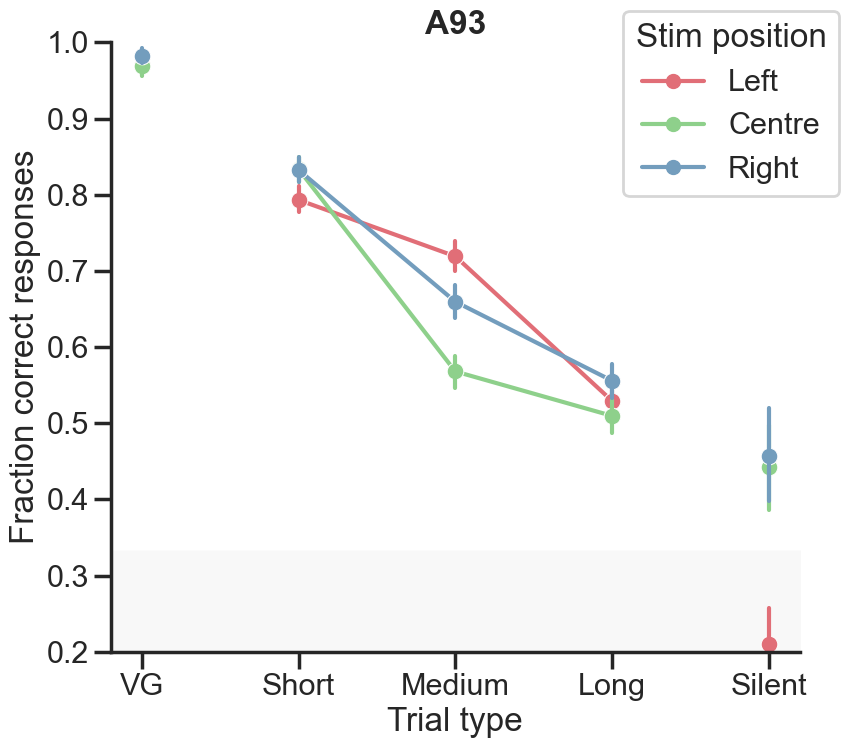

Subject: A95 - n trials: 1369
Fraction correct: 0.9714912280701754


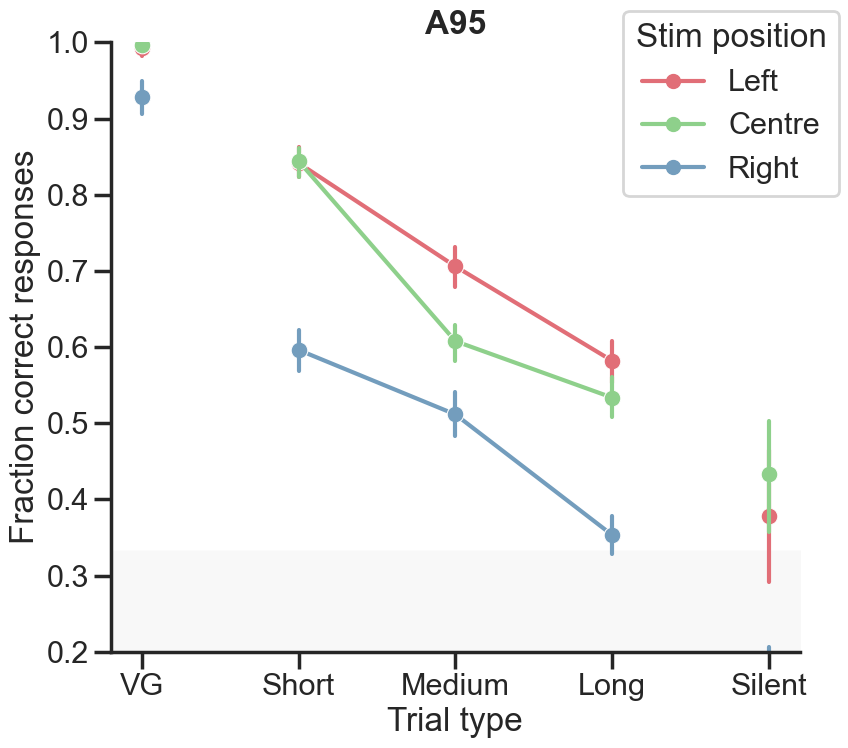

Subject: A96 - n trials: 2646
Fraction correct: 0.9658444022770398


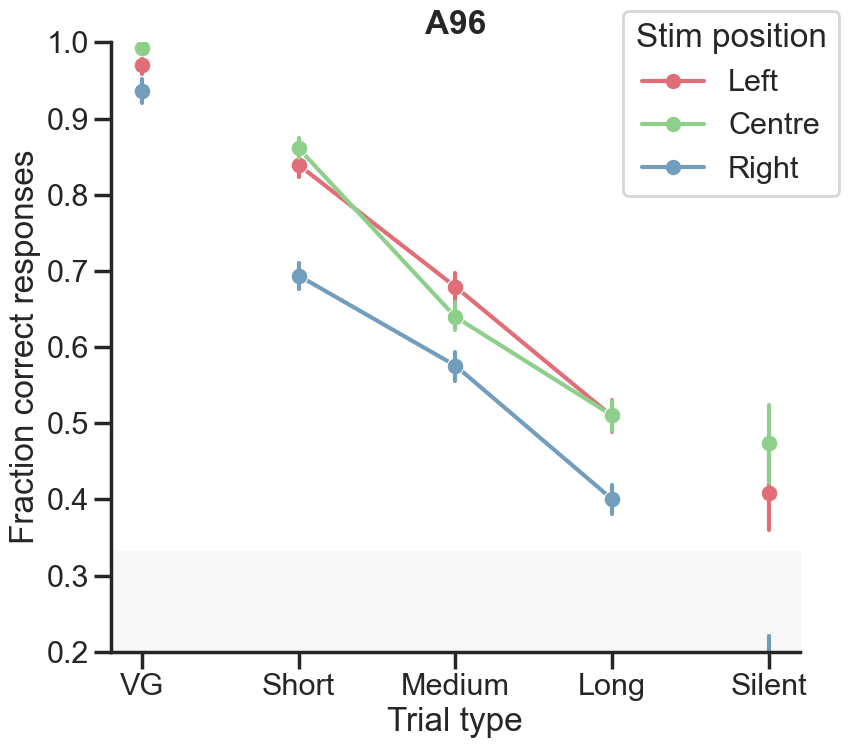

In [94]:
stim_c=[(0.8816172286897883, 0.4314264196004728, 0.4648957165548593), 
             (0.5573241061130334, 0.8164244521337947, 0.546958861976163),
            (0.4500284515703821, 0.6166767969381974, 0.7400141466793091)]
xlabels = ['VG','Short', 'Medium', 'Long', 'Silent']
xticks = [0, 1, 2, 3,4]
to_plot = df.loc[((df['batch']=='9B') | (df['batch']=='7B'))] # take only t-maze batches with all ttypes
to_plot = to_plot.loc[to_plot['trial']>10]
print(to_plot['ttype_n'].unique())
for subject in to_plot.subject.unique():
 
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9,8))
    subset = to_plot.loc[to_plot['subject']==subject]
    axes.set_title(str(subject), fontweight='bold')
    
    vg=subset[subset['ttype_n']==0]
    sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_c', hue_order=['R', 'C', 'L'], palette=stim_c, err_style='bars',
                 ax=axes, data=vg, marker='o', ci=95)
    print('Subject: ' + str(subject) + ' - n trials: ' + str(vg.shape[0]))
    print('Fraction correct: ' + str(vg['correct_bool'].mean()))
    wm=subset[((subset['ttype_n']>0) & (subset['ttype_n']<4))]    
    sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_c',hue_order=['R', 'C', 'L'], palette=stim_c, err_style='bars',
                 ax=axes, data=wm, marker='o', ci=95)

    sil=subset[subset['ttype_n']==4]
    sns.lineplot(x='ttype_n',  y='correct_bool', hue='x_c', hue_order=['R', 'C', 'L'], palette=stim_c,err_style='bars',
                 ax=axes, data=sil, marker='o', ci=95)
    

    axes.set_xticks(xticks)
    axes.set_xticklabels(xlabels)
    axes.set_xlabel('Trial type')
    axes.set_ylabel('Fraction correct responses')
    axes.set_ylim(0.2, 1)
    axes.set_xlim(-0.2, 4.2)
    lines = [Line2D([0], [0], color=c, marker='o', markersize=10, markeredgecolor=c, markerfacecolor=c) for c in stim_c]
    axes.legend(lines, ['Left', 'Centre', 'Right'], title="Stim position", loc='center', bbox_to_anchor=(0.9, 0.9))  

    # axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
    axes.fill_between(np.arange(-0.2, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

    sns.despine()
    plt.tight_layout()
    plt.show()
    # plt.savefig(str(data_folder) + 'acc_delay_stimx_' + str(subject) +'.svg', transparent=False)
    # plt.savefig(str(data_folder) + 'acc_delay_stimx_' + str(subject) +'.png', transparent=False)


# FORCED BIAS (MANIPULATING STIMULUS SIDE PROBABILITIES)

## Correct responses accumulated running window

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='9B') & (df['task']=='StageTraining_9B_V3') & (df['stage']>=2))] # SELECT 9B


In [ ]:

def sum_cumulative(data, runningwindow):
    # Calculate the rolling sum with the specified window size
    data['accumulation'] = data['ACC'].rolling(window=window_size).sum()
    
    

# Set running window size
runningwindow = 300

# Add columns of interest
to_plot['acc_l'] = np.where((to_plot['x_n'] == -1) & (to_plot['trial_result'] == 'correct_first'), 1, 0)
to_plot['acc_c'] = np.where((to_plot['x_n'] ==  0) & (to_plot['trial_result'] == 'correct_first'), 1, 0)
to_plot['acc_r'] = np.where((to_plot['x_n'] ==  1) & (to_plot['trial_result'] == 'correct_first'), 1, 0)

# Nan the misses
to_plot.loc[to_plot.trial_result == 'miss', ['acc_l', 'acc_c', 'acc_r']] = np.nan
# Filter out 'miss' trials as they should not contribute to the rolling sum
to_plot = to_plot.loc[to_plot['trial_result'] != 'miss']

# Initialize an empty DataFrame for results
results_list = []

# Compute cumulative sum within running window for each subject and each condition
for subject in to_plot.subject.unique():
    for stim in stim_o:
        subset = to_plot.loc[(to_plot['subject'] == subject) & (to_plot['x_n'] == stim)].copy()
        if stim == -1:
            subset['acc_l_acc'] = subset['acc_l'].rolling(window=runningwindow).sum()
        elif stim == 0:
            subset['acc_c_acc'] = subset['acc_c'].rolling(window=runningwindow).sum()
        elif stim == 1:
            subset['acc_r_acc'] = subset['acc_r'].rolling(window=runningwindow).sum()
        results_list.append(subset)

results_df = pd.concat(results_list)


In [ ]:
print(results_df['acc_l_acc'].max())

In [ ]:
# results_df = results_df.sort_values(by=['subject', 'session', 'trial']).reset_index(drop=True)
results_df[['session','trial','trial_result', 'x_n', 'acc_l','acc_l_acc',  'acc_c',  'acc_c_acc', 'acc_r', 'acc_r_acc']].tail(50)

In [ ]:
fig, axes =  plt.subplots(nrows=1, ncols=3, figsize=(20, 7), sharey=True, sharex=True)

sns.histplot(x=results_df.acc_l_acc, ax=axes[0], color=stim_c[0], bins=150)
axes[0].axvline(results_df.acc_l_acc.median(), color='silver', linestyle=':')
sns.histplot(x=results_df.acc_c_acc, ax=axes[1], color=stim_c[1], bins=150)
sns.histplot(x=results_df.acc_r_acc, ax=axes[2], color=stim_c[2], bins=150)
sns.despine()

In [ ]:
palette=['lightblue', 'cornflowerblue', 'navy']

# Create classification column
def classify(x, q1, q3):
    if x < q1:
        return 'low_q'
    elif x > q3:
        return 'high_q'
    else:
        return 'median_q'
colors = {'low_q': 'blue', 'median_q': 'green', 'high_q': 'red'}

fig, axes =  plt.subplots(nrows=1, ncols=3, figsize=(20, 7), sharey=True, sharex=True)

for idx, side in  enumerate(['acc_l_acc', 'acc_c_acc', 'acc_r_acc']):    
    # Calculate Q1 and Q3
    Q1 = results_df[side].quantile(0.25)
    Q3 = results_df[side].quantile(0.75)
    name= side+'class'
    results_df[name] = results_df[side].apply(lambda x: classify(x, Q1, Q3))
    axes[idx].set_title('Choice: '+str(stim_f[idx]), fontweight='bold')
    sns.histplot(x=results_df[side], ax=axes[idx], hue=results_df[name], 
                 hue_order=['low_q', 'median_q', 'high_q'], palette=palette, bins=150)

    # Add vertical lines for Q1 and Q3
    axes[idx].axvline(Q1, color='black', linestyle=':', linewidth=3)
    axes[idx].axvline(Q3, color='black', linestyle=':', linewidth=3)
    axes[idx].axvline(results_df[side].median(),  color='black', linestyle=':',  linewidth=3)
    axes[idx].set_xlim(0, runningwindow)

sns.despine()

In [ ]:
    
xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

q_class=['acc_l_accclass', 'acc_c_accclass', 'acc_r_accclass']
palette=['lightblue', 'cornflowerblue', 'navy']

fig, axes =  plt.subplots(nrows=1, ncols=3, figsize=(20, 6), sharey=True, sharex=True)

for idx, side in  enumerate(['acc_l', 'acc_c', 'acc_r']):  
    sns.lineplot(x=results_df['ttype_n'], y=results_df[side], hue= results_df[q_class[idx]],
                 hue_order=['low_q', 'median_q', 'high_q'], palette=palette, ax=axes[idx])
        
    axes[idx].set_xticks(ttypes_o)
    axes[idx].set_xticklabels(ttypes_f)
# # axes.legend(title='Trials accumulated', loc='center', bbox_to_anchor=(1, 0.8),  prop={'size': 10}, fontsize=10)
    axes[idx].set_xlabel('Trial type')
    axes[idx].set_ylabel('Fraction correct responses')
    axes[idx].hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
    axes[idx].fill_between(np.arange(xmin, xmax+1), chance, 0, facecolor=lines_c, alpha=0.1)
sns.despine()

    
    

incorrect

In [ ]:
def compute_rolling_sum(data, window):
    """
    Computes a rolling sum with a length of window samples.
    Includes NaNs at the beginning until the window is full of values.
    """
    return data.rolling(window=window, min_periods=1).sum()


runningwindow=300

# add columns of interest
to_plot['acc_l'] =  np.where((to_plot['x_n'] == -1) & (to_plot['trial_result'] == 'correct_first'), 1, 0)
to_plot['acc_c'] =  np.where((to_plot['x_n'] ==  0) & (to_plot['trial_result'] == 'correct_first'), 1, 0)
to_plot['acc_r'] =  np.where((to_plot['x_n'] ==  1) & (to_plot['trial_result'] == 'correct_first'), 1, 0)

#nan the misses
to_plot.loc[to_plot.trial_result == 'miss', ['acc_l', 'acc_c', 'acc_r']] = np.nan


# Initialize an empty DataFrame for results
results_df = pd.DataFrame()

for subject in to_plot.subject.unique():
    subject_data = to_plot[to_plot.subject == subject].copy()
    
    for col in ['acc_l', 'acc_c', 'acc_r']:
        new_col_name = f"{col}_acc"
        subject_data[new_col_name] = compute_rolling_sum(subject_data[col], runningwindow)
    
    results_df = pd.concat([results_df, subject_data], ignore_index=True)

In [ ]:
print(results_df['acc_l_acc'].max())

In [ ]:
fig, axes =  plt.subplots(nrows=1, ncols=3, figsize=(20, 7), sharey=True, sharex=True)

sns.histplot(x=results_df.acc_l_acc, ax=axes[0], color=stim_c[0], bins=150)
sns.histplot(x=results_df.acc_c_acc, ax=axes[1], color=stim_c[1], bins=150)
sns.histplot(x=results_df.acc_r_acc, ax=axes[2], color=stim_c[2], bins=150)
# axes[0].hist(results_df.acc_l_acc, color=stim_c[0], bins=150, alpha=0.7) 
# axes[1].hist(results_df.acc_c_acc, color=stim_c[1], bins=150, alpha=0.7) 
# axes[2].hist(results_df.acc_r_acc, color=stim_c[2], bins=150, alpha=0.7) 
sns.despine()

## Bias change over time


In [ ]:
# Calculate the previous bias side column

# Initialize empty lists to accumulate data
subject_list = []
session_list = []
bias_side_list = []
prev_bias_side_list = []


for subject in to_plot.subject.unique():
    
    subs=to_plot.loc[to_plot['subject']==subject]
  
    for idx, session in enumerate(subs.session.unique()):          
        bias_side=subs.loc[subs['session']==session]['bias_side'].max()
        
        if idx==0: # fist block of nans
            last_bias_block=np.nan
            last_bias_side = bias_side

        if bias_side != last_bias_side:
            last_bias_block = last_bias_side
        
        # Append data to lists
        subject_list.append(subject)
        session_list.append(session)
        bias_side_list.append(bias_side)
        prev_bias_side_list.append(last_bias_block)
        
        last_bias_side = bias_side
        
# Create a dictionary from lists
bias_sides_dict = {
    'subject': subject_list,
    'session': session_list,
    'bias_side': bias_side_list,
    'prev_bias_side': prev_bias_side_list
}

# Convert dictionary to DataFrame
bias_sides_df = pd.DataFrame(bias_sides_dict)   


# Merge df_prev into df_big based on 'subject' and 'session'
to_plot = pd.merge(to_plot,  bias_sides_df[['subject', 'session', 'prev_bias_side']], on=['subject', 'session'], how='left')

In [ ]:
# Include other columns of interest

# Bias dominant bool
to_plot['bias_dominant'] = np.where(to_plot['x_n'] + 1 == to_plot['bias_side'], 1, 0)
to_plot['bias_prev_dominant'] = np.where(to_plot['x_n'] + 1 == to_plot['prev_bias_side'], 1, 0)

# when does the dominant bias change?
to_plot['bias_change'] = to_plot['bias_side'].ne(to_plot['bias_side'].shift()).astype(int)

# Create a group identifier that increments every time bias_change is 1
to_plot['tirals_accum'] = to_plot['bias_change'].cumsum()

# Create the counter column that resets with each group
to_plot['bias_counter'] = to_plot.groupby('tirals_accum').cumcount() + 1


In [ ]:
fig, axes =  plt.subplots(nrows=1, ncols=1, figsize=(15, 5), sharey=True, sharex=True)
subject='A95'
sns.lineplot(x='session', y='bias_side',  data=to_plot.loc[to_plot['subject']==subject], color='black')
sns.lineplot(x='session', y='prev_bias_side',  data=to_plot.loc[to_plot['subject']==subject], color='teal')

sns.despine()

In [ ]:
bin_size = 75

# Bin teh data to plot
bins = np.arange(0, to_plot['bias_counter'].max() + bin_size, bin_size)
# Calculate the median values for each bin
bin_medians = [np.median(to_plot[(to_plot['bias_counter'] >= bins[i]) & (to_plot['bias_counter'] < bins[i+1])]['bias_counter']) for i in range(len(bins)-1)]
# Use pd.cut with labels as median values
to_plot['bias_counter_bin'] = pd.cut(to_plot['bias_counter'], bins=bins, labels=bin_medians, right=False)



fig, axes =  plt.subplots(nrows=1, ncols=1, figsize=(15, 7), sharey=True, sharex=True)

for idx, side in enumerate(stim_o):
    subset =  to_plot.loc[(to_plot['x_n']==side) & (to_plot['bias_side']==side+1)] # trials in which stimulus is in the dominant side
    grouped = subset.groupby(['subject', 'bias_counter_bin'])['accuracy'].mean().reset_index()
    sns.lineplot(x='bias_counter_bin',  y='accuracy',  err_style="bars" ,
             ax=axes, data=grouped, ci=68,  marker='o', color=stim_c[idx], label=stim_f[idx])

axes.set_xlabel('Trials accumulated')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.5, 1)
axes.set_xlim(-1, 1200)


sns.despine()
plt.tight_layout()
plt.savefig(str(data_folder) + 'dominant_bias_side.png', transparent=False)
plt.savefig(str(data_folder) + 'dominant_bias_side.svg', transparent=False)

In [ ]:
bin_size = 75

to_plot['bias_change'] = to_plot['bias_side'].ne(to_plot['bias_side'].shift()).astype(int)


# Create a group identifier that increments every time bias_change is 1
to_plot['tirals_accum'] = to_plot['bias_change'].cumsum()

# Create the counter column that resets with each group
to_plot['bias_counter'] = to_plot.groupby('tirals_accum').cumcount() + 1

# Bin teh data to plot
bins = np.arange(0, to_plot['bias_counter'].max() + bin_size, bin_size)
# Calculate the median values for each bin
bin_medians = [np.median(to_plot[(to_plot['bias_counter'] >= bins[i]) & (to_plot['bias_counter'] < bins[i+1])]['bias_counter']) for i in range(len(bins)-1)]
# Use pd.cut with labels as median values
to_plot['bias_counter_bin'] = pd.cut(to_plot['bias_counter'], bins=bins, labels=bin_medians, right=False)


fig, axes =  plt.subplots(nrows=1, ncols=1, figsize=(15, 7), sharey=True, sharex=True)
to_plot['bias_dominant'] = np.where(to_plot['x_n'] + 1 == to_plot['bias_side'], 1, 0)

grouped = to_plot.loc[to_plot['bias_dominant']==1]
grouped= grouped.groupby(['subject', 'ttype_n', 'bias_counter_bin'])['accuracy'].mean().reset_index()
                                      
sns.lineplot(x='bias_counter_bin',  y='accuracy', hue='ttype_n', hue_order=ttypes_o, err_style="bars" ,
             ax=axes, data=grouped, ci=68,  marker='o', palette=ttypes_c)

axes.set_xlabel('Trials accumulated')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1)
axes.axhline(0.33, color='silver', linestyle=':')
axes.axhline(1, color='silver', linestyle=':')
axes.set_xlim(-1, 1200)

# Customize legend labels
handles, labels = axes.get_legend_handles_labels()
axes.legend(handles, ['Visual', 'Short', 'Med', 'Long', 'NO'], title='trial type')


sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'dominant_bias_delay.png', transparent=False)
plt.savefig(str(data_folder) + 'dominant_bias_delay.svg', transparent=False)


In [ ]:
fig, axes =  plt.subplots(nrows=1, ncols=1, figsize=(20, 7), sharey=True, sharex=True)
grouped = to_plot.loc[to_plot['bias_dominant']==1]
grouped['counts']=1

sns.countplot(grouped, x="bias_counter_bin")
axes.axhline(3750, color='silver', linestyle=':')
plt.xticks(rotation=90)
sns.despine()
plt.savefig(str(data_folder) + 'trial_counts_bin.svg', transparent=False)


## Slope changes

### Current dominant probability

In [ ]:
xmax=ttypes_o[-1]-0.5
xmin=ttypes_o[0]-0.5

grouped = to_plot.loc[to_plot['bias_dominant']==1]
grouped= grouped.groupby(['subject', 'ttype_n', 'bias_counter_bin'])['accuracy'].mean().reset_index()
n_subjects= grouped.subject.nunique()      

grouped= grouped.loc[grouped['ttype_n']!=4] #remove silent trials

good_bins= [value for value in bin_medians if value <= 1235.0] #above this value nans
palette = sns.color_palette("rocket", len(good_bins))
cmap = ListedColormap(palette)

fig, axes =  plt.subplots(nrows=1, ncols=1, figsize=(9, 8), sharey=True, sharex=True)


dom_slopes_list = []
dom_intercept_list = []

for idx, bin_ in enumerate(good_bins): # LOOP THOUGH BIN COLUMNS TO EXTRACT THE SLOPE 
    x= grouped.loc[grouped['bias_counter_bin']==bin_]['ttype_n']
    y= grouped.loc[grouped['bias_counter_bin']==bin_]['accuracy']
    slope, intercept, r_value, p_value, std_err  = linregress(x, y)
    print(f"Trial bin: {bin_}, Slope: {slope}, Intercept: {intercept}")
    print('')
    
    ## Plot points
#     plt.scatter(x, y, color=palette[i], label=f'Bin {bin_}', alpha=0.6)
    ## Plot regression line
    plt.plot(x, slope * x + intercept, color=palette[idx], label=f'Bin {bin_}')
    
    dom_slopes_list.append(slope)
    dom_intercept_list.append(intercept)
    
axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
# axes.legend(title='Trials accumulated', loc='center', bbox_to_anchor=(1, 0.8),  prop={'size': 10}, fontsize=10)
axes.set_xlabel('Trial type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)


# Add colorbar
ticks= np.arange(0, max(good_bins)+bin_size, bin_size)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max(good_bins)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes)
cbar.set_label('Trials accumulated', rotation=270, labelpad=15)


sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'slope_dominant_prob.png', transparent=False)
plt.savefig(str(data_folder) + 'slope_dominant_prob.svg', transparent=False)


### Previous dominant probability

In [ ]:
xmax=ttypes_o[-1]-0.5
xmin=ttypes_o[0]-0.5


grouped = to_plot.loc[to_plot['bias_prev_dominant']==1]
grouped= grouped.groupby(['subject', 'ttype_n', 'bias_counter_bin'])['accuracy'].mean().reset_index()
           
grouped= grouped.loc[grouped['ttype_n']!=4] #remove silent trials

good_bins= [value for value in bin_medians if value <= 1235.0] #above this value nans
palette = sns.color_palette("rocket", len(good_bins))
cmap = ListedColormap(palette)


fig, axes =  plt.subplots(nrows=1, ncols=1, figsize=(9, 8), sharey=True, sharex=True)


pdom_slopes_list = []
pdom_intercept_list = []


for idx, bin_ in enumerate(good_bins): # LOOP THOUGH BIN COLUMNS TO EXTRACT THE SLOPE 
    x= grouped.loc[grouped['bias_counter_bin']==bin_]['ttype_n']
    y= grouped.loc[grouped['bias_counter_bin']==bin_]['accuracy']
    slope, intercept, r_value, p_value, std_err  = linregress(x, y)
    print(f"Trial bin: {bin_}, Slope: {slope}, Intercept: {intercept}")
    print('')
    
    plt.plot(x, slope * x + intercept, color=palette[idx], label=f'Bin {bin_}')
    
    pdom_slopes_list.append(slope)
    pdom_intercept_list.append(intercept)
    
axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.set_xlabel('Trial type')
axes.set_ylabel('Fraction correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)


# Add colorbar
ticks= np.arange(0, max(good_bins)+bin_size, bin_size)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max(good_bins)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes)
cbar.set_label('Trials accumulated', rotation=270, labelpad=15)

sns.despine()
plt.tight_layout()



plt.savefig(str(data_folder) + 'slope_prev_dominant_prob.png', transparent=False)
plt.savefig(str(data_folder) + 'slope_prev_dominant_prob.svg', transparent=False)


In [ ]:
# Create a dictionary from lists
slopes_dict = {
    'd_slope': dom_slopes_list,
    'd_intercept': dom_intercept_list,
    'pd_slope': pdom_slopes_list, 
    'pd_intercept': pdom_intercept_list,
    'trial_bin': good_bins,
}
# Convert dictionary to DataFrame
slopes_df = pd.DataFrame(slopes_dict)   



fig, axes =  plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=False, sharex=True)

#slopes
sns.lineplot(x='trial_bin',  y='d_slope',  ax=axes[0], data=slopes_df, 
             ci=68,  marker='o', color=palette[-2], label='Curr Dominant')
sns.lineplot(x='trial_bin',  y='pd_slope',  ax=axes[0], data=slopes_df, 
             ci=68,  marker='o', color=palette[2], label='Prev Dominant')

# intercepts
sns.lineplot(x='trial_bin',  y='d_intercept',  ax=axes[1], data=slopes_df, 
             ci=68,  marker='o', color=palette[-2], label='Curr Dominant')
sns.lineplot(x='trial_bin',  y='pd_intercept',  ax=axes[1], data=slopes_df, 
             ci=68,  marker='o', color=palette[2], label='Prev Dominant')

axes[0].set_ylabel('Slope')
axes[1].set_ylabel('Intercept')
axes[0].set_ylim(-0.2, 0)
axes[1].set_ylim(0.5, 1)

sns.despine()

plt.savefig(str(data_folder) + 'slope_intercept.png', transparent=False)
plt.savefig(str(data_folder) + 'slope_intercept.svg', transparent=False)

### BY genotype

In [ ]:
bin_size = 100

to_plot['bias_change'] = to_plot['bias_side'].ne(to_plot['bias_side'].shift()).astype(int)

# Create a group identifier that increments every time bias_change is 1
to_plot['tirals_accum'] = to_plot['bias_change'].cumsum()

# Create the counter column that resets with each group
to_plot['bias_counter'] = to_plot.groupby('tirals_accum').cumcount() + 1

# Bin teh data to plot
bins = np.arange(0, to_plot['bias_counter'].max() + bin_size, bin_size)
# Calculate the median values for each bin
bin_medians = [np.median(to_plot[(to_plot['bias_counter'] >= bins[i]) & (to_plot['bias_counter'] < bins[i+1])]['bias_counter']) for i in range(len(bins)-1)]
# Use pd.cut with labels as median values
to_plot['bias_counter_bin'] = pd.cut(to_plot['bias_counter'], bins=bins, labels=bin_medians, right=False)



In [ ]:
xmax=ttypes_o[-1]-0.5
xmin=ttypes_o[0]-0.5


grouped = to_plot.loc[to_plot['bias_dominant']==1]
grouped= grouped.groupby(['subject', 'ttype_n', 'bias_counter_bin'])['accuracy'].mean().reset_index()
grouped['genotype'] = 'WT'
ko_list=['A83', 'A84', 'A88', 'A89', 'A90', 'A92', 'A94']
grouped.loc[grouped['subject'].isin(ko_list), 'genotype'] = 'KO-GRIN1'


# grouped['genotype'] = grouped['subject'].apply(genotype)


n_subjects= grouped.subject.nunique()      

grouped= grouped.loc[grouped['ttype_n']!=4] #remove silent trials

good_bins= [value for value in bin_medians if value <= 1235.0] #above this value nans
palette = sns.color_palette("rocket", len(good_bins))
cmap = ListedColormap(palette)

fig, axes =  plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=True, sharex=True)

dom_slopes_list = []
dom_intercept_list = []
genotype_list = []
bins_list =[]

for idd, genotype in enumerate(['WT', 'KO-GRIN1']):
    print(genotype)
    print(grouped.loc[grouped['genotype']==genotype]['subject'].unique())

    for idx, bin_ in enumerate(good_bins): # LOOP THOUGH BIN COLUMNS TO EXTRACT THE SLOPE 
        x= grouped.loc[(grouped['bias_counter_bin']==bin_) & (grouped['genotype']==genotype)]['ttype_n']
        y= grouped.loc[(grouped['bias_counter_bin']==bin_) & (grouped['genotype']==genotype)]['accuracy']
        slope, intercept, r_value, p_value, std_err  = linregress(x, y)
        axes[idd].plot(x, slope * x + intercept, color=palette[idx], label=f'Bin {bin_}')
            
        dom_slopes_list.append(slope)
        dom_intercept_list.append(intercept)
        genotype_list.append(genotype)
        bins_list.append(bin_)

    axes[idd].set_title(genotype, fontweight='bold')
    axes[idd].set_xticks(ttypes_o)
    axes[idd].set_xticklabels(ttypes_f)
    axes[idd].set_xlabel('Trial type')
    axes[idd].set_ylabel('Fraction correct responses')
    axes[idd].set_ylim(0.2, 1.05)
    axes[idd].set_xlim(xmin, xmax)
    axes[idd].hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
    axes[idd].fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)
    
    if idd==0:
        axes[idd].text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
            transform=axes[idd].transAxes, color='black', fontweight='bold', fontsize = 20)
    else:
        # Add colorbar
        ticks= np.arange(0, max(good_bins)+bin_size, bin_size)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max(good_bins)))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=axes[idd])
        cbar.set_label('Trials accumulated', rotation=270, labelpad=15)
        

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'slope_dominant_prob_genotype.png', transparent=False)
# plt.savefig(str(data_folder) + 'slope_dominant_prob.svg', transparent=False)


In [ ]:
xmax=ttypes_o[-1-+0.5
xmin=ttypes_o[0]-0.5


grouped = to_plot.loc[to_plot['bias_prev_dominant']==1]
grouped= grouped.groupby(['subject', 'ttype_n', 'bias_counter_bin'])['accuracy'].mean().reset_index()
grouped['genotype'] = 'WT'
ko_list=['A83', 'A84', 'A88', 'A89', 'A90', 'A92', 'A94']
grouped.loc[grouped['subject'].isin(ko_list), 'genotype'] = 'KO-GRIN1'


# grouped['genotype'] = grouped['subject'].apply(genotype)


n_subjects= grouped.subject.nunique()      

grouped= grouped.loc[grouped['ttype_n']!=4] #remove silent trials

good_bins= [value for value in bin_medians if value <= 1235.0] #above this value nans
palette = sns.color_palette("rocket", len(good_bins))
cmap = ListedColormap(palette)


pdom_slopes_list = []
pdom_intercept_list = []

fig, axes =  plt.subplots(nrows=1, ncols=2, figsize=(18, 8), sharey=True, sharex=True)


for idd, genotype in enumerate(['WT', 'KO-GRIN1']):
    print(genotype)
    print(grouped.loc[grouped['genotype']==genotype]['subject'].unique())

    for idx, bin_ in enumerate(good_bins): # LOOP THOUGH BIN COLUMNS TO EXTRACT THE SLOPE 
        x= grouped.loc[(grouped['bias_counter_bin']==bin_) & (grouped['genotype']==genotype)]['ttype_n']
        y= grouped.loc[(grouped['bias_counter_bin']==bin_) & (grouped['genotype']==genotype)]['accuracy']
        slope, intercept, r_value, p_value, std_err  = linregress(x, y)
        axes[idd].plot(x, slope * x + intercept, color=palette[idx], label=f'Bin {bin_}')
        pdom_slopes_list.append(slope)
        pdom_intercept_list.append(intercept)

    axes[idd].set_title(genotype, fontweight='bold')
    axes[idd].set_xticks(ttypes_o)
    axes[idd].set_xticklabels(ttypes_f)
    axes[idd].set_xlabel('Trial type')
    axes[idd].set_ylabel('Fraction correct responses')
    axes[idd].set_ylim(0.2, 1.05)
    axes[idd].set_xlim(xmin, xmax)
    axes[idd].hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
    axes[idd].fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)
    
    if idd==0:
        axes[idd].text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
            transform=axes[idd].transAxes, color='black', fontweight='bold', fontsize = 20)
    else:
        # Add colorbar
        ticks= np.arange(0, max(good_bins)+bin_size, bin_size)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max(good_bins)))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=axes[idd])
        cbar.set_label('Trials accumulated', rotation=270, labelpad=15)
        

sns.despine()
plt.tight_layout()

plt.savefig(str(data_folder) + 'slope_prev_dominant_prob_genotype.png', transparent=False)


In [ ]:
slopes_df

In [ ]:
slopes_df

In [ ]:
# Create a dictionary from lists
slopes_dict = {
    'd_slope': dom_slopes_list,
    'd_intercept': dom_intercept_list,
    'pd_slope': pdom_slopes_list, 
    'pd_intercept': pdom_intercept_list,
    'trial_bin': bins_list,
    'genotype':genotype_list
}
# Convert dictionary to DataFrame
slopes_df = pd.DataFrame(slopes_dict)   



fig, axes =  plt.subplots(nrows=2, ncols=2, figsize=(18, 16), sharey=False, sharex=True)
axes=axes.flatten()
#slopes
sns.lineplot(x='trial_bin',  y='d_slope',  ax=axes[0], data=slopes_df, hue='genotype',
             ci=68,  marker='o', hue_order=['WT', 'KO-GRIN1'], palette= ['orange', 'purple'])
sns.lineplot(x='trial_bin',  y='pd_slope',  ax=axes[2], data=slopes_df, hue= 'genotype',
             ci=68,  marker='o',  hue_order=['WT', 'KO-GRIN1'], palette= ['orange', 'purple'])

# intercepts
sns.lineplot(x='trial_bin',  y='d_intercept',  ax=axes[1], data=slopes_df, hue='genotype',
             ci=68,  marker='o', hue_order=['WT', 'KO-GRIN1'], palette= ['orange', 'purple'])
sns.lineplot(x='trial_bin',  y='pd_intercept',  ax=axes[3], data=slopes_df, hue='genotype',
             ci=68,  marker='o', hue_order=['WT', 'KO-GRIN1'], palette= ['orange', 'purple'])

axes[0].set_title('Current dominant', fontweight='bold')
axes[1].set_title('Current dominant', fontweight='bold')
axes[2].set_title('Previous dominant')
axes[3].set_title('Previous dominant')
axes[0].set_ylabel('Slope')
axes[1].set_ylabel('Intercept')
for i in [1, 2, 3]:
    axes[i].get_legend().remove()
axes[0].set_ylim(-0.2, 0)
axes[1].set_ylim(0.5, 1)
axes[2].set_ylim(-0.2, 0)
axes[3].set_ylim(0.5, 1)
sns.despine()

plt.savefig(str(data_folder) + 'slope_intercept-genotype.png', transparent=False)
# plt.savefig(str(data_folder) + 'slope_intercept.svg', transparent=False)

# LATENCIES

In [ ]:
# select similar setups
to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='8B') | (df['batch']=='9B') |
                      (df['batch']=='10B'))]

# # remove extreme long trials
# max_latency= 60
# to_plot= to_plot.loc[((to_plot['trial_length']<max_latency) & (to_plot['resp_latency']<max_latency))]


## PH2-Touch histograms

In [ ]:
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B') | (df['batch']=='9B') | (df['batch']=='10B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['silent']==0) & (to_plot['ttype_c']!='VG') & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
# ##select only the subjects that have all the ttypes
# subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
# to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]


to_plot['ph2_touch_lat'] = to_plot['response_time_first'] - to_plot['STATE_Fixation2_START']


In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))
to_plot['ph2_touch_lat'] = to_plot['response_time_first'] - to_plot['STATE_Fixation2_START']

# sns.histplot(data=to_plot, x='ph2_touch_lat', hue='ttype_c', ax=axes, element='bars', alpha=0.6, element='step')
axes.hist(to_plot.ph2_touch_lat, bins=1000, alpha=0.7, color='silver', edgecolor='gray')
axes.set_xlim(0, 10)
axes.set_xlabel('')
sns.despine()

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
palette=['#C698CB', '#9C69A3',  '#5E2A7E']
# ttypes_c=['black', 'dimgray', 'gray', 'darkgray', 'lightgray']


subset= to_plot.loc[to_plot['delay_abs']<10]
# sns.histplot(data=subset, x='delay_abs', hue='ttype_c', ax=axes, element='bars', alpha=0.6)
sns.histplot(data=subset, x='delay_abs', hue='ttype_c', hue_order=['DL', 'DM', 'DS'] ,ax=axes, element='step', alpha=0.001, linewidth=3, bins=300, 
             palette=palette)


# for idx, ttype in enumerate(to_plot.ttype_c.unique()):
#     subset= to_plot.loc[((to_plot['ttype_c']==ttype) & (to_plot['delay_abs']<10))]
#     axes.hist(subset.delay_abs, bins=1000, alpha=0.7, color= palette[idx]) # edgecolor='gray'
#     axes.set_xlim(0, 7)


sns.despine()
plt.tight_layout()
axes.set_xlim(0,5)
axes.set_xlabel('Delay time (sec)')
axes.get_legend().remove()

plt.savefig(str(data_folder) + 'delay_abs_hist_ttype_longerBIN.png', transparent=False)


## Trial Response and Lick

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(30, 7))
axes= axes.flatten()

# TRIAL PLOT
sns.histplot(to_plot.trial_length, ax=axes[0], color='purple', element='step')
axes[0].axvline(df.trial_length.median(), color='gray', linestyle=':')
axes[0].set_title('Trial latency', fontweight='bold')

# CORRIDOR PLOT
sns.histplot(to_plot.resp_latency, ax=axes[1], color='orange',element='step')
axes[1].axvline(df.resp_latency.median(), color='gray', linestyle=':')
axes[1].set_title('Response latency', fontweight='bold')

# RESPONSE PLOT
sns.histplot(to_plot.resp_latency, ax=axes[1], color='orange',element='step')
axes[1].axvline(df.resp_latency.median(), color='gray', linestyle=':')
axes[1].set_title('Response latency', fontweight='bold')

# LICK PLOT
sns.histplot(to_plot.lick_latency, ax=axes[2], color='cornflowerblue', element='step')
axes[2].axvline(df.lick_latency.median(), color='gray', linestyle=':')
axes[2].set_title('Lick', fontweight='bold')

sns.despine()

# plt.savefig(str(data_folder) + 'global_latencies.svg', transparent=False)
# plt.savefig(str(data_folder) + 'global_latencies.png', transparent=False)

## Response latency

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
to_plot =  to_plot.loc[((to_plot['trial_result']!='miss') & (to_plot['trial']>12) & (to_plot['resp_latency'] < 30))]

# CORRIDOR PLOT
sns.histplot(data=to_plot, x="resp_latency", hue="trial_result", hue_order=tresult_o,
             ax=axes,element='step', palette=tresult_c)

for idx, res in enumerate(tresult_o):
    sub=to_plot.loc[to_plot['trial_result']==res]['resp_latency'].median()
    axes.axvline(sub, color=tresult_c[idx], linestyle=':')

axes.set_title('Response latency', fontweight='bold')
axes.set_xlim(0, 6)

sns.despine()

plt.savefig(str(data_folder) + 'resp_latencies_outcome.png', transparent=False)


In [ ]:
# REMOVE NON-WANTED SESSIONS

to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='8B') | (df['batch']=='9B'))]

# to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
columns=['subject', 'next_trial_result']
grouped = to_plot.groupby(['subject', 'trial_result'])['resp_latency'].median().reset_index()
n_subjects= len(grouped.subject.unique())

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# Create the plot
boxplot = sns.boxplot(x='trial_result', y='resp_latency', data=grouped, fliersize=0,  order=tresult_o,  palette=tresult_c, 
                  boxprops=dict(alpha=0.3),    linewidth=3,  width=0.5,    linecolor='white')
# Add lines connecting paired observations
grouped['x_scatter'] = grouped['trial_result'].replace(tresult_o, [0, 1])
grouped['x2'] = grouped['x_scatter'] + np.random.normal(loc=0, scale=0.05, size=len(grouped))

for idx, s in enumerate(grouped.subject.unique()):
    x = []
    y = []
    for idd, o in enumerate(tresult_o):
        xpoint = grouped.loc[(grouped['subject'] == s) & (grouped['trial_result'] == o), 'x2'].mean()
        ypoint = grouped.loc[(grouped['subject'] == s) & (grouped['trial_result'] == o), 'resp_latency'].mean()
        plt.plot(xpoint, ypoint, marker='o', color=tresult_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)

    
# # T-test paired
correct_first_data = grouped[grouped['trial_result'] == 'correct_first']['resp_latency']
punish_data = grouped[grouped['trial_result'] == 'punish']['resp_latency']

t_stat, p_val = ttest_rel(correct_first_data, punish_data)


# # Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['resp_latency'].max()+0.1, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)

axes.set_xlim(-0.5, 1.5)
plt.ylabel('Response latency')
# plt.ylim(0.25, 0.425)
plt.xlabel('Trial outcome')
plt.xticks([0, 1], ['Correct', 'Incorrect'])
sns.despine() 
plt.tight_layout()


# plt.savefig(str(data_folder) + 'rb_outcome_paired_next_best.svg', transparent=False)
plt.savefig(str(data_folder) + 'resp_lat_outcome_paired.png', transparent=False)

## Corridor latency (from fixation 1 last to end of fixation 3)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
# to_plot['engagement_latency'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Fixation1_START_last']


# CORRIDOR PLOT
sns.histplot(data=to_plot, x="corridor_latency", hue="trial_result", hue_order=tresult_o,
             ax=axes,element='step', palette=tresult_c)

for idx, res in enumerate(tresult_o):
    sub=to_plot.loc[to_plot['trial_result']==res]['corridor_latency'].median()
    axes.axvline(sub, color=tresult_c[idx], linestyle=':')

axes.set_title('Corridor latency', fontweight='bold')
axes.set_xlim(0, 4)

sns.despine()

plt.savefig(str(data_folder) + 'corr_latencies_outcome.png', transparent=False)

In [ ]:
# REMOVE NON-WANTED SESSIONS

to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='8B') | (df['batch']=='9B'))]

# to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
# CALUCLATE REPAETING BIAS
columns=['subject', 'next_trial_result']
grouped = to_plot.groupby(['subject', 'trial_result'])['corridor_latency'].median().reset_index()
n_subjects= len(grouped.subject.unique())

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# Create the plot
boxplot = sns.boxplot(x='trial_result', y='corridor_latency', data=grouped, fliersize=0,  order=tresult_o,  palette=tresult_c, 
                  boxprops=dict(alpha=0.3),    linewidth=3,  width=0.5,    linecolor='white')
# Add lines connecting paired observations
grouped['x_scatter'] = grouped['trial_result'].replace(tresult_o, [0, 1])
grouped['x2'] = grouped['x_scatter'] + np.random.normal(loc=0, scale=0.05, size=len(grouped))

for idx, s in enumerate(grouped.subject.unique()):
    x = []
    y = []
    for idd, o in enumerate(tresult_o):
        xpoint = grouped.loc[(grouped['subject'] == s) & (grouped['trial_result'] == o), 'x2'].mean()
        ypoint = grouped.loc[(grouped['subject'] == s) & (grouped['trial_result'] == o), 'corridor_latency'].mean()
        plt.plot(xpoint, ypoint, marker='o', color=tresult_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)

    
# # T-test paired
correct_first_data = grouped[grouped['trial_result'] == 'correct_first']['corridor_latency']
punish_data = grouped[grouped['trial_result'] == 'punish']['corridor_latency']

t_stat, p_val = ttest_rel(correct_first_data, punish_data)


# # Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['corridor_latency'].max()+0.1, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)

axes.set_xlim(-0.5, 1.5)
plt.ylabel('Corridor latency')
# plt.ylim(0.25, 0.425)
plt.xlabel('Trial outcome')
plt.xticks([0, 1], ['Correct', 'Incorrect'])
sns.despine() 
plt.tight_layout()


plt.savefig(str(data_folder) + 'corr_lat_outcome_paired.png', transparent=False)

## Latencies by trial type

In [ ]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 

# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n'])['resp_latency'].median().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='resp_latency', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='resp_latency', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='resp_latency', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='resp_latency', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Response latency')
axes.set_ylim(1, 4)
axes.set_xlim(xmin, xmax)
axes.text(0.15,0.9, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
axes.hlines(y=vg.resp_latency.mean(), xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_subj.svg', transparent=False)
plt.savefig(str(data_folder) + 'resp_lat_delay_subj.png', transparent=False)


In [ ]:

xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']!='3B') & (df['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['manipulation']==0))] # Remove weird & select minimum engagement 

# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n'])['corridor_latency'].median().reset_index()
grouped= grouped.loc[grouped['corridor_latency']>0] # Remove weird & select minimum engagement 

n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))
sns.stripplot(x='ttype_n',  y='corridor_latency', hue='ttype_n', hue_order=ttypes_o,
             ax=axes, data=grouped, marker='o', palette=ttypes_c, zorder=1)

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='corridor_latency', ax=axes, data=vg, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='corridor_latency', ax=axes, data=wm, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)
sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='corridor_latency', ax=axes, data=sil, ci=95,  err_style="bars", marker='o', 
             color='black', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Corridor latency')
axes.set_ylim(0.5, 2.3)
axes.set_xlim(xmin, xmax)
axes.text(0.15, 0.9, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)

axes.hlines(y=vg.corridor_latency.mean(), xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)

sns.despine()
plt.tight_layout()
plt.savefig(str(data_folder) + 'corr_lat_delay_subj.png', transparent=False)


In [ ]:

xmax=ttypes_o[-1]-0.5
xmin=ttypes_o[0]-0.5

stimd_c2 = ["#FFB74D", "#FB8C00", "#EF6C00"] #oranges
stimd_n2=[1, 2, 3, 4]
stimd_f2=[1, 2, 3, 4]

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))] # Best batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1)
                      & (to_plot['manipulation']==0))] # remove manipulations & misses & weird trialstrials
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

to_plot = to_plot.loc[(to_plot['ttype_n']==1)]


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

grouped = to_plot.groupby(['subject','stimd_n'])['resp_latency'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# grouped['stimd_n'] = grouped['stimd_n'].replace([1, 2, 3],[0,1,2]) #renamed
sns.stripplot(x='stimd_n',  y='resp_latency', hue='stimd_n', hue_order=stimd_n2,
             ax=axes, data=grouped, marker='o', palette=stimd_c2, zorder=1, size=5)
grouped['stimd_n'] = grouped['stimd_n'].replace([1, 2, 3],[0,1,2]) #renamed

sns.lineplot(x='stimd_n',  y='resp_latency',   err_style="bars" ,
             ax=axes, data=grouped, ci=68,  marker='o', color='black')



# axes.set_xticks(ttypes_o)
axes.set_xticklabels(['Short', 'Med', 'Long'])
axes.set_xlabel('Stimulus duration')
axes.set_ylabel('Response latency')
# axes.set_ylim(0.2, 1)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.85, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize=20)
lines = [Line2D([0], [0], color=c, marker='o', markerfacecolor=c) for c in stimd_c2]
axes.legend(lines, stimd_f, title='Stim duration')
axes.get_legend().remove()

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_stim.svg', transparent=False)
plt.savefig(str(data_folder) + 'corr_lat_stimdur.png', transparent=False)


## Corridor latencies

### Histograms after correct

In [ ]:
# select similar setups
to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='8B') | (df['batch']=='9B') |
                      (df['batch']=='10B'))]
to_plot =  to_plot.loc[((to_plot['prev_trial_result']=='correct_first') & (to_plot['valids']==1))]

to_plot['init_lat'] = to_plot['STATE_Fixation1_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor1_lat'] = to_plot['STATE_Fixation2_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor2_lat'] = to_plot['STATE_Fixation3_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor3_lat'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor_resp_lat'] = to_plot['STATE_Response_window_END'] - to_plot['STATE_Start_task_START']
to_plot['corridor_lick_lat'] = to_plot['STATE_Exit_START'] - to_plot['STATE_Start_task_START']


# max_length=40
# to_plot = to_plot.loc[((to_plot['corridor_resp_lat']<=max_length) & (to_plot['init_lat']<max_length))] # remove very distracted trials

    

In [ ]:
to_plot = to_plot.loc[to_plot['trial_result']=='correct_first']

In [ ]:
calc = to_plot['STATE_Fixation1_START']-

In [ ]:
to_plot['fix1'] = to_plot['STATE_Fixation2_START'] - to_plot['STATE_Fixation1_START']
to_plot['fix2'] = to_plot['STATE_Fixation3_START'] - to_plot['STATE_Fixation2_START']
to_plot['fix3'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Fixation3_START']
to_plot['fix4'] = to_plot['STATE_Response_window_END'] - to_plot['STATE_Response_window_START']


In [ ]:
to_plot.groupby('subject')['fix1'].median().mean()

In [ ]:
to_plot.groupby('subject')['corridor_resp_lat'].median().mean()

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15, 10))

color_list=['lightcoral','orange', 'greenyellow', 'mediumaquamarine', 
            'lightsteelblue', 'mediumblue', 'orchid']

sns.histplot(data=to_plot, x="init_lat",          ax=axes, element='step', color=color_list[0],  alpha=0.4)
sns.histplot(data=to_plot, x="corridor1_lat",     ax=axes, element='step', color=color_list[1],  alpha=0.4)
sns.histplot(data=to_plot, x="corridor2_lat",     ax=axes, element='step', color=color_list[2],  alpha=0.4)
sns.histplot(data=to_plot, x="corridor3_lat",     ax=axes, element='step', color=color_list[3],  alpha=0.4)
sns.histplot(data=to_plot, x="corridor_resp_lat", ax=axes, element='step', color=color_list[4],  alpha=0.4)


#medians
median_init_lat = to_plot['init_lat'].median()
median_corridor1_lat = to_plot['corridor1_lat'].median()
median_corridor2_lat = to_plot['corridor2_lat'].median()
median_corridor3_lat = to_plot['corridor3_lat'].median()
median_corridor_resp_lat = to_plot['corridor_resp_lat'].median()
    
    
medians= [median_init_lat, median_corridor1_lat, median_corridor2_lat, median_corridor3_lat,
          median_corridor_resp_lat]
for idx, line in enumerate(medians):
    axes.axvline(line, color=color_list[idx], linestyle=':')


axes.set_xlabel('Latency (sec)')
axes.set_xlim(0, 25)
sns.despine()

### Lineplots

In [ ]:
# select similar setups
to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='8B') | (df['batch']=='9B') |
                      (df['batch']=='10B'))]
to_plot =  to_plot.loc[((to_plot['prev_trial_result']=='correct_first') & (to_plot['valids']==1))]

to_plot['init_lat'] = to_plot['STATE_Fixation1_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor1_lat'] = to_plot['STATE_Fixation2_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor2_lat'] = to_plot['STATE_Fixation3_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor3_lat'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor_resp_lat'] = to_plot['STATE_Response_window_END'] - to_plot['STATE_Start_task_START']
to_plot['corridor_lick_lat'] = to_plot['STATE_Exit_START'] - to_plot['STATE_Start_task_START']


# grouped by subject
columns = ['init_lat', 'corridor1_lat', 'corridor2_lat', 'corridor3_lat', 'corridor_resp_lat']
labels = ['Ph1', 'Ph2', 'Ph3', 'Ph4', 'Touch']
medians = [to_plot.groupby(['subject'])[col].median().mean() for col in columns]
errors = [to_plot.groupby(['subject'])[col].median().std() for col in columns]
# medians = [to_plot[col].median() for col in columns] # without groupingby subject
# errors = [to_plot[col].std() for col in columns]     # without groupingby subject

# Create DataFrame
medians_df = pd.DataFrame({'position': labels, 'medians': medians, 'errors': errors})

# Plot with error bars
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))
sns.pointplot(data=medians_df, x='position', y='medians', ci='sd', ax=axes, color=tresult_c[0], capsize=0.2)
axes.errorbar(medians_df['position'], medians_df['medians'], yerr=medians_df['errors'], fmt='o', color=tresult_c[0], markersize=5)
axes.set_xlabel('Mouse position')
axes.set_ylabel('Median latency (sec)')
sns.despine()

plt.savefig(str(data_folder) + 'latencies_after_correct.png', facecolor='white', transparent=False)

In [ ]:
# select similar setups
to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='8B') | (df['batch']=='9B') |
                      (df['batch']=='10B'))]
to_plot =  to_plot.loc[((to_plot['prev_trial_result']=='punish') & (to_plot['valids']==1))]

to_plot['init_lat'] = to_plot['STATE_Fixation1_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor1_lat'] = to_plot['STATE_Fixation2_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor2_lat'] = to_plot['STATE_Fixation3_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor3_lat'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor_resp_lat'] = to_plot['STATE_Response_window_END'] - to_plot['STATE_Start_task_START']
to_plot['corridor_lick_lat'] = to_plot['STATE_Exit_START'] - to_plot['STATE_Start_task_START']


# max_length=40
# to_plot = to_plot.loc[((to_plot['corridor_resp_lat']<=max_length) & (to_plot['init_lat']<max_length))] # remove very distracted trials


# grouped by subject
columns = ['init_lat', 'corridor1_lat', 'corridor2_lat', 'corridor3_lat', 'corridor_resp_lat']
labels = ['Ph1', 'Ph2', 'Ph3', 'Ph4', 'Touch']
medians = [to_plot.groupby(['subject'])[col].median().mean() for col in columns]
errors = [to_plot.groupby(['subject'])[col].median().std() for col in columns]
percentile_25 = [to_plot.groupby(['subject'])[col].median().quantile(0.25) for col in columns]
percentile_75 = [to_plot.groupby(['subject'])[col].median().quantile(0.75) for col in columns]

# medians = [to_plot[col].median() for col in columns] # without groupingby subject
# errors = [to_plot[col].std() for col in columns]     # without groupingby subject

# Create DataFrame
medians_df = pd.DataFrame({'position': labels, 'medians': medians, 'errors': errors, 'p_25': percentile_25, 'p_75': percentile_25})

# Plot with error bars
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))
sns.pointplot(data=medians_df, x='position', y='medians', ci='sd', ax=axes, color=tresult_c[1], capsize=0.2)
axes.errorbar(medians_df['position'], medians_df['medians'], yerr=medians_df['errors'], fmt='o', color=tresult_c[1], markersize=5)

# axes.errorbar(medians_df['position'], medians_df['medians'],
#               yerr=[medians_df['medians']-medians_df['p_25'], medians_df['p_75']-medians_df['medians']],
#             fmt='o', color='red', markersize=5)

axes.set_xlabel('Mouse position')
axes.set_ylabel('Median latency (sec)')
sns.despine()

plt.savefig(str(data_folder) + 'latencies_after_punish.png', facecolor='white', transparent=False)

In [ ]:
# Assuming columns are defined
columns = ['init_lat', 'corridor1_lat', 'corridor2_lat', 'corridor3_lat', 'corridor_resp_lat', 'corridor_lick_lat']
labels = ['Ph1', 'Ph2', 'Ph3', 'Ph4', 'Touch']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))

# Function to process data
def process_data(df, result, label_shift=0):
    to_plot = df.loc[df['batch'].isin(['6B', '7B', '8B', '9B', '10B'])]
    to_plot = to_plot.loc[(to_plot['prev_trial_result'] == result) & (to_plot['valids'] == 1)]
    
    to_plot['init_lat'] = to_plot['STATE_Fixation1_START'] - to_plot['STATE_Start_task_START']
    to_plot['corridor1_lat'] = to_plot['STATE_Fixation2_START'] - to_plot['STATE_Start_task_START']
    to_plot['corridor2_lat'] = to_plot['STATE_Fixation3_START'] - to_plot['STATE_Start_task_START']
    to_plot['corridor3_lat'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Start_task_START']
    to_plot['corridor_resp_lat'] = to_plot['STATE_Response_window_END'] - to_plot['STATE_Start_task_START']
    to_plot['corridor_lick_lat'] = to_plot['STATE_Exit_START'] - to_plot['STATE_Start_task_START']
    
    medians = [to_plot.groupby('subject')[col].median().mean() for col in columns]
    errors = [to_plot.groupby('subject')[col].median().std() for col in columns]
    
    return pd.DataFrame({'position': [label + label_shift for label in range(len(columns))], 'medians': medians, 'errors': errors})

# Process data for 'correct_first' and 'punish'
medians_df_correct = process_data(df, 'correct_first')
medians_df_punish = process_data(df, 'punish')

# Combine the DataFrames
combined_df = pd.concat([medians_df_correct, medians_df_punish])

# Plot
sns.pointplot(data=medians_df_correct, x='position', y='medians', ci='sd', ax=axes, color=tresult_c[0], capsize=0.2)
axes.errorbar(medians_df_correct['position'], medians_df_correct['medians'], yerr=medians_df_correct['errors'], fmt='o', color=tresult_c[0], markersize=5)

sns.pointplot(data=medians_df_punish, x='position', y='medians', ci='sd', ax=axes, color=tresult_c[1], capsize=0.2)
axes.errorbar(medians_df_punish['position'], medians_df_punish['medians'], yerr=medians_df_punish['errors'], fmt='o', color=tresult_c[1], markersize=5)

# Set axis labels and title
axes.set_xticks(range(len(labels)))
axes.set_xticklabels(labels)
axes.set_xlabel('Mouse position')
axes.set_ylabel('Median latency (sec)')
sns.despine()

plt.savefig(str(data_folder) + 'latencies_outcome.svg', transparent=False)
plt.savefig(str(data_folder) + '_latencies_outcome.png', transparent=False)

### Boxplot

In [ ]:
stimd_c= ['yellowgreen', 'limegreen', 'green']


In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# REMOVE NON-WANTED SESSIONS
to_plot= df.loc[((df['batch']!='3B') & (df['batch']!='34B'))]
#to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))]
to_plot =  to_plot.loc[((to_plot['valids3']==1) & (to_plot['valids2']==1) & (to_plot['valids']==1) &
                         (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)&
                        (to_plot['manipulation']==0))] 

##select only the subjects that have all the ttypes
# subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
# to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]

grouped = to_plot.groupby(['subject', 'trial_result'])['lick_latency'].median().reset_index()



#boxplot
sns.boxplot(x='trial_result', y='lick_latency', order=tresult_o, data=grouped, color='white', 
            linewidth=0.5, showfliers=False, ax=axes)

for s, subject in enumerate(grouped.subject.unique()):
    y=[]
    x=[]
    for po, poutcome  in enumerate(tresult_o):
        ypoint = grouped.loc[((grouped['subject']==subject) & (grouped['trial_result']==poutcome)), 'lick_latency' ].mean()
        axes.plot(po, ypoint, marker='o', color=tresult_c[po], markersize=8)
        x.append(po)
        y.append(ypoint)
    axes.plot(x, y, '-', color='silver', linewidth=2, alpha=0.5)
axes.axhline(chance, color='gray', linestyle=':')

# T-test paired
correct =  grouped[grouped['trial_result'] == 'correct_first']['lick_latency']
punish =  grouped[grouped['trial_result'] == 'punish']['lick_latency']
t_stat, p_val = ttest_rel(correct, punish)

# Annotate the plot with the t-test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = 8, 0.5, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)


sns.despine() 
plt.tight_layout()

# plt.savefig(str(data_folder) + 'lick_latency_paired.svg', transparent=False)
# plt.savefig(str(data_folder) + 'lick_latency_paired.png', transparent=False)

## Correlation lick latency, RB


In [ ]:
to_plot= df.loc[((df['batch']!='3B') & (df['batch']!='34B'))]
to_plot =  to_plot.loc[((to_plot['valids3']==1) & (to_plot['valids2']==1) & (to_plot['valids']==1) &
                         (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1)&
                        (to_plot['manipulation']==0))] 

columns=['subject', 'prev_trial_result']
grouped = rep_bias_calc(to_plot, columns)

grouped_latency = to_plot.groupby(['subject', 'prev_trial_result'])['prev_lick_latency'].median().reset_index()

# Perform the merge
merged_df = pd.merge(grouped, grouped_latency, on=['subject', 'prev_trial_result'])

merged_punish = merged_df.loc[merged_df['prev_trial_result']=='punish']
merged_punish = merged_punish.dropna()

merged_correct = merged_df.loc[merged_df['prev_trial_result']=='correct_first']
merged_correct = merged_correct.dropna()


In [ ]:
# Compute the Pearson correlation coefficient
correlation, p_value = pearsonr(merged_punish['prev_lick_latency'], merged_punish['RB'])
print(f'Pearson correlation coefficient: {correlation}')
print(f'p-value: {p_value}')

# Create a scatter plot with regression line
sns.regplot(x='prev_lick_latency', y='RB', data=merged_punish, color='firebrick')
plt.axhline(chance, color='gray', linestyle=':')
sns.despine()

plt.ylabel('RB after punish')
plt.xlabel('Prev trial lick latency')
plt.title('Pearson correlation coef: '+str(round(correlation, 2))+ ' | Pval: '+str(round(p_value, 2)), fontsize=15)
plt.tight_layout()

plt.savefig(str(data_folder) + 'RB_PREV_lick_latency_punish.png', transparent=False)

In [ ]:

# Compute the Pearson correlation coefficient
correlation, p_value = pearsonr(merged_correct['prev_lick_latency'], merged_correct['RB'])
print(f'Pearson correlation coefficient: {correlation}')
print(f'p-value: {p_value}')

# Create a scatter plot with regression line
sns.regplot(x='prev_lick_latency', y='RB', data=merged_correct, color='green')
plt.axhline(chance, color='gray', linestyle=':')
sns.despine()

plt.ylabel('RB after correct')
plt.xlabel('Prev trial lick latency')
plt.title('Pearson correlation coef: '+str(round(correlation, 2))+ ' | Pval: '+str(round(p_value, 2)), fontsize=15)
plt.tight_layout()
# plt.savefig(str(data_folder) + 'RB_PREV_lick_latency_correct.png', transparent=False)

In [ ]:
grouped

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot= df.loc[((df['batch']=='6B') | (df['batch']=='7B') | (df['batch']=='9B'))]
to_plot =  to_plot.loc[((to_plot['valids3']==1) & (to_plot['valids']==1))] 
##select only the subjects that have all the ttypes
subject_ttype_counts = to_plot.groupby('subject')['ttype_n'].nunique()
subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 5].index.tolist()
to_plot = to_plot.loc[to_plot['subject'].isin(subjects_to_plot)]
grouped = to_plot.groupby(['subject', 'trial_result'])['lick_latency'].median().reset_index()


sns.boxplot(x='trial_result', y='lick_latency', order=tresult_o, data=grouped, color='white', 
            linewidth=0.5, showfliers=False, ax=axes)

for s, subject in enumerate(grouped.subject.unique()):
    y=[]
    x=[]
    for po, poutcome  in enumerate(tresult_o):
        ypoint = grouped.loc[((grouped['subject']==subject) & (grouped['trial_result']==poutcome)), 'lick_latency' ].mean()
        axes.plot(po, ypoint, marker='o', color=tresult_c[po], markersize=8)
        x.append(po)
        y.append(ypoint)
    axes.plot(x, y, '-', color='silver', linewidth=2, alpha=0.5)
axes.axhline(chance, color='gray', linestyle=':')

In [ ]:
# Compute the Pearson correlation coefficient
correlation = to_plot['lick_latency'].corr(to_plot['RB'])
print(f'Pearson correlation coefficient: {correlation}')

# Create a scatter plot with regression line
sns.regplot(x='var1', y='var2', data=df)

In [ ]:
### Histogram ho

to_plot['init_lat'] = to_plot['STATE_Fixation1_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor1_lat'] = to_plot['STATE_Fixation2_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor2_lat'] = to_plot['STATE_Fixation3_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor3_lat'] = to_plot['STATE_Response_window_START'] - to_plot['STATE_Start_task_START']
to_plot['corridor_resp_lat'] = to_plot['STATE_Response_window_END'] - to_plot['STATE_Start_task_START']

In [ ]:
times_subset = to_plot

In [ ]:

medians= [0, median_init_lat, median_corridor1_lat, median_corridor2_lat, median_corridor3_lat, median_corridor_resp_lat]
errors=  [0, std_init_lat, std_corridor1_lat, std_corridor2_lat, std_corridor3_lat, std_corridor_resp_lat]
labels=['Ph1', 'Ph2', 'Ph3', 'Ph4', 'Ph5', 'Touch']


# Create Series
series1 = pd.Series(medians, name='medians')
series2 = pd.Series(labels, name='position')
series3 = pd.Series(labels, name='errors')

# Concatenate into a DataFrame
medians_df = pd.concat([series1, series2, series2], axis=1)


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))

sns.pointplot(data=medians_df, x='position', y='medians')
axes.set_xlabel('Mouse position')
axes.set_ylabel('Median latency (s)')
sns.despine()


In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
sns.histplot(to_plot.corridor1_lat, ax=axes, element='step')
axes.set_xlim(-0.1, 5)
print(to_plot.corridor1_lat.median())

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
sns.histplot(to_plot.corridor2_lat, ax=axes, element='step')
axes.set_xlim(-0.1, 3)
print(to_plot.corridor2_lat.median())

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
sns.histplot(to_plot.corridor3_lat, ax=axes, element='step')
axes.set_xlim(-0.1, 3)
print(to_plot.corridor3_lat.median())

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

sns.histplot(to_plot.resp_latency, ax=axes, color='orange',element='step')
axes.axvline(to_plot.resp_latency.median(), color='gray', linestyle=':')
axes.set_title('Response latency', fontweight='bold')
axes.set_xlim(-0.1, 5)


# NUMBER OF TRIALS

In [ ]:
df['day'] = pd.to_datetime(df['date']).dt.date

to_plot = df.groupby(['day', 'batch', 'subject', 'session'])['total_trials'].max().reset_index()
to_plot = to_plot.groupby(['day', 'batch', 'subject'])['total_trials'].sum().reset_index()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

sns.lineplot(x='day',  y='total_trials', hue='batch', ax=axes, data=to_plot,  linewidth =2,
            marker='o', markersize='6', ci=68)


In [ ]:
 to_plot = to_plot.groupby(['day', 'subject', 'session'])['total_trials'].max().reset_index()
 to_plot = to_plot.groupby(['day', 'subject'])['total_trials'].sum().reset_index()

# PHARMA

In [ ]:
df['day'] = pd.to_datetime(df['date']).dt.date # INCLUDE DAY COLUMN IN A DATATIME FORMAT

## Accuracy

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                      & (to_plot['manipulation']==1))] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

grouped=to_plot.groupby(['subject', 'Treatment'])['correct_bool'].mean().reset_index()
drug_o= ['Saline', 'M:B']
drug_c=['gray', 'teal']

# Create the boxplot
boxplot = sns.boxplot(x='Treatment',  y='correct_bool',  data=grouped,  fliersize=0, 
    order=drug_o,  palette=drug_c, boxprops=dict(alpha=0.3),  linewidth=3,  width=0.5, linecolor='white')

# Add lines connecting paired observations
grouped['x_scatter'] = grouped['Treatment'].replace(drug_o, [0, 1])
grouped['x2'] = grouped['x_scatter'] + np.random.normal(loc=0, scale=0.05, size=len(grouped))

for idx, s in enumerate(grouped.subject.unique()):
    x = []
    y = []
    for idd, d in enumerate(drug_o):
        xpoint = grouped.loc[(grouped['subject'] == s) & (grouped['Treatment'] == d), 'x2'].mean()
        ypoint = grouped.loc[(grouped['subject'] == s) & (grouped['Treatment'] == d), 'correct_bool'].mean()
        plt.plot(xpoint, ypoint, marker='o', color=drug_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)

    
# T-test paired
saline =  grouped[grouped['Treatment'] == 'Saline']['correct_bool']
drug =  grouped[grouped['Treatment'] == 'M:B']['correct_bool']
t_stat, p_val = ttest_rel(saline, drug)
# add_stat_annotation(axes, data=grouped, x='Treatment', y='correct_bool', box_pairs=[('Saline', 'M:B')],
#                     test='t-test_paired', text_format='star', loc='outside', verbose=2)
    
# Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['correct_bool'].max()+0.01, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)
# plt.axhline(chance, color='gray', linestyle=':')

#axes
# axes.axhline(y=0, color='black', linestyle=':', linewidth=2)
axes.set_ylabel('Frac. correct responses')
axes.set_xlabel('Treatment')

axes.text(0.27, 1, 'n='+str(grouped.subject.nunique()), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold')
axes.set_ylim(0.33, 0.9)
axes.set_xlim(-0.5, 1.5)

plt.tight_layout()
sns.despine()
plt.savefig(str(data_folder) + 'alm_acc_mus.svg', facecolor='white', transparent=False)
plt.savefig(str(data_folder) + 'alm_acc_mus.png', facecolor='white', transparent=False)



## Accuracy by dosage

## Omissions

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['manipulation']==1))] # Remove weird & select minimum engagement 

#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment

#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]

#merge antagonists 
to_plot['Treatment']= to_plot['injection']

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

grouped=to_plot.groupby(['subject', 'Treatment'])['misses'].mean().reset_index()
sns.boxplot(x='Treatment', y='misses', data=grouped, fliersize=0, order=drug_o,  palette=drug_c,
            boxprops=dict(alpha=0.3), linewidth=3, width=0.5,  linecolor='white')

# Add lines connecting paired observations
#lineplot
grouped['x_scatter'] = grouped['Treatment'].replace(drug_o,[0,1])
grouped['x2'] = grouped['x_scatter']  + np.random.normal(loc=0, scale=0.05, size=len(grouped))
for idx, s in enumerate(grouped.subject.unique()):
    x= []
    y= []
    for idd, d in enumerate(drug_o):
        xpoint = grouped.loc[(grouped['subject']==s) & (grouped['Treatment']==d), 'x2' ].mean()
        ypoint = grouped.loc[(grouped['subject']==s) & (grouped['Treatment']==d), 'misses' ].mean()
        plt.plot(xpoint, ypoint, marker='o', color=drug_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
       
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)
    
    
# T-test paired
saline =  grouped[grouped['Treatment'] == 'Saline']['misses']
drug =  grouped[grouped['Treatment'] == 'M:B']['misses']
t_stat, p_val = ttest_rel(saline, drug)
# add_stat_annotation(axes, data=grouped, x='Treatment', y='correct_bool', box_pairs=[('Saline', 'M:B')],
#                     test='t-test_paired', text_format='star', loc='outside', verbose=2)
    
# Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['misses'].max()+0.01, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)

#axes
# axes.axhline(y=0, color='black', linestyle=':', linewidth=2)
axes.set_ylabel('Frac. omissions')
axes.set_xlabel('Treatment')
# axes.set_ylim(0.33, 0.9)
axes.set_xlim(-0.5, 1.5)

plt.tight_layout()
sns.despine()
plt.savefig(str(data_folder) + 'alm_miss_mus.svg', facecolor='white', transparent=False)
plt.savefig(str(data_folder) + 'alm_miss_mus.png', facecolor='white', transparent=False)



## RB

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 8))

# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                      & (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1) &
                      (to_plot['manipulation']==1))] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']

columns=['subject', 'Treatment']
grouped = rep_bias_calc(to_plot, columns)

sns.boxplot(x='Treatment', y='RB', data=grouped, fliersize=0, order=drug_o,  palette=drug_c,
            boxprops=dict(alpha=0.3), linewidth=3, width=0.5,  linecolor='white')

# Add lines connecting paired observations
#lineplot
grouped['x_scatter'] = grouped['Treatment'].replace(drug_o,[0,1])
grouped['x2'] = grouped['x_scatter']  + np.random.normal(loc=0, scale=0.05, size=len(grouped))
for idx, s in enumerate(grouped.subject.unique()):
    x= []
    y= []
    for idd, d in enumerate(drug_o):
        xpoint = grouped.loc[(grouped['subject']==s) & (grouped['Treatment']==d), 'x2' ].mean()
        ypoint = grouped.loc[(grouped['subject']==s) & (grouped['Treatment']==d), 'RB' ].mean()
        plt.plot(xpoint, ypoint, marker='o', color=drug_c[idd], markersize=8,  zorder=10)
        x.append(xpoint)
        y.append(ypoint)
       
    plt.plot(x, y, '-', color='grey', linewidth=2, alpha=0.5,  zorder=10)
    
    
# T-test paired
saline =  grouped[grouped['Treatment'] == 'Saline']['RB']
drug =  grouped[grouped['Treatment'] == 'M:B']['RB']
t_stat, p_val = ttest_rel(saline, drug)
# add_stat_annotation(axes, data=grouped, x='Treatment', y='correct_bool', box_pairs=[('Saline', 'M:B')],
#                     test='t-test_paired', text_format='star', loc='outside', verbose=2)
    
# Annotate the plot with the test result
x1, x2 = 0, 1   # positions of the boxes to be compared
y, h, col = grouped['RB'].max()+0.01, 0.005, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, stats_function(p_val), ha='center', va='bottom', color=col, fontsize=20)

#axes
axes.axhline(y=0.33, color='gray', linestyle=':', linewidth=2)
axes.set_ylabel('Repeating Bias')
axes.set_xlabel('Treatment')
# axes.set_ylim(0.33, 0.9)
axes.set_xlim(-0.5, 1.5)

plt.tight_layout()
sns.despine()
plt.savefig(str(data_folder) + 'alm_rb_MUS.svg', facecolor='white', transparent=False)
plt.savefig(str(data_folder) + 'alm_rb_MUS.png', facecolor='white', transparent=False)


In [ ]:
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                      & (to_plot['prev_valids']==1) & (to_plot['prev_valids2']==1) & (to_plot['prev_valids3']==1) &
                      (to_plot['manipulation']==1))] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']

columns=['subject', 'Treatment', 'prev_trial_result']
grouped = rep_bias_calc(to_plot, columns)



fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))

sns.boxplot(x='prev_trial_result', y='RB', hue='Treatment', hue_order=drug_o, data=grouped, 
            fliersize=0, order=tresult_o,  palette=drug_c, ax=axes,
            boxprops=dict(alpha=0.3), linewidth=3, width=0.5,  linecolor='white')

# # Add lines connecting paired observations
grouped['x_scatter'] = grouped['Treatment'].replace(drug_o,[0,1])
grouped['x2'] = grouped['x_scatter']  + np.random.normal(loc=0, scale=0.05, size=len(grouped))
# Dot and line by subject
x1=[0, 1]
x2=[-0.2, 0.2]
for i1, s in enumerate(grouped.subject.unique()): #SUBJECT
    for i2, o in enumerate(tresult_o): #Tresult
        y=[]
        for i3, d in enumerate(drug_o): # Treatment 
            ypoint = grouped.loc[((grouped['subject']==s) & (grouped['prev_trial_result']==o) 
                                 & (grouped['Treatment']==d)),'RB' ].mean()
            # pointplot
            axes.plot(x1[i2]+ x2[i3], ypoint, marker='o', markersize=8, color='white', zorder=10,  markerfacecolor=drug_c[i3])
            y.append(ypoint)
        x3=[x1[i2]+x for x in x2]
        # lineplot
        axes.plot(x3, y, '-', color='grey', linewidth=2, alpha=0.5, zorder=10)

        
# Compute the RM ANOVA. This will return a dataframe.
anova = pg.rm_anova(dv='RB', within=['Treatment', 'prev_trial_result'], subject='subject', data=grouped)
print(pg.print_table(anova))
anova['Source'] = anova['Source'].replace(['prev_trial_result', 'Treatment', 'Treatment * prev_trial_result'],
                                              ['Prev.O', 'Drug', 'Interact'])  # renamed
anova['pval'] = anova['p-unc'].round(2)
anova["results"] = anova['Source'].astype(str) + ": " + anova["pval"].astype(str)
text = "MIXED ANOVA pvalues:"  +  '\n'
for t in anova.results.to_list():
    text = text + t + ' | '
ymax = grouped.RB.max()+0.01
axes.text(0.4, ymax, text, ha='center', va='bottom', color='black', fontsize=12)       


#axes
axes.axhline(y=0.33, color='gray', linestyle=':', linewidth=2)
axes.set_ylabel('Repeating Bias')
axes.set_xlabel('Treatment')
axes.set_xlim(-0.5, 1.5)
axes.get_legend().remove()
axes.set_xlabel('Prev. outcome')
axes.set_xticklabels(['Correct', 'Incorrect'])

plt.tight_layout()
sns.despine()

plt.savefig(str(data_folder) + 'alm_rb_outcome_MUS.svg', facecolor='white', transparent=False)
plt.savefig(str(data_folder) + 'alm_rb_outcome_MUS.png', facecolor='white', transparent=False)


## By delay

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                      & (to_plot['manipulation']==1))] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']

to_plot.loc[((to_plot['date']!='2022/01/19'))]
to_plot= to_plot.loc[~((to_plot['date']>='2022/02/05') & (to_plot['subject']=='A35'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A33'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A33'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A31'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/06') & (to_plot['subject']=='A31'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A31'))]


xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5


# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n', 'Treatment'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='correct_bool',  hue='Treatment', hue_order=drug_o, palette=drug_c,
             ax=axes, data=vg, ci=68,  err_style="bars", marker='o', zorder=10)

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='correct_bool', ax=axes,  hue='Treatment', hue_order=drug_o, palette=drug_c,
             data=wm, ci=68,  err_style="bars", marker='o', zorder=10)

sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='correct_bool', hue='Treatment', hue_order=drug_o, palette=drug_c,
             ax=axes, data=sil, ci=68,  err_style="bars", marker='o', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Delay type')
axes.set_ylabel('Frac. correct responses')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax-1)
# axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
#         transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor='gray', alpha=0.1)

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_prev_outcome_subj_best_next.svg', transparent=False)
plt.savefig(str(data_folder) + 'acc_delay_musci.png', transparent=False)

# By stimulus position

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['valids']==1) & (to_plot['valids2']==1) & (to_plot['valids3']==1) 
                      & (to_plot['manipulation']==1))] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']

to_plot.loc[((to_plot['date']!='2022/01/19'))]
to_plot= to_plot.loc[~((to_plot['date']>='2022/02/05') & (to_plot['subject']=='A35'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A33'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A33'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A31'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/06') & (to_plot['subject']=='A31'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A31'))]


# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'x_n', 'Treatment'])['correct_bool'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
sns.boxplot(x='x_n', y='correct_bool', hue='Treatment', hue_order=drug_o, data=grouped, 
            fliersize=0,   palette=drug_c, ax=axes,
            boxprops=dict(alpha=0.3), linewidth=3, width=0.5,  linecolor='white')

# # Add lines connecting paired observations
grouped['x_scatter'] = grouped['Treatment'].replace(drug_o,[0,1])
grouped['x2'] = grouped['x_scatter']  + np.random.normal(loc=0, scale=0.05, size=len(grouped))
# Dot and line by subject
x1=[0, 1, 2]
x2=[-0.2, 0.2]

for i1, s in enumerate(grouped.subject.unique()): #SUBJECT
    for i2, o in enumerate(stim_o): #Stim position
        y=[]
        for i3, d in enumerate(drug_o): # Treatment 
            ypoint = grouped.loc[((grouped['subject']==s) & (grouped['x_n']==o) 
                                 & (grouped['Treatment']==d)),'correct_bool'].mean()
            # pointplot
            axes.plot(x1[i2]+ x2[i3], ypoint, marker='o', markersize=8, color='white', zorder=10,  markerfacecolor=drug_c[i3])
            y.append(ypoint)
        x3=[x1[i2]+x for x in x2]
        # lineplot
        axes.plot(x3, y, '-', color='grey', linewidth=2, alpha=0.5, zorder=10)

        
# Compute the RM ANOVA. This will return a dataframe.
anova = pg.rm_anova(dv='correct_bool', within=['Treatment', 'x_n'], subject='subject', data=grouped)
print(pg.print_table(anova))
anova['Source'] = anova['Source'].replace(['x_n', 'Treatment', 'Treatment * x_n'],
                                              ['Stim pos', 'Drug', 'Interact'])  # renamed
anova['pval'] = anova['p-unc'].round(2)
anova["results"] = anova['Source'].astype(str) + ": " + anova["pval"].astype(str)
text = ''
for t in anova.results.to_list():
    text = text + t + ' | '
ymax = grouped.correct_bool.max()+0.05
axes.text(0.9, ymax, text, ha='center', va='bottom', color='black', fontsize=24)       


#axes
# axes.axhline(y=0.33, color='gray', linestyle=':', linewidth=2)
axes.fill_between(np.arange(xmin, xmax), chance, 0, facecolor='gray', alpha=0.1)
axes.set_ylabel('Frac. correct responses')
axes.set_xlabel('Treatment')
axes.set_xlim(-0.5, 2.5)
axes.set_ylim(0.2, 0.85)

axes.get_legend().remove()
axes.set_xlabel('Stim. postition')
axes.set_xticklabels(stim_f)

plt.tight_layout()
sns.despine()

plt.savefig(str(data_folder) + 'alm_acc_x_MUS_clean.svg', facecolor='white', transparent=False)
plt.savefig(str(data_folder) + 'alm_acc_x_MUS_clean.png', facecolor='white', transparent=False)


## Performance

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[(to_plot['manipulation']==1)] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']

# to_plot.loc[((to_plot['date']!='2022/01/19'))]
# to_plot= to_plot.loc[~((to_plot['date']>='2022/02/05') & (to_plot['subject']=='A35'))]
# to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A33'))]
# to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A33'))]
# to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A31'))]
# to_plot= to_plot.loc[~((to_plot['date']=='2022/02/06') & (to_plot['subject']=='A31'))]
# to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A31'))]


xmax=ttypes_o[-1]+0.5
xmin=ttypes_o[0]-0.5


# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'ttype_n', 'Treatment'])['performance'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))

# PLOT
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))

vg=grouped[grouped['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='performance',  hue='Treatment', hue_order=drug_o, palette=drug_c,
             ax=axes, data=vg, ci=68,  err_style="bars", marker='o', zorder=10)

wm=grouped[((grouped['ttype_n']>0) & (grouped['ttype_n']<4))]
sns.lineplot(x='ttype_n',  y='performance', ax=axes,  hue='Treatment', hue_order=drug_o, palette=drug_c,
             data=wm, ci=68,  err_style="bars", marker='o', zorder=10)

sil = grouped[grouped['ttype_n']==4]
sns.lineplot(x='ttype_n',  y='performance', hue='Treatment', hue_order=drug_o, palette=drug_c,
             ax=axes, data=sil, ci=68,  err_style="bars", marker='o', zorder=10)


axes.set_xticks(ttypes_o)
axes.set_xticklabels(ttypes_f)
axes.get_legend().remove()
axes.set_xlabel('Trial type')
axes.set_ylabel('Performance')
axes.set_ylim(0.2, 1.05)
axes.set_xlim(xmin, xmax-1)
axes.text(0.2, 0.05, 'n= '+str(n_subjects), verticalalignment='bottom', horizontalalignment='right',
        transform=axes.transAxes, color='black', fontweight='bold', fontsize = 20)
# axes.hlines(y=chance, xmin=xmin, xmax=xmax, color=lines_c, linestyle=':', linewidth=3)
# axes.fill_between(np.arange(xmin, xmax+1), chance, 0.2, facecolor=lines_c, alpha=0.1)

sns.despine()
plt.tight_layout()

# plt.savefig(str(data_folder) + 'acc_delay_prev_outcome_subj_best_next.svg', transparent=False)
plt.savefig(str(data_folder) + 'perf_delay_musci.png', transparent=False)

In [ ]:
# REMOVE NON-WANTED SESSIONS
to_plot = df.loc[((df['batch']=='6B'))] # Local pharma batches
to_plot= to_plot.loc[((to_plot['manipulation']==1))] # Remove weird & select minimum engagement 
#select systemic ro injections
to_plot, colors, order= utils.select(to_plot, 'M:B', 'ALM') #df, period, experiment
#remove rest
to_plot=to_plot.loc[((to_plot['injection']!='Rest'))]
#merge antagonists 
to_plot['Treatment']= to_plot['injection']

to_plot.loc[((to_plot['date']!='2022/01/19'))]
to_plot= to_plot.loc[~((to_plot['date']>='2022/02/05') & (to_plot['subject']=='A35'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A33'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A33'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/05') & (to_plot['subject']=='A31'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/06') & (to_plot['subject']=='A31'))]
to_plot= to_plot.loc[~((to_plot['date']=='2022/02/07') & (to_plot['subject']=='A31'))]


# GROUP SESSIONS
grouped = to_plot.groupby(['subject', 'x_n', 'Treatment'])['performance'].mean().reset_index()
n_subjects= len(grouped.subject.unique())
print('Number of subjects: ' + str(n_subjects))


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
sns.boxplot(x='x_n', y='performance', hue='Treatment', hue_order=drug_o, data=grouped, 
            fliersize=0,   palette=drug_c, ax=axes,
            boxprops=dict(alpha=0.3), linewidth=3, width=0.5,  linecolor='white')

# # Add lines connecting paired observations
grouped['x_scatter'] = grouped['Treatment'].replace(drug_o,[0,1])
grouped['x2'] = grouped['x_scatter']  + np.random.normal(loc=0, scale=0.05, size=len(grouped))
# Dot and line by subject
x1=[0, 1, 2]
x2=[-0.2, 0.2]

for i1, s in enumerate(grouped.subject.unique()): #SUBJECT
    for i2, o in enumerate(stim_o): #Stim position
        y=[]
        for i3, d in enumerate(drug_o): # Treatment 
            ypoint = grouped.loc[((grouped['subject']==s) & (grouped['x_n']==o) 
                                 & (grouped['Treatment']==d)),'performance'].mean()
            # pointplot
            axes.plot(x1[i2]+ x2[i3], ypoint, marker='o', markersize=8, color='white', zorder=10,  markerfacecolor=drug_c[i3])
            y.append(ypoint)
        x3=[x1[i2]+x for x in x2]
        # lineplot
        axes.plot(x3, y, '-', color='grey', linewidth=2, alpha=0.5, zorder=10)

        
# Compute the RM ANOVA. This will return a dataframe.
anova = pg.rm_anova(dv='performance', within=['Treatment', 'x_n'], subject='subject', data=grouped)
print(pg.print_table(anova))
anova['Source'] = anova['Source'].replace(['x_n', 'Treatment', 'Treatment * x_n'],
                                              ['Stim pos', 'Drug', 'Interact'])  # renamed
anova['pval'] = anova['p-unc'].round(2)
anova["results"] = anova['Source'].astype(str) + ": " + anova["pval"].astype(str)
text = ''
for t in anova.results.to_list():
    text = text + t + ' | '
ymax = grouped.performance.max()+0.08
axes.text(0.9, ymax, text, ha='center', va='bottom', color='black', fontsize=24)       


#axes
axes.set_ylabel('Performance')
axes.set_xlabel('Treatment')
axes.set_xlim(-0.5, 2.5)
axes.set_ylim(0, 0.8)

axes.get_legend().remove()
axes.set_xlabel('Stim. postition')
axes.set_xticklabels(stim_f)

plt.tight_layout()
sns.despine()

plt.savefig(str(data_folder) + 'alm_perf_x_MUS_clean.svg', facecolor='white', transparent=False)
plt.savefig(str(data_folder) + 'alm_perf_x_MUS_clean.png', facecolor='white', transparent=False)


NameError: name 'plot' is not defined

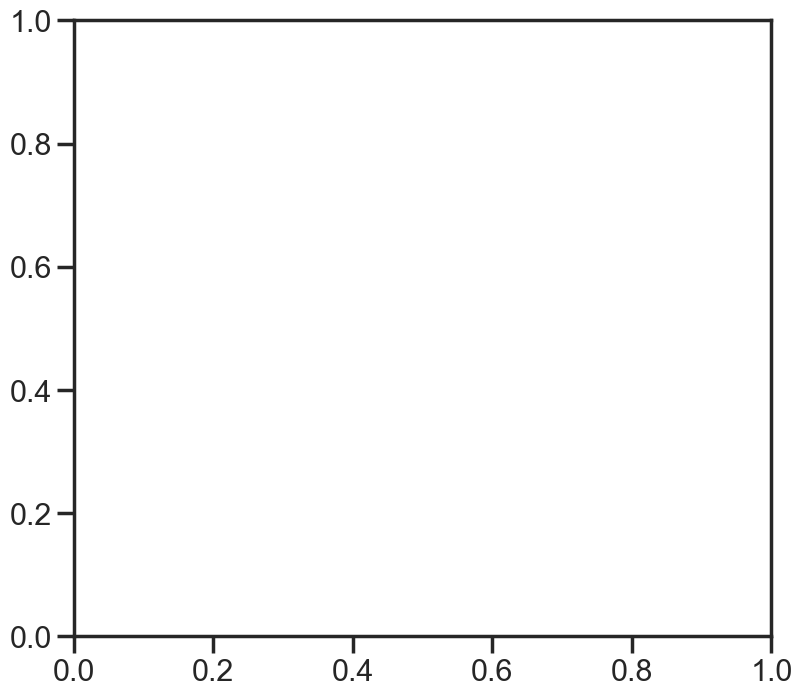

In [52]:
# By category
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 8))

xticks=[0, 1, 2, 3]
xlabels=['VG','Sort', 'Med', 'Long']
chance=1/3
                
vg=plot[plot['ttype_n']==0]
sns.lineplot(x='ttype_n',  y='performance', hue='Treatment',
             ax=axes, data=vg, ci=68,  marker='o', palette='GnBu')
# wm=plot[plot['ttype_n']!=0]
# sns.lineplot(x='ttype_n',  y='performance',  hue='Treatment',
#              ax=axes, data=wm, ci=68,  marker='o', palette='GnBu')
# sns.lineplot(x='x_order', y=var, hue='injection', style='injection', data= plot, palette='Purples',
#             marker='o', markersize=15, ci=68, ax=axes)  


axes.set_xticks(xticks)
axes.set_xticklabels(xlabels)
axes.set_xlabel('Delay')
axes.set_ylabel('Performance')

axes.axhline(y=0.33, color='black', linestyle=':', linewidth=3)
sns.despine()

plt.savefig(str(data_folder) + 'perf_alm_delay2.svg', transparent=False)

# GLM general

## New useful columns

In [ ]:
# previous trial-2 result and response
df['prev2_r_n'] = df['r_n'].shift(2)
df['prev2_trial_result'] = df['trial_result'].shift(2)
df['prev_correct_bool']=df['correct_bool'].shift() # Correct_bool
df['next_correct_bool']=df['correct_bool'].shift(-1) # Correct_bool


# Memory trials
df['memory'] = np.where((df['ttype_c'] == 'VG') | (df['ttype_c'] == 'SIL'), 0, 1)
df['visual']= np.where(df['ttype_c'] == 'VG', 1, 0)

# Stimulus splitted  columns
df['s_l']=np.where(df['x_n'] == -1, 1, 0)
df['s_m']=np.where(df['x_n'] ==  0, 1, 0)
df['s_r']=np.where(df['x_n'] ==  1, 1, 0)

# Silent trials splitted
df.loc[df['silent'] == 1, 's_l'] = 0
df.loc[df['silent'] == 1, 's_c'] = 0
df.loc[df['silent'] == 1, 's_r'] = 0

# Response splitted  columns
df['r_l']=np.where(df['r_n'] == -1, 1, 0)
df['r_m']=np.where(df['r_n'] ==  0, 1, 0)
df['r_r']=np.where(df['r_n'] ==  1, 1, 0)

# Previous response splitted new columns
df['prev_r_l']=np.where(df['prev_r_n'] == -1, 1, 0)
df['prev_r_m']=np.where(df['prev_r_n'] ==  0, 1, 0)
df['prev_r_r']=np.where(df['prev_r_n'] ==  1, 1, 0)

# Repeating_bool
df['prev_rep_bool']=np.where(df['prev_r_n']==df['x_n'], 1, 0)
df['prev2_rep_bool']=np.where(df['prev2_r_n']==df['x_n'], 1, 0)

# Repeating_bool
df['next_rep_bool']=np.where(df['next_r_n']==df['x_n'], 1, 0)

# Non repeating bool (difference 1)
df['prev_non_rep_bool']= abs(df['prev_r_n'] - df['x_n'])
df['prev_non_rep_bool'] = (df['prev_non_rep_bool'] == 1).astype(int)


## Design matrix

In [ ]:
########################################## GENERAL DESIGN MATRIX ##########################################

# Interest columns: 
columns = ['subject', 'task', 'trial', 'session', 'batch', 'stage',
           'x_n','s_r','s_m', 's_l', 
           'r_n','r_r','r_m', 'r_l', 
           
           'prev_r_n', 'prev_r_r', 'prev_r_m', 'prev_r_l', 'next_rep_bool', 
           'prev_rep_bool', 'prev2_rep_bool', 'prev_non_rep_bool',
           
           'trial_result', 'prev_trial_result', 'prev2_trial_result', 
           'correct_bool', 'prev_correct_bool', 'next_correct_bool',
           
           'ttype_n', 'stimd_n','visual', 'memory', 'silent', 'prev_silent',
           'delay_rw', 'delay_abs',
           
           'corridor_latency', 'prev_corridor_latency', 'resp_latency', 'prev_resp_latency',
           'lick_latency', 'prev_lick_latency', 'trial_length', 'prev_trial_length', 

           'date', 'valids', 'valids2', 'valids3', 'prev_valids', 'prev_valids2', 'prev_valids3',
           'manipulation']


# Create the design matrix
design_matrix= df[columns]
initial_len=design_matrix.shape[0]


# Numeric format, if not give errors fitting the model
no_numeric = ['subject', 'task', 'batch', 'trial_result', 'prev_trial_result', 'prev2_trial_result', 'date']
numeric = [col for col in columns if col not in no_numeric] # do not convert strings to numeric ofc       
design_matrix[numeric] = design_matrix[numeric].apply(pd.to_numeric) 

# Intercept
design_matrix['intercept'] = 1 # we have to pass a column of 1 for the intercept

In [1]:
#### DATA SUBSET: GOOD BATCHES WITH STIM DUR CONTROLS, WITHOUT SILENT TRIALS

# design_matrix = design_matrix.loc[((design_matrix['batch']!='3B') & (design_matrix['batch']!='34B'))] # REMOVE 5 CHOICES AND CLASSIC TASK



design_matrix = design_matrix.loc[((design_matrix['batch']=='7B') | (design_matrix['batch']=='9B'))] # Best batches
design_matrix = design_matrix.loc[((design_matrix['silent']==0) & (design_matrix['prev_silent']==0) 
                        & (design_matrix['valids']==1) & (design_matrix['valids2']==1) & (design_matrix['valids3']==1)
                        & (df['prev_valids']==1) & (df['prev_valids2']==1) & (df['prev_valids3']==1) 
                        & (design_matrix['manipulation']==0)  & (design_matrix['task']!='StageTraining_9B_V3'))] # remove manipulations & misses & weird trials

##select only the subjects that have all the ttypes
# subject_ttype_counts = design_matrix.groupby('subject')['ttype_n'].nunique()
# subjects_to_plot = subject_ttype_counts[subject_ttype_counts == 4].index.tolist()
# design_matrix = design_matrix.loc[design_matrix['subject'].isin(subjects_to_plot)]


NameError: name 'design_matrix' is not defined

In [2]:
# Normalize some columns (0-1)
design_matrix['stimd_n_norm'] = (design_matrix['stimd_n'] - design_matrix['stimd_n'].min()) / (design_matrix['stimd_n'].max() - design_matrix['stimd_n'].min())
design_matrix['ttype_n_norm'] = (design_matrix['ttype_n'] - design_matrix['ttype_n'].min()) / (design_matrix['ttype_n'].max() - design_matrix['ttype_n'].min())


NameError: name 'design_matrix' is not defined

In [ ]:
# Check for null values
null_columns = design_matrix.columns[design_matrix.isnull().any()]

# Print the columns with null values
print("Columns with null values:", null_columns.tolist())

# remove other outcomes thatn correct and punish
design_matrix = design_matrix.dropna(subset=['next_correct_bool'])
null_columns = design_matrix.columns[design_matrix.isnull().any()]
print("Columns with null values:", null_columns.tolist())


In [ ]:
## INTERACTIONS
design_matrix['ttype_prev_rep_bool'] = design_matrix['ttype_n_norm'] * design_matrix['prev_rep_bool']
design_matrix['prev_corr_rep_bool'] = design_matrix['prev_correct_bool'] * design_matrix['prev_rep_bool']
design_matrix['next_corr_prev_rep_bool'] = design_matrix['next_correct_bool'] * design_matrix['prev_rep_bool']
design_matrix['prev_corr_non_rep_bool'] = design_matrix['prev_correct_bool'] * design_matrix['prev_non_rep_bool']


In [ ]:
def prev_next_glm(design_matrix):

    formula = 'correct_bool ~ ttype_n_norm + stimd_n_norm + prev_rep_bool + prev_correct_bool + ttype_prev_rep_bool  + prev_corr_rep_bool + next_corr_prev_rep_bool'    # rep_bool_t-2 s_r + s_l 

    for idx, subject in enumerate(design_matrix.subject.unique()):
        subs_design_matrix = design_matrix.loc[((design_matrix['subject']==subject))] 

        model = smf.glm(formula=formula,  data=subs_design_matrix, groups=subs_design_matrix["session"], 
                       family=sm.families.Binomial())
        result = model.fit() #fit_regularized(L1_wt=0)
        print(result)

        results_df = pd.read_html(result.summary().tables[1].as_html(),header=0,index_col=0)[0].reset_index()
        results_df.rename(columns={'index':'regressor'}, inplace=True)
        results_df['subject']=subject

        if idx==0:
            result_df=results_df
        else:
            result_df = pd.concat([result_df, results_df], ignore_index=True) 


    result_df['significant'] = np.where(result_df['P>|z|']<=0.05, 1, 0)
    return result_df


In [ ]:
def prev_next_glm_nostim(design_matrix):

    formula = 'correct_bool ~ ttype_n_norm + prev_rep_bool + prev_correct_bool + ttype_prev_rep_bool  + prev_corr_rep_bool + next_corr_prev_rep_bool'    # rep_bool_t-2 s_r + s_l 

    for idx, subject in enumerate(design_matrix.subject.unique()):
        subs_design_matrix = design_matrix.loc[((design_matrix['subject']==subject))] 

        model = smf.glm(formula=formula,  data=subs_design_matrix, groups=subs_design_matrix["session"], 
                       family=sm.families.Binomial())
        result = model.fit() #fit_regularized(L1_wt=0)
        print(result)

        results_df = pd.read_html(result.summary().tables[1].as_html(),header=0,index_col=0)[0].reset_index()
        results_df.rename(columns={'index':'regressor'}, inplace=True)
        results_df['subject']=subject

        if idx==0:
            result_df=results_df
        else:
            result_df = pd.concat([result_df, results_df], ignore_index=True) 


    result_df['significant'] = np.where(result_df['P>|z|']<=0.05, 1, 0)
    return result_df




In [ ]:
def prev_glm(design_matrix):

    formula = 'correct_bool ~ ttype_n_norm + stimd_n_norm + prev_rep_bool + prev_correct_bool + ttype_prev_rep_bool  + prev_corr_rep_bool'    # rep_bool_t-2 s_r + s_l 

    for idx, subject in enumerate(design_matrix.subject.unique()):
        subs_design_matrix = design_matrix.loc[((design_matrix['subject']==subject))] 

        model = smf.glm(formula=formula,  data=subs_design_matrix, groups=subs_design_matrix["session"], 
                       family=sm.families.Binomial())
        result = model.fit() #fit_regularized(L1_wt=0)
        print(result)

        results_df = pd.read_html(result.summary().tables[1].as_html(),header=0,index_col=0)[0].reset_index()
        results_df.rename(columns={'index':'regressor'}, inplace=True)
        results_df['subject']=subject

        if idx==0:
            result_df=results_df
        else:
            result_df = pd.concat([result_df, results_df], ignore_index=True) 


    result_df['significant'] = np.where(result_df['P>|z|']<=0.05, 1, 0)
    return result_df




In [ ]:
def prev_glm_att(design_matrix):

    formula = 'correct_bool ~ ttype_n_norm + prev_rep_bool + prev_non_rep_bool + prev_correct_bool + ttype_prev_rep_bool  + prev_corr_rep_bool + prev_corr_non_rep_bool'    

    for idx, subject in enumerate(design_matrix.subject.unique()):
        subs_design_matrix = design_matrix.loc[((design_matrix['subject']==subject))] 

        model = smf.glm(formula=formula,  data=subs_design_matrix, groups=subs_design_matrix["session"], 
                       family=sm.families.Binomial())
        result = model.fit() #fit_regularized(L1_wt=0)
        print(result)

        results_df = pd.read_html(result.summary().tables[1].as_html(),header=0,index_col=0)[0].reset_index()
        results_df.rename(columns={'index':'regressor'}, inplace=True)
        results_df['subject']=subject

        if idx==0:
            result_df=results_df
        else:
            result_df = pd.concat([result_df, results_df], ignore_index=True) 


    result_df['significant'] = np.where(result_df['P>|z|']<=0.05, 1, 0)
    return result_df




In [ ]:
def prev_glmm(design_matrix):

    formula = 'correct_bool ~ ttype_n_norm + stimd_n_norm + prev_rep_bool + prev_correct_bool + ttype_prev_rep_bool  + prev_corr_rep_bool'    # rep_bool_t-2 s_r + s_l 

    model = smf.glm(formula=formula,  data=design_matrix, groups=design_matrix["subject"], 
                   family=sm.families.Binomial())
    result = model.fit() #fit_regularized(L1_wt=0)
    print(result)

    result_df = pd.read_html(result.summary().tables[1].as_html(),header=0,index_col=0)[0].reset_index()
    result_df.rename(columns={'index':'regressor'}, inplace=True)

    result_df['significant'] = np.where(result_df['P>|z|']<=0.05, 1, 0)
    return result_df


In [ ]:
glm_type='prev_next'
reg_list_fancy=['Intercept', 'Delay' , 'Stim dur', 'Prev choice', 'Prev outcome', 'Delay * Prev choice', 
                'Prev choice * Prev outcome']

if glm_type=='prev':
    name='GLM_Prev.png'
    result_df = prev_glm(design_matrix)

    
elif glm_type=='prev_next':
    name='GLM_Prev_Next.png'
    result_df = prev_next_glm(design_matrix)
    reg_list_fancy=['Intercept', 'Delay' , 'Stim dur', 'Prev choice', 'Prev outcome', 'Delay * Prev choice', 
                'Prev choice * Prev outcome' , 'Prev choice * Next outcome']

elif glm_type=='prev_next_glm_nostim':
    reg_list_fancy=['Intercept', 'Delay' , 'Prev choice', 'Prev outcome', 'Delay * Prev choice', 
                'Prev choice * Prev outcome', 'Prev choice * Next outcome']
    name='prev_next_glm_NOSTIM.png'
    result_df = prev_next_glm_nostim(design_matrix)
    
elif glm_type=='next':
    reg_list_fancy=['Intercept', 'Delay' , 'Stim dur', 'Next choice', 'Next outcome', 'Delay * Next choice', 
                'Next choice * Next outcome']
    name='GLM_Next.png'
    result_df = next_glm(design_matrix)

elif glm_type=='prevGLMM':
    name='prev_glmm.png'
    result_df = prev_glmm(design_matrix)
    
elif glm_type=='prev_glm_random':
    name='GLM_Prev2.png'
    result_df = prev_glm_random(design_matrix)

elif glm_type=='prev_glm_bambi':
    name='GLM_Prev2_bambi.png'
    result_df = prev_glm_bambi(design_matrix)
    
elif glm_type=='prev_glm_nostim':
    reg_list_fancy=['Intercept', 'Delay' , 'Prev choice', 'Prev outcome', 'Delay * Prev choice', 
                'Prev choice * Prev outcome']
    name='prev_glm_NOSTIM.png'
    result_df = prev_glm_NOSTIM(design_matrix)

elif glm_type=='prev_glm_att':
    reg_list_fancy=['Intercept', 'Delay' , 'Prev choice', 'Prev choice1', 'Prev outcome', 'Delay * Prev choice', 
                'Prev choice * Prev outcome', 'Prev choice1 * Prev outcome']
    name='prev_glm_att.png'
    result_df = prev_glm_att(design_matrix)
    

fig, axes = plt.subplots(nrows=1, ncols=len(reg_list_fancy), figsize=(35,10))
result_df['x']=0

for idx, reg in enumerate(result_df.regressor.unique()):
    subset= result_df.loc[result_df['regressor']==reg]
    
    # DOTS
    sns.boxplot(x='x', y='coef', data=subset, ax=axes[idx], zorder=-30, width=0.3, 
           color="white", linecolor="black", linewidth=2.5,  fliersize=0)
    sns.stripplot(x='x',y='coef',  hue='significant', hue_order=[0,1], palette=['silver', 'black'], data=subset,
                  ax=axes[idx], size=12, zorder=-30, jitter=True)
    axes[idx].axhline(0, linestyle=':', color='black')

    
    axes[idx].set_title(reg_list_fancy[idx], fontweight='bold', fontsize=17)
    axes[idx].set_xlabel('')
    if idx==0:
        axes[idx].legend(title='Label', loc='center', bbox_to_anchor=(-0.35, 0.95))
        axes[idx].set_ylabel('Weight')
         # Add a legend
        handles, labels = axes[idx].get_legend_handles_labels()
        # Create new labels
        new_labels = ['NS', 'Significant']
        # Modify the legend
        axes[idx].legend(handles, new_labels, title='p-value')


    else:
        if idx>2:
            axes[idx].set_ylim(-1.5,1.5)
        axes[idx].get_legend().remove()
        axes[idx].set_ylabel('')
        
sns.despine()


In [ ]:

fig, axes = plt.subplots(nrows=1, ncols=len(reg_list_fancy), figsize=(35,10))

for idx, reg in enumerate(result_df.regressor.unique()):
    subset= result_df.loc[result_df['regressor']==reg]
    
    # DOTS
    # Calculate mean and SEM
    mean = subset['coef'].mean()
    maxi = subset['coef'].max()
    sem = subset['coef'].sem()
    
    # Perform a t-test to check if the mean is significantly different from zero
    t_stat, p_value = stats.ttest_1samp(subset['coef'], 0)
    # Add star if significant
    axes[idx].text(0, maxi+0.1, stats_function(p_value), ha='center', va='bottom', 
                   color='black', fontsize=40, fontweight='bold')
    
    # Add scatter plot for individual points
    sns.boxplot(x='x', y='coef', data=subset, ax=axes[idx], zorder=-30, width=0.3, 
           color="white", linecolor="dimgrey", linewidth=3.5,  fliersize=0)
    sns.stripplot(x='x', y='coef',  color='gray', data=subset,
                  ax=axes[idx], size=14, jitter=True, zorder=-30)
   

    axes[idx].axhline(0, linestyle=':', color='black')
    axes[idx].set_title(reg_list_fancy[idx], fontweight='bold', fontsize=17)
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels('')
    if idx==0:
        axes[idx].legend(title='Label', loc='center', bbox_to_anchor=(-0.35, 0.95))
        axes[idx].set_ylabel('Weight')
         # Add a legend
        handles, labels = axes[idx].get_legend_handles_labels()
        # Create new labels
        new_labels = ['NS', 'Significant']
        # Modify the legend
#         axes[idx].legend(handles, new_labels, title='p-value')
        axes[idx].set_ylim(-3,3)


    else:
        axes[idx].set_ylim(-3,3)
        if idx>2:
            axes[idx].set_ylim(-1.8,1.8)
#         axes[idx].get_legend().remove()
        axes[idx].set_ylabel('')
        
sns.despine()
plt.savefig(str(data_folder) + 'GLM_def.svg', facecolor='white', transparent=False)

In [ ]:
########################################## GENERAL DESIGN MATRIX ##########################################

# Interest columns: 
columns = ['subject',
           'x_c','s_r','s_m', 's_l', 
           'r_c','r_r','r_m', 'r_l',  
           'prev_r_c', 'prev_r_r', 'prev_r_m', 'prev_r_l',
           'trial_result', 'prev_trial_result',
           'visual', 'memory', 'silent', 
           'delay_rw', 'delay_abs',
           'performance', 'prev_performance', 'correct_bool',
           'trial', 'trial_length', 'prev_trial_length', 
           'injection', 'opto_on', 'opto_bool',
           'date', 'session', 'trial_type', 'ttype_n', 'ttype_c',
         ]
#missing --> 'resp_latency'


# Create the design matrix
design_matrix= df[columns]
initial_len=design_matrix.shape[0]


# Clean the design matrix
### treatment columns
design_matrix=design_matrix.loc[((design_matrix['injection']!='CNO'))]
design_matrix['Ro_s']=0 # systemic
design_matrix['Ro_l']=0 # local
design_matrix['M:B'] =0
design_matrix.loc[((design_matrix['injection']=='Ro63') & (design_matrix['date']<='2021/07/29')), 'Ro_s']=1
design_matrix.loc[((design_matrix['injection']=='MK801')), 'Ro_s']=1
design_matrix.loc[((design_matrix['injection']=='Ro63')  & (design_matrix['date']>='2021/11/24')), 'Ro_l']=1
design_matrix.loc[((design_matrix['injection']=='M:B')), 'M:B']=1

# Correct opto nan values
design_matrix.loc[design_matrix['opto_on'].isnull(), 'opto_on']==0
design_matrix.loc[design_matrix['opto_bool'].isnull(), 'opto_on']==0


### remove easy trials
design_matrix=design_matrix.loc[design_matrix['trial']>12]
### remove impossible trials
design_matrix=design_matrix.loc[((design_matrix['trial_length'].notna()) & (design_matrix['prev_trial_length'].notna()))]

# Number of deleted rows
final_len=design_matrix.shape[0]
print('Deleted general: ' + str(round(100*  (initial_len-final_len)/ initial_len, 2))+'%')


# Numeric format, if not give errors fitting the model
columns += ['Ro_s', 'Ro_l', 'M:B']
no_numeric = ['subject', 'trial_result', 'prev_trial_result',  'injection', 'date', 'trial_type', 'ttype_c']
numeric = [col for col in columns if col not in no_numeric] # do not convert strings to numeric ofc       
design_matrix[numeric] = design_matrix[numeric].apply(pd.to_numeric) 



# Z-score continuous variables
# design_matrix['z_resp_latency'] = stats.zscore(design_matrix['resp_latency'])
design_matrix['z_delay_abs'] = stats.zscore(design_matrix['delay_abs'])
design_matrix['z_delay_rw'] = stats.zscore(design_matrix['delay_rw'])
design_matrix['z_trial'] = stats.zscore(design_matrix['trial'])
design_matrix['z_session'] = stats.zscore(design_matrix['session'])
design_matrix['z_ttype_n'] = stats.zscore(design_matrix['ttype_n'])


# Intercept
design_matrix['intercept'] = 1 # we have to pass a column of 1 for the intercept


# Categorize responses category column with letters: Left = -1 = b; Centre = 0 = a; Right = 1 = c
# we want MNL model to calculate left and right response probs, the model automatically takes the 
#first element alphabetically ordered and is the one not calculated. If we place C as a it will caluclare L & R
design_matrix['name_r_c'] = design_matrix['r_c'].replace([-1,0,1],['b', 'a', 'c']) #renamed


# stimulus column with silent trials labeled
# design_matrix['stimulus']=design_matrix['x_c']
# design_matrix.loc[design_matrix['silent']==1, 'stimulus']='None'
  

In [ ]:
for label in design_matrix.label_c.unique():
    subs_design_matrix = design_matrix.loc[((design_matrix['trial_result']!='miss') & (design_matrix['label_c']==label))] # Omissions must be removed

    # Convert the pandas DataFrame to an R data frame
    pandas2ri.activate()
    r_data = pandas2ri.py2rpy(subs_design_matrix)


    # Fit the binomial GLMM in R
    formula = "correct_bool ~ ttype_c  + opto_bool  +  light_20   + (1 | subject)" 
    model = lme4.glmer(formula=formula, data=r_data, family="binomial")

    # Rafa will do 2 glmm for each labeling 
    # Get the summary of the model
    summary_model = ro.r['summary'](model)
    # Extract the coefficients from the summary using the coef function
    fixed_effects = summary_model.rx2("coefficients")
    # coefficients = ro.r['coef'](summary_model)
    results_df = pd.DataFrame(fixed_effects, columns=['coef', 'std', 'pval', 'zval'])
    results_df['label_c']=label
    
    
    if label==0:
        result_df=results_df
    else:
        result_df = pd.concat([result_df, results_df], ignore_index=True) 



##  GLM P(Correct)

tiffany advice: balancear la cantidad de regresores 0 y 1





In [ ]:
# interactions

design_matrix['memory_sm'] = design_matrix['memory'] * design_matrix['s_m']
design_matrix['memory_sr'] = design_matrix['memory'] * design_matrix['s_r']
design_matrix['memory_prev_perf'] = design_matrix['memory'] * design_matrix['prev_performance']


# como hago el repeating bias ??

In [ ]:

model_formula = "correct_bool ~ s_r + s_m + memory + prev_performance + memory_prev_perf"
reg_list_fancy=['Intercept', 'Right' , 'Centre', 'Memory', 'Prev outcome',
                'Memory x prev outcome']
#         dm = design_matrix.dropna()


for idx, subject in enumerate(design_matrix.subject.unique()):
    subs_design_matrix = design_matrix.loc[((design_matrix['subject']==subject))] 

#     model = smf.glm(formula=model_formula,  data=subs_design_matrix, groups=subs_design_matrix["subject"], 
#                    family=sm.families.Binomial())
    
    model = sm.Logit.from_formula(model_formula, subs_design_matrix)

    
    result = model.fit_regularized(L1_wt=0)
    results_df = pd.read_html(result.summary().tables[1].as_html(),header=0,index_col=0)[0].reset_index()
    results_df.rename(columns={'index':'regressor'}, inplace=True)
    results_df['subject']=subject
    
    if idx==0:
        result_df=results_df
    else:
        result_df = pd.concat([result_df, results_df], ignore_index=True) 


result_df['significant'] = np.where(result_df['P>|z|']<=0.05, 1, 0)



In [ ]:
# Pivot the DataFrame
pivot_result_df = result_df.pivot(index='subject', columns='regressor', values=['coef', 'std err', 'z', 'P>|z|', '[0.025', '0.975]', 'significant'])

# Flatten the MultiIndex columns
pivot_result_df.columns = ['_'.join(col) for col in pivot_result_df.columns.values]

# Reset the index
pivot_result_df.reset_index(inplace=True)

In [ ]:
# plot
fig, axes = plt.subplots(nrows=1, ncols=len(reg_list_fancy), figsize=(35,10))

reg_list = ['s_r', 's_m', 'memory', 'prev_performance', 'memory_prev_perf']
# reg_list =['coef_Intercept', 'coef_s_r' + 'coef_s_m' + 'coef_memory' + 'coef_prev_performance'
#            + 'coef_memory_prev_perf'

result_df['x']=0

for idx, reg in enumerate(reg_list):
    subset= result_df.loc[result_df['regressor']==reg]
    
    # DOTS
    sns.stripplot(x='x',y='coef',  hue='significant', hue_order=[0,1], palette=['silver', 'green'], data=subset,
                  ax=axes[idx], size=12, zorder=-30, jitter=True) 
   
#     #ERRORBARS
#     axes[idx].errorbar(x=subsubset['x'], y=subsubset['coef'], yerr=[subsubset['ci25'], subsubset['ci95']], 
#                        fmt='none', capsize=0, color=tamoxi_c[l], alpha=0.8)
#     #STATISTIC NOTES
#     stat_symbol= stats_function(subsubset['P>|z|'].iloc[0])
#     axes[idx].annotate(stat_symbol, (subsubset['x'], subsubset['coef']), textcoords="offset points", 
#                        xytext=(12,10), ha='left', fontsize=15)        

    
    axes[idx].set_title(reg_list_fancy[idx], fontweight='bold', fontsize=17)
    if idx==0:
        axes[idx].legend(title='Label', loc='center', bbox_to_anchor=(-0.35, 0.95))
        axes[idx].set_ylabel('Weight')

    else:
        axes[idx].get_legend().remove()
        axes[idx].set_ylabel('')

    axes[idx].axhline(0, linestyle=':', color='black')
    if idx==3:
        axes[idx].set_ylim(-2, 2)
    if idx==4:
        axes[idx].set_ylim(-2,2)

    axes[idx].set_xlim(-0.25,0.25)
    axes[idx].set_xlim(-0.25,0.25)

    axes[idx].set_xlabel('')
sns.despine()